In [429]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [430]:
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [431]:
X = data.data
X = X / 255.0
y = data.target

In [432]:
def display_image(index, X, y):
    print(f'\nLabel: {y[index]}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.show()


Label: 4



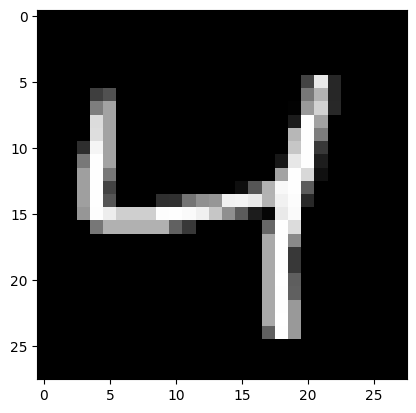

In [433]:
display_image(2, X, y)

In [434]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self, output_gradient, learning_rate, batch_size):
        pass

In [479]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        self.weights = np.random.randn(self.output_size, self.input_size) * np.sqrt(2 / input_size)
        self.baises = np.zeros((self.output_size, 1))

    def forward(self, input):
        self.input = input
        return self.weights @ self.input + self.baises
        

    def backward(self, output_gradient, learning_rate):
        batch_size = output_gradient.shape[1]

        dW = output_gradient @ self.input.T / batch_size
        dB = np.sum(output_gradient, axis=1, keepdims=True) / batch_size
        dX = self.weights.T @ output_gradient
    
        self.weights -= learning_rate * dW
        self.baises  -= learning_rate * dB
    
        return dX

In [480]:
class Activation(Layer):
    def __init__(self, activation_function, activation_prime):
        self.activation_function = activation_function
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation_function(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [481]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x)**2
        super().__init__(tanh, tanh_prime)

In [482]:
class ReLU(Activation):
    def __init__(self):
        relu = lambda x: np.fmax(0, x)
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)

In [483]:
class Softmax(Activation):
    def __init__(self):
        softmax_prime = lambda x: 1
        super().__init__(self.softmax, softmax_prime)

    def softmax(self, x):
        x = x - np.max(x, axis=0, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=0, keepdims=True)

In [711]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

def cross_entropy_prime(y_true, y_pred):
    return y_pred - y_true
    

In [485]:
def one_hot_encode(data):
    one_hot = []
    for d in data:
        one_hot.append(np.zeros((10, 1)))
        one_hot[-1][int(d)] = 1
    return np.array(one_hot)

In [486]:
X = X.reshape(70000, 784, 1)
y_one_hot = one_hot_encode(y)

In [487]:
X.shape, y_one_hot.shape

((70000, 784, 1), (70000, 10, 1))

In [739]:
class NeuralNetwork:
    def __init__(self, network):
        self.network = network

    def predict(self, data):
        output = data
        for layer in self.network:
            output = layer.forward(output)
        return output

    def score(self, X, y):
        X = X.squeeze(-1).T
        y = y.squeeze(-1).T
        preds = np.argmax(self.predict(X), axis=0)
        labels = np.argmax(y, axis=0)
        return np.sum(preds == labels) / y.shape[1]

    def train(self, X, y, learning_rate=0.1, epoch=16, batch_size=100):
        for e in range(epoch):
            perm = np.random.permutation(len(X))
            X = X[perm]
            y = y[perm]
            error = 0
            correct = 0
            for i in range(0, len(X), batch_size):
                X_batch = X[i:i + batch_size].squeeze(-1).T
                y_batch = y[i:i + batch_size].squeeze(-1).T
                output = self.predict(X_batch)
                loss = cross_entropy(y_batch, output)
                error += loss
                preds = np.argmax(output, axis=0)
                labels = np.argmax(y_batch, axis=0)
                correct += np.sum(preds == labels)
                gradient = cross_entropy_prime(y_batch, output)
                for layer in reversed(self.network):
                    gradient = layer.backward(gradient, learning_rate)
            print(f"Epoch: {e + 1}/{epoch} | Cross Entropy Loss: {error / y.shape[0]} | Accuracy: {correct / y.shape[0]}")

In [765]:
NN = NeuralNetwork([
    Dense(784, 64),
    ReLU(),
    Dense(64, 32),
    ReLU(),
    Dense(32, 16),
    Tanh(),
    Dense(16, 10),
    Softmax(),
])

In [766]:
X_train = X[:50000]
X_test = X[50000:]
y_train = y_one_hot[:50000]
y_test_norm = y[50000:]
y_test = y_one_hot[50000:]

In [767]:
NN.train(X_train, y_train, learning_rate=.1, epoch=16, batch_size=100)

Epoch: 1/16 | Cross Entropy Loss: 0.4815761307253067 | Accuracy: 0.86882
Epoch: 2/16 | Cross Entropy Loss: 0.2056663761008997 | Accuracy: 0.94208
Epoch: 3/16 | Cross Entropy Loss: 0.15449830082546379 | Accuracy: 0.95608
Epoch: 4/16 | Cross Entropy Loss: 0.1251511720301574 | Accuracy: 0.96414
Epoch: 5/16 | Cross Entropy Loss: 0.10584854512721989 | Accuracy: 0.96914
Epoch: 6/16 | Cross Entropy Loss: 0.0917428533979465 | Accuracy: 0.97272
Epoch: 7/16 | Cross Entropy Loss: 0.07997847459187374 | Accuracy: 0.97724
Epoch: 8/16 | Cross Entropy Loss: 0.07051526610578746 | Accuracy: 0.97946
Epoch: 9/16 | Cross Entropy Loss: 0.062410838561251 | Accuracy: 0.9819
Epoch: 10/16 | Cross Entropy Loss: 0.05604559452462973 | Accuracy: 0.98384
Epoch: 11/16 | Cross Entropy Loss: 0.05049511045258293 | Accuracy: 0.98592
Epoch: 12/16 | Cross Entropy Loss: 0.045538491556436814 | Accuracy: 0.98692
Epoch: 13/16 | Cross Entropy Loss: 0.042697325432497726 | Accuracy: 0.9875
Epoch: 14/16 | Cross Entropy Loss: 0.037

In [754]:
NN.score(X_test, y_test)

0.9731

In [747]:
def display_image_prediction(index, X, y, network):
    output = network.predict(X[index])
    print(f'\nLabel: {y[index]} | Predicted: {np.argmax(output)}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.show()


Label: 3 | Predicted: 3



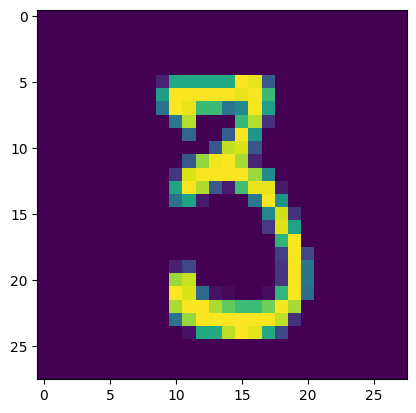

In [748]:
display_image_prediction(43, X_test, y_test_norm, NN)

In [749]:
def show_incorrect(X, y, network):
    X_sq = X.squeeze(-1).T
    y_sq = y.squeeze(-1).T
    
    output = network.predict(X_sq)
    preds = np.argmax(output, axis=0)
    labels = np.argmax(y_sq, axis=0)
    
    incorrect = np.where(preds != labels)
    for i in incorrect[0]:
        display_image_prediction(i, X, np.argmax(y, axis=1), network)
    return incorrect


Label: [4] | Predicted: 9



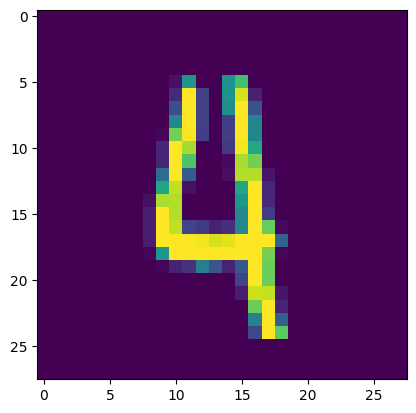


Label: [5] | Predicted: 8



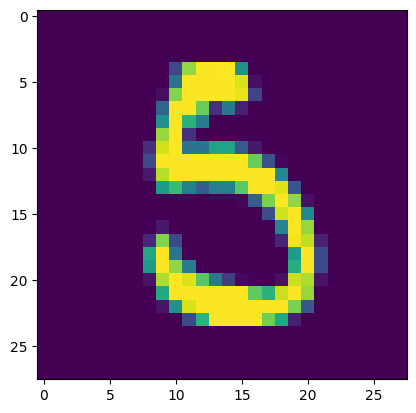


Label: [6] | Predicted: 2



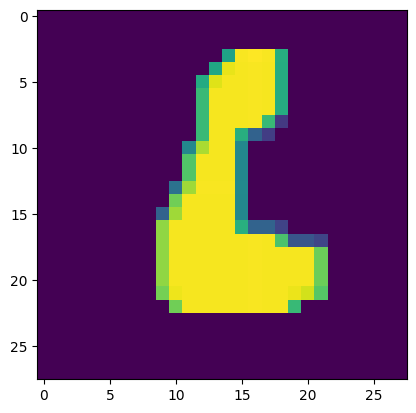


Label: [5] | Predicted: 8



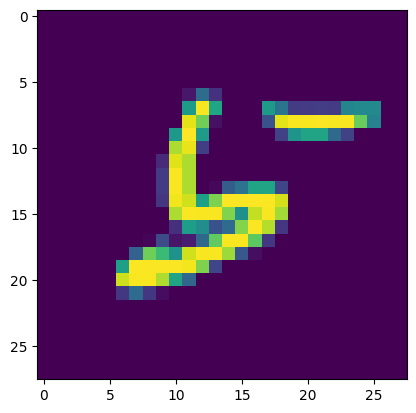


Label: [3] | Predicted: 8



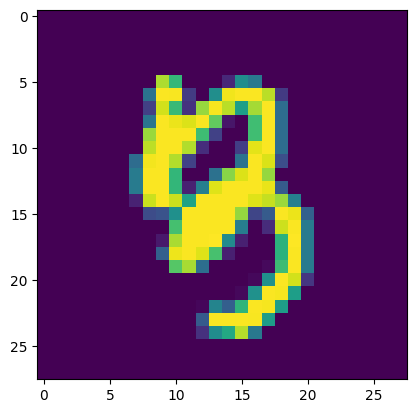


Label: [9] | Predicted: 0



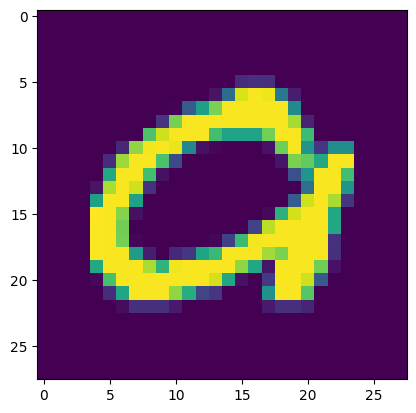


Label: [9] | Predicted: 7



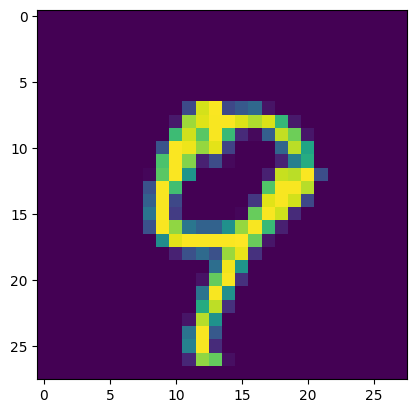


Label: [5] | Predicted: 7



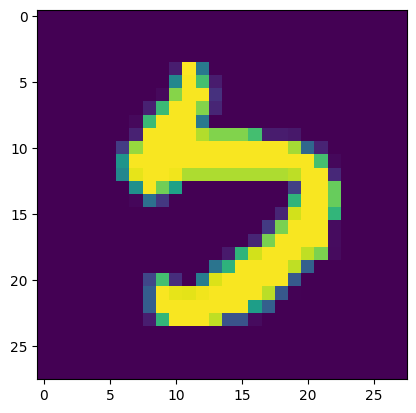


Label: [5] | Predicted: 3



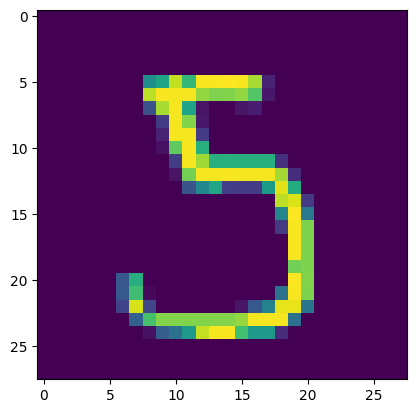


Label: [9] | Predicted: 7



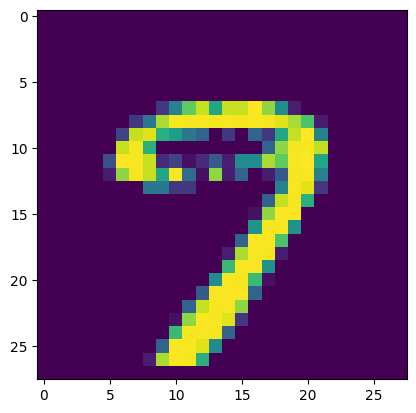


Label: [3] | Predicted: 2



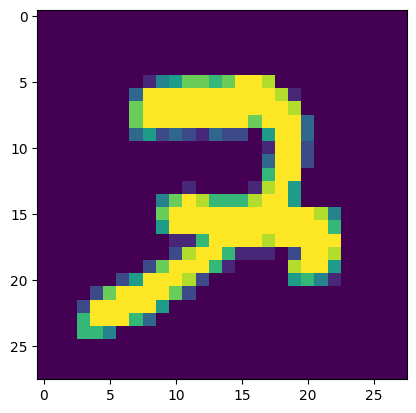


Label: [2] | Predicted: 3



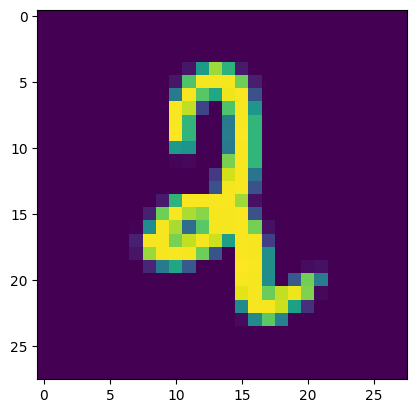


Label: [7] | Predicted: 9



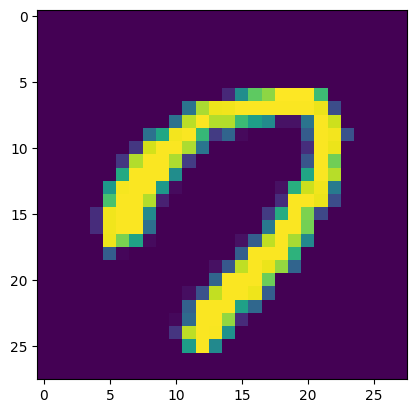


Label: [9] | Predicted: 7



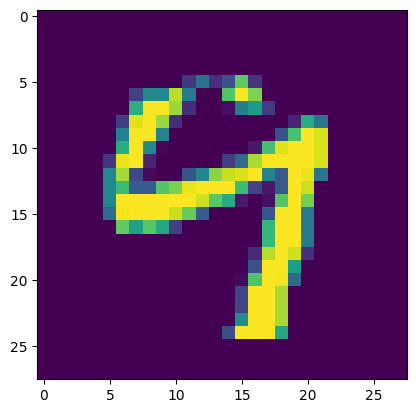


Label: [9] | Predicted: 5



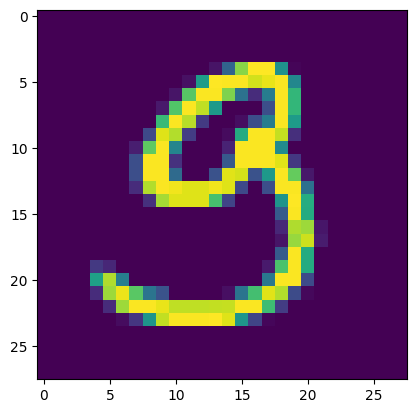


Label: [3] | Predicted: 8



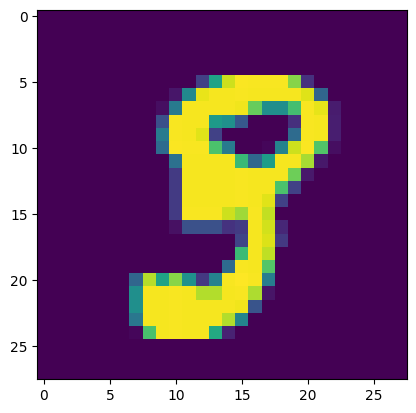


Label: [7] | Predicted: 2



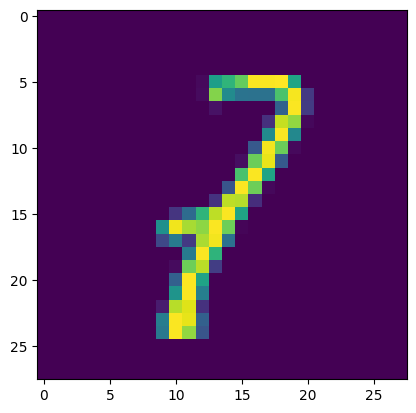


Label: [8] | Predicted: 1



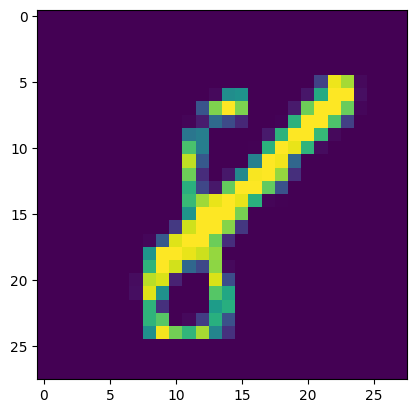


Label: [2] | Predicted: 8



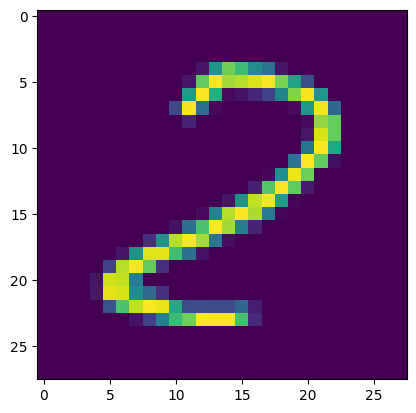


Label: [9] | Predicted: 7



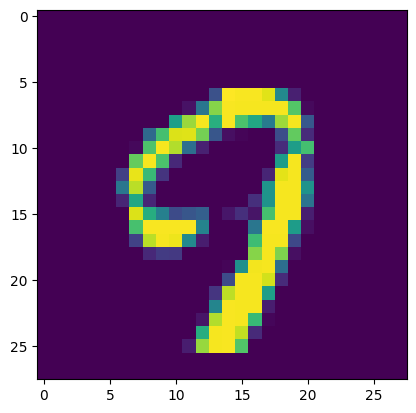


Label: [8] | Predicted: 3



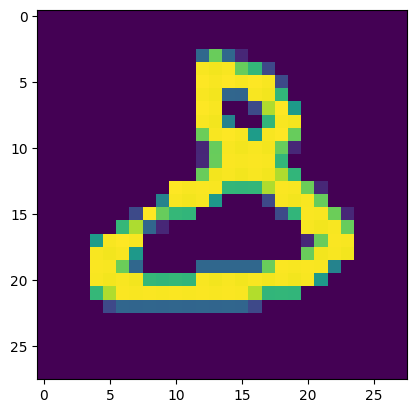


Label: [9] | Predicted: 8



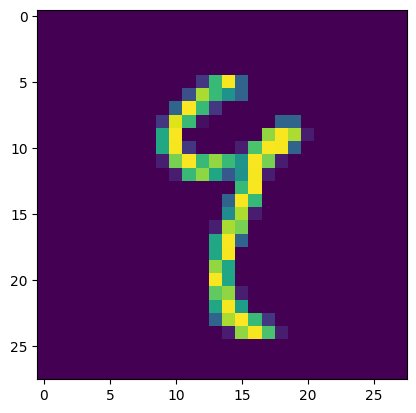


Label: [3] | Predicted: 5



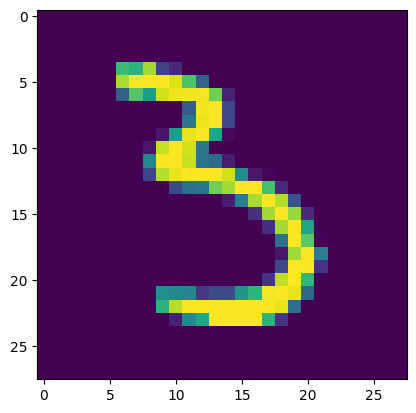


Label: [4] | Predicted: 1



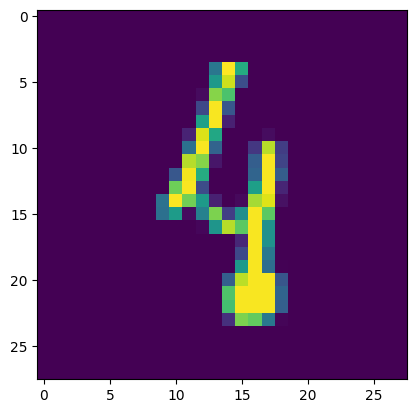


Label: [1] | Predicted: 7



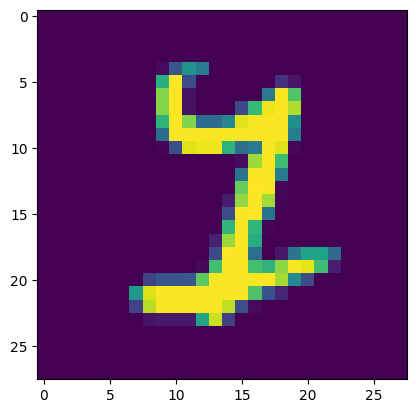


Label: [5] | Predicted: 6



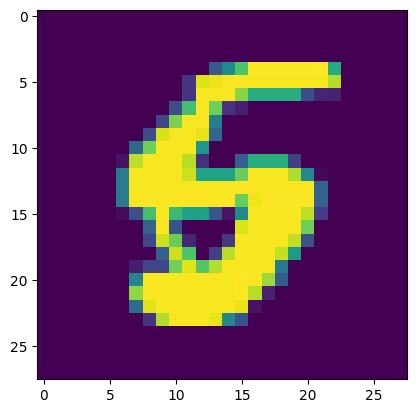


Label: [9] | Predicted: 0



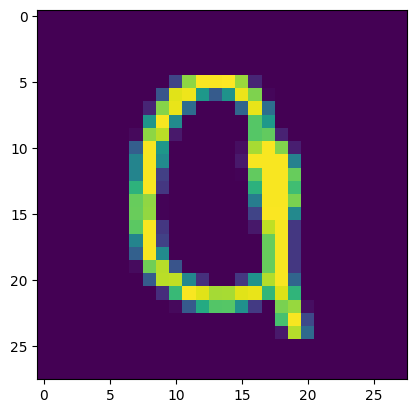


Label: [8] | Predicted: 3



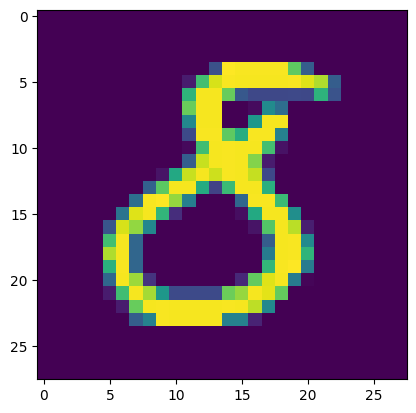


Label: [9] | Predicted: 8



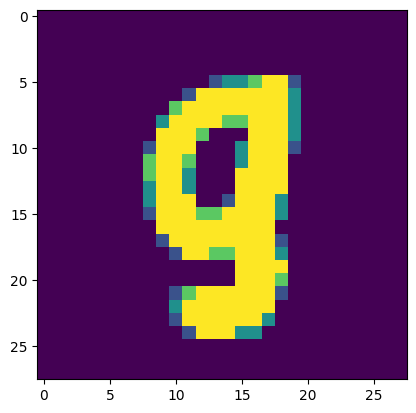


Label: [2] | Predicted: 3



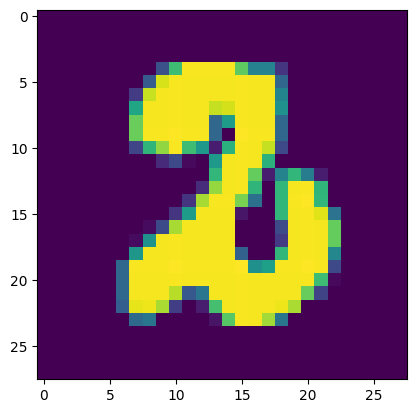


Label: [2] | Predicted: 3



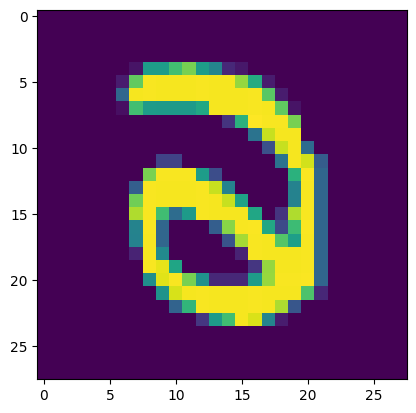


Label: [4] | Predicted: 9



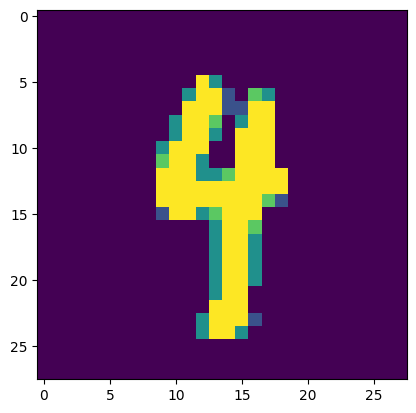


Label: [8] | Predicted: 9



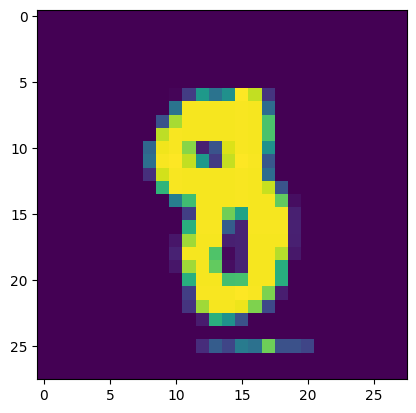


Label: [4] | Predicted: 1



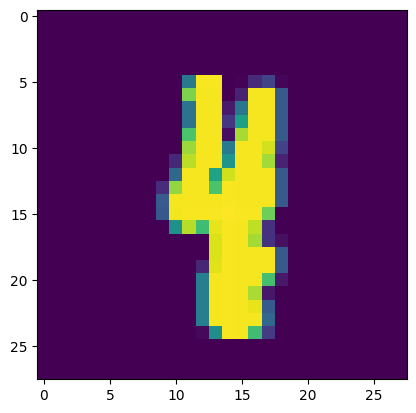


Label: [5] | Predicted: 3



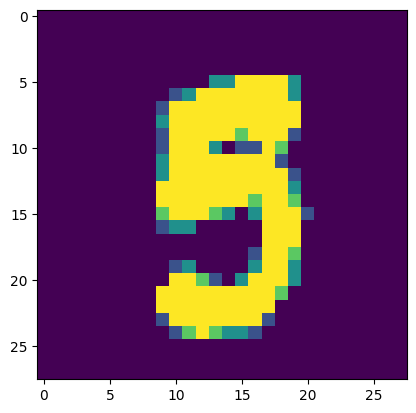


Label: [4] | Predicted: 2



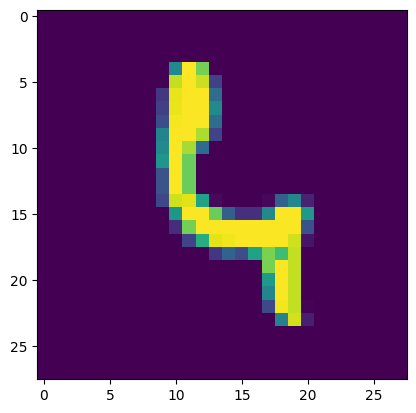


Label: [9] | Predicted: 7



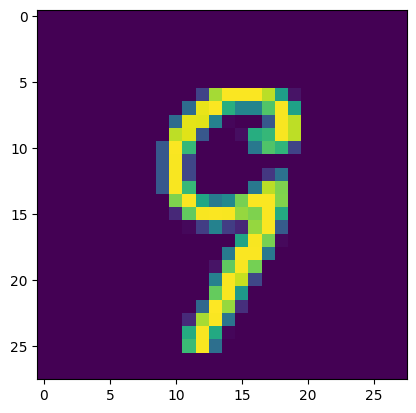


Label: [7] | Predicted: 3



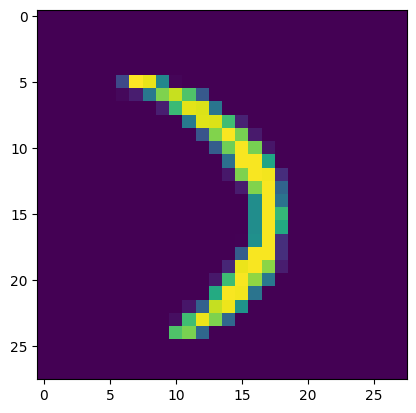


Label: [7] | Predicted: 3



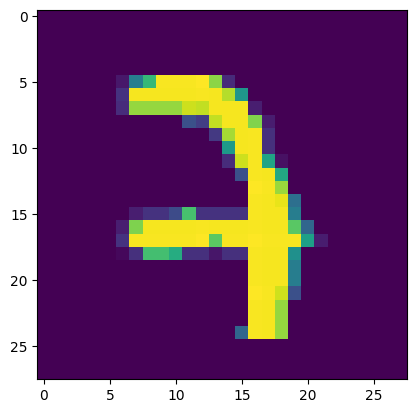


Label: [3] | Predicted: 5



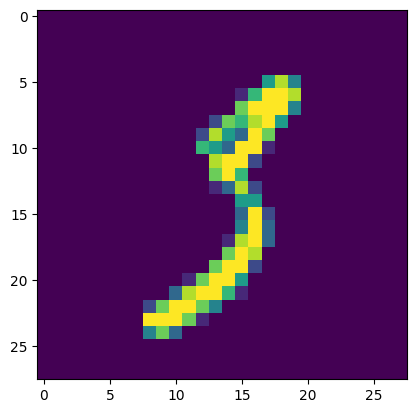


Label: [9] | Predicted: 4



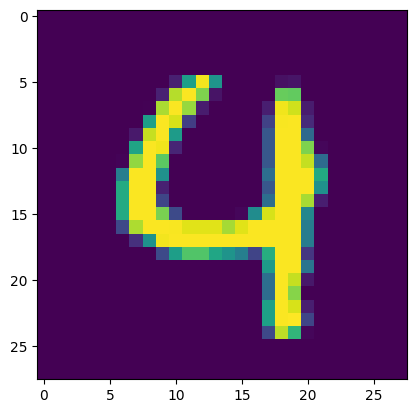


Label: [3] | Predicted: 5



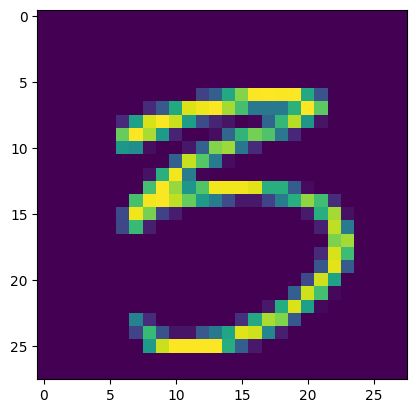


Label: [9] | Predicted: 4



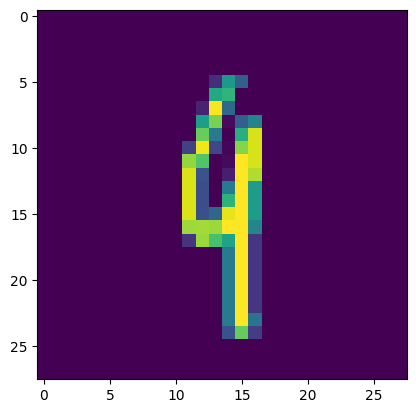


Label: [7] | Predicted: 1



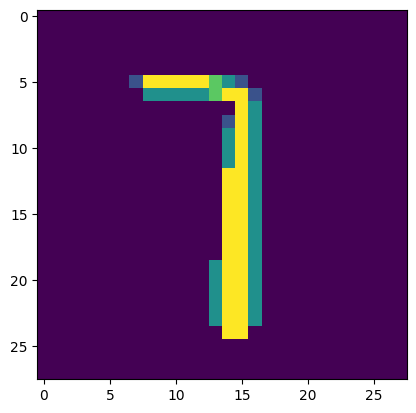


Label: [8] | Predicted: 5



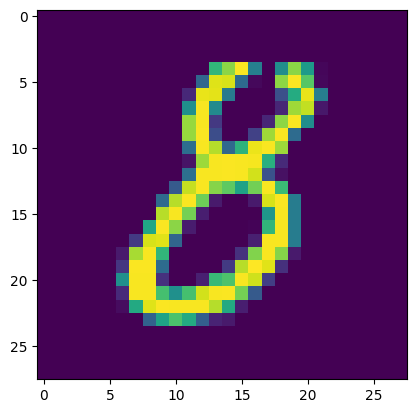


Label: [1] | Predicted: 3



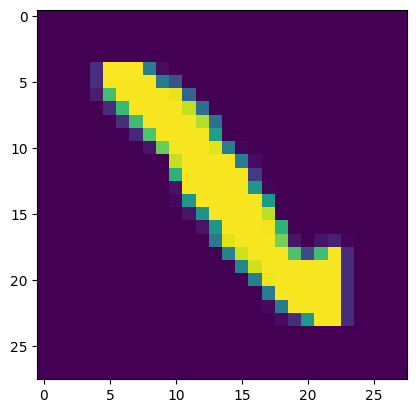


Label: [4] | Predicted: 9



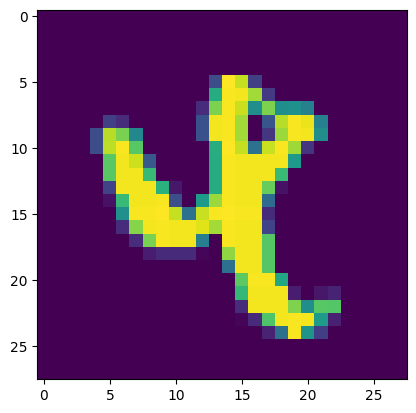


Label: [2] | Predicted: 3



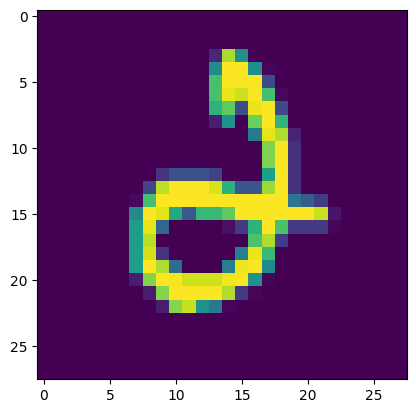


Label: [2] | Predicted: 1



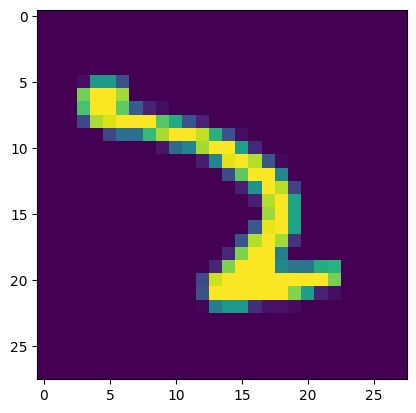


Label: [5] | Predicted: 8



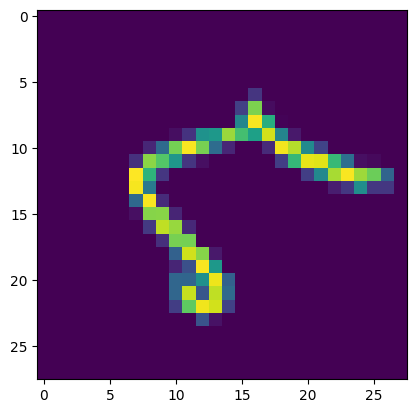


Label: [5] | Predicted: 6



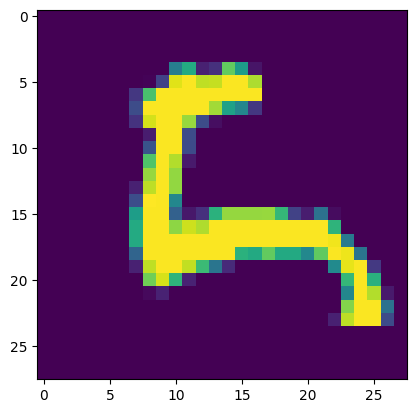


Label: [5] | Predicted: 9



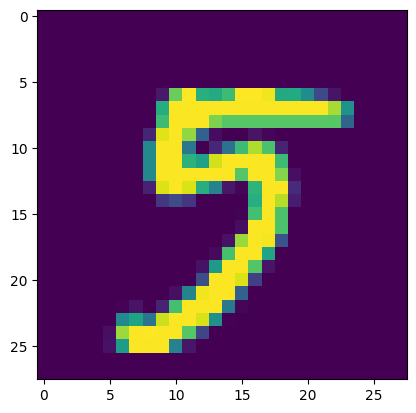


Label: [5] | Predicted: 3



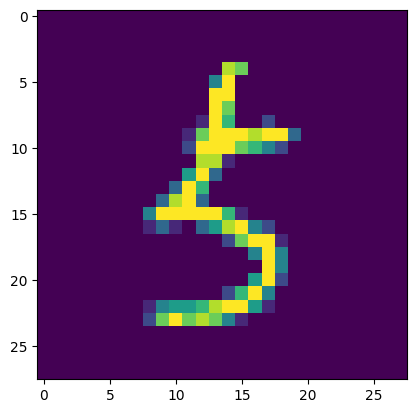


Label: [4] | Predicted: 9



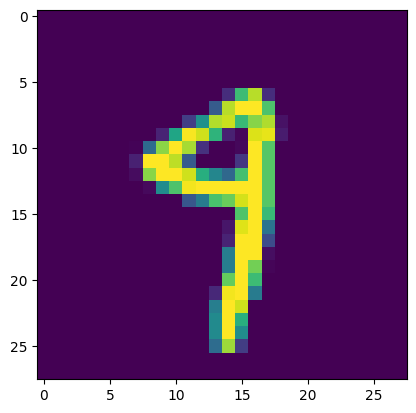


Label: [2] | Predicted: 7



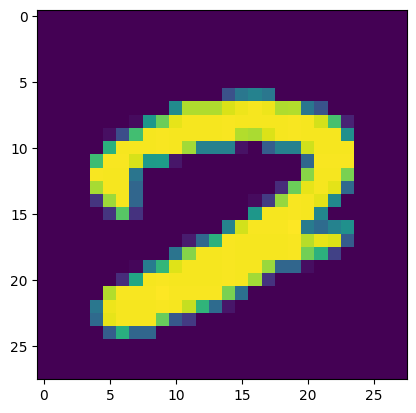


Label: [3] | Predicted: 5



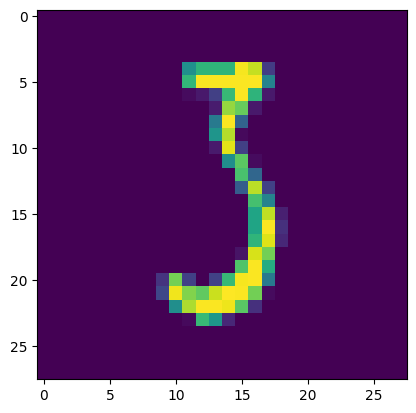


Label: [0] | Predicted: 6



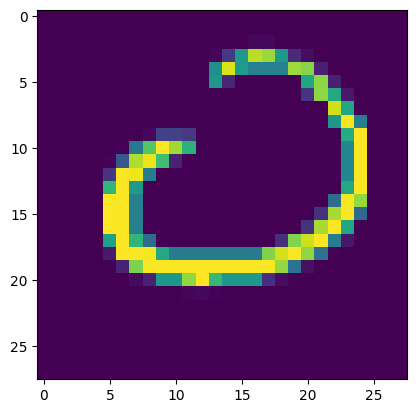


Label: [5] | Predicted: 9



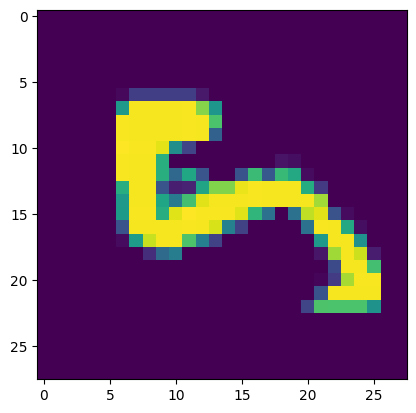


Label: [3] | Predicted: 5



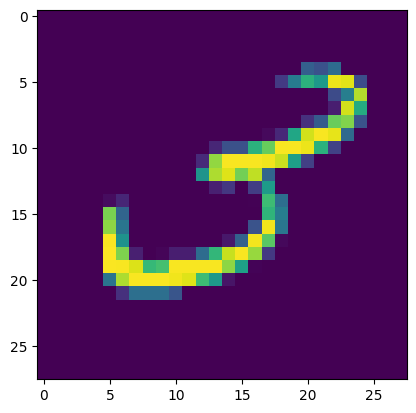


Label: [9] | Predicted: 7



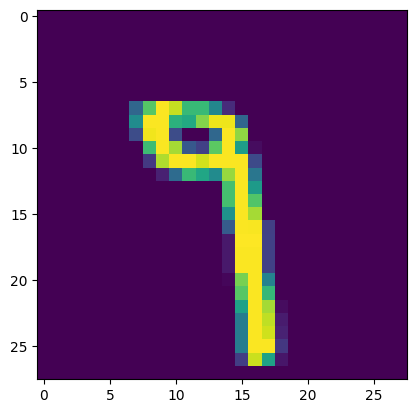


Label: [4] | Predicted: 2



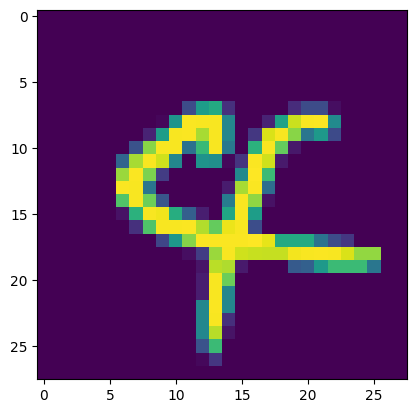


Label: [2] | Predicted: 7



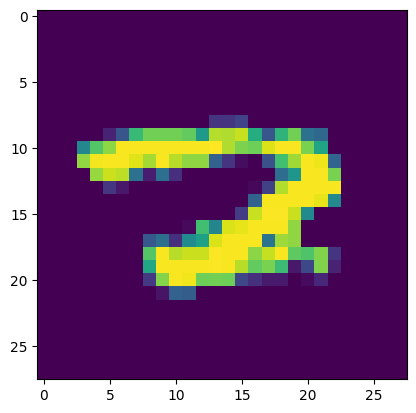


Label: [6] | Predicted: 4



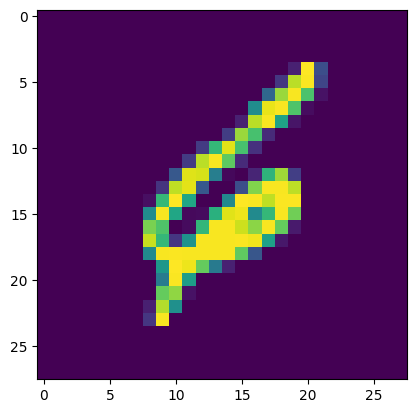


Label: [3] | Predicted: 5



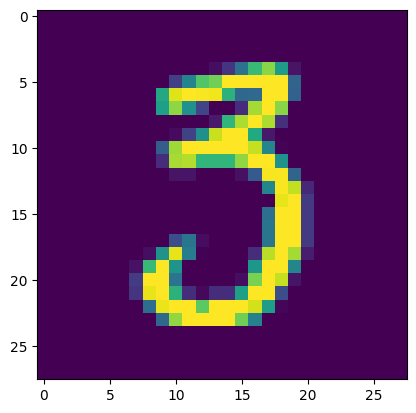


Label: [5] | Predicted: 8



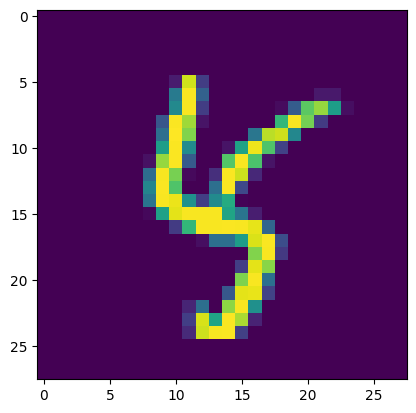


Label: [9] | Predicted: 4



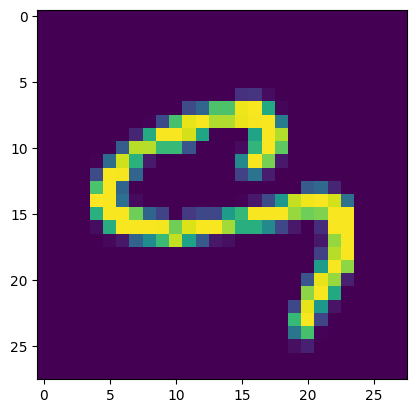


Label: [8] | Predicted: 9



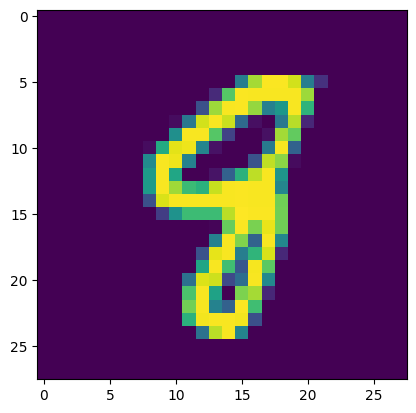


Label: [4] | Predicted: 8



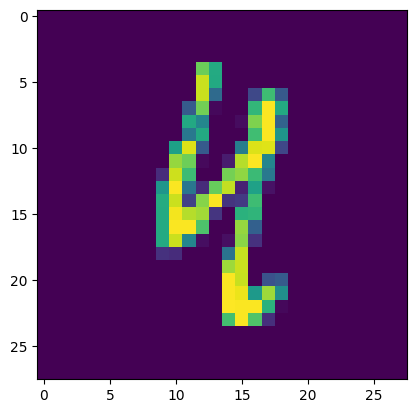


Label: [8] | Predicted: 9



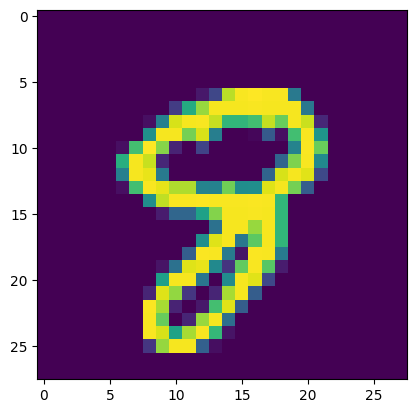


Label: [0] | Predicted: 6



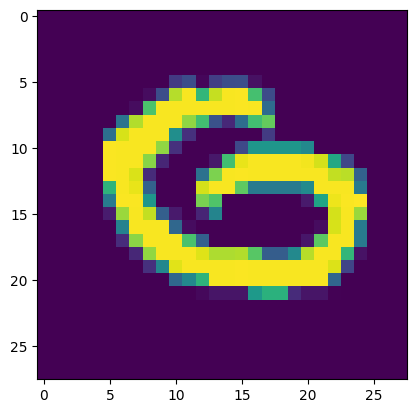


Label: [9] | Predicted: 7



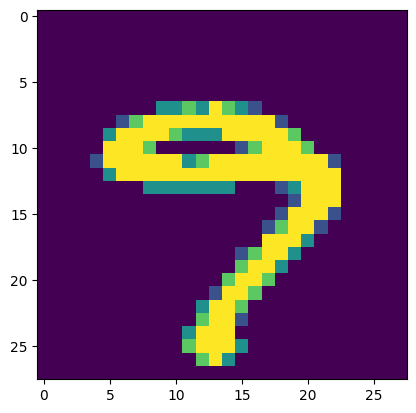


Label: [3] | Predicted: 5



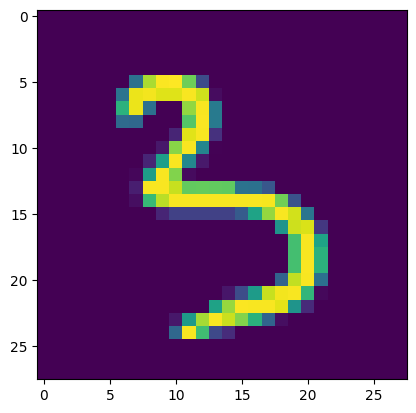


Label: [3] | Predicted: 8



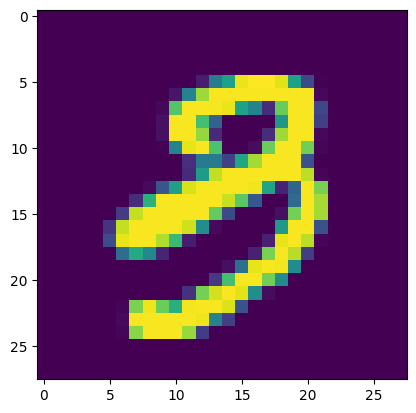


Label: [6] | Predicted: 0



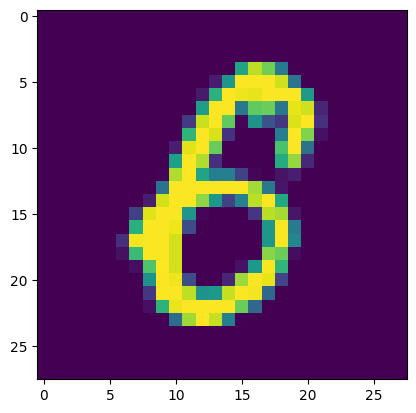


Label: [3] | Predicted: 2



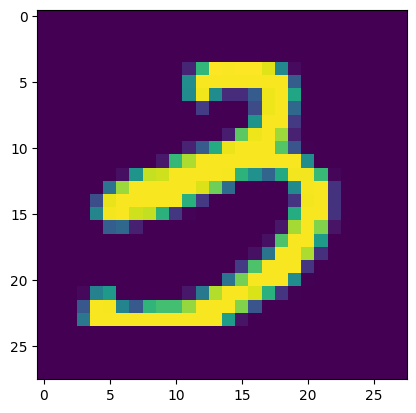


Label: [4] | Predicted: 9



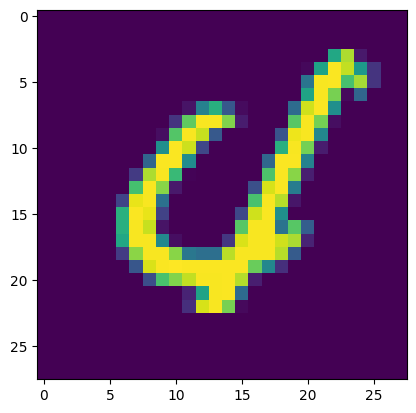


Label: [3] | Predicted: 2



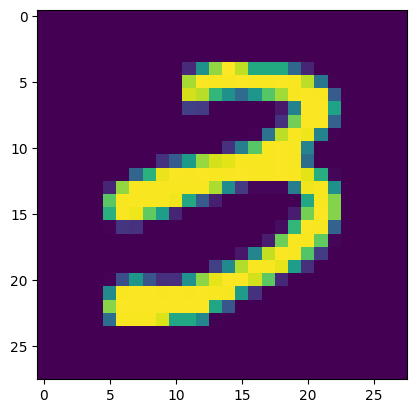


Label: [9] | Predicted: 8



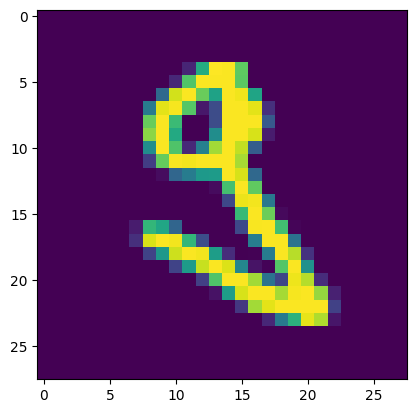


Label: [2] | Predicted: 8



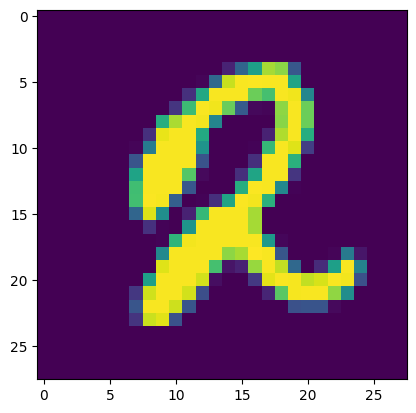


Label: [1] | Predicted: 6



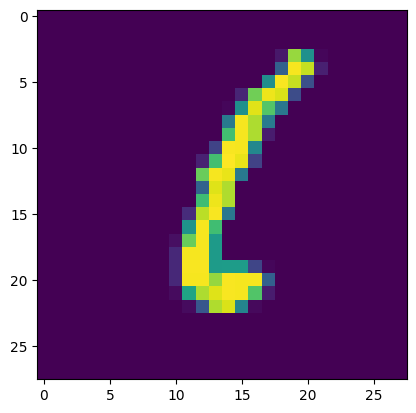


Label: [2] | Predicted: 8



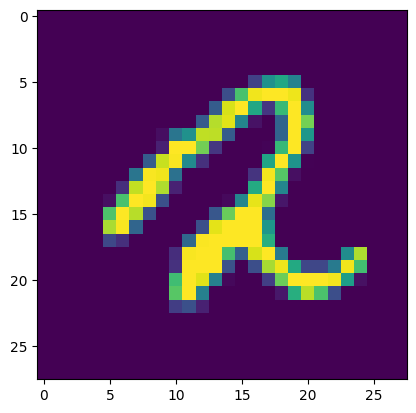


Label: [7] | Predicted: 3



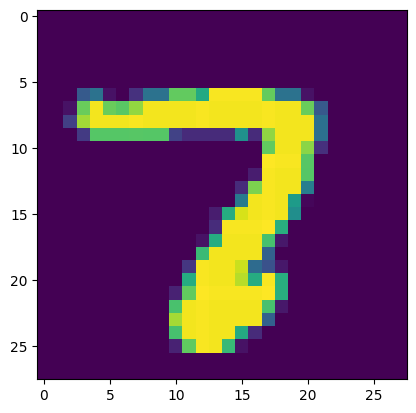


Label: [7] | Predicted: 2



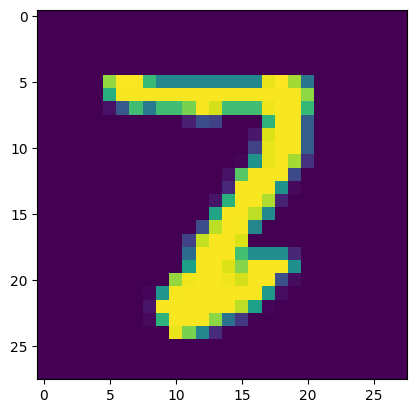


Label: [5] | Predicted: 0



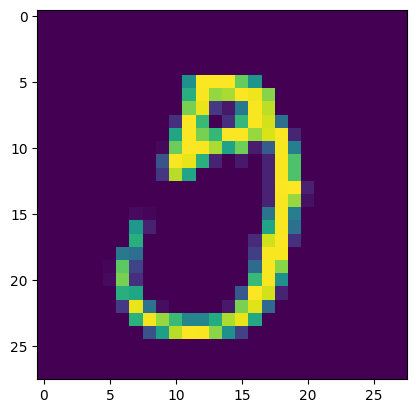


Label: [8] | Predicted: 3



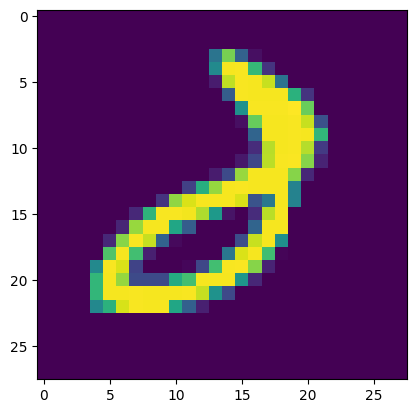


Label: [2] | Predicted: 8



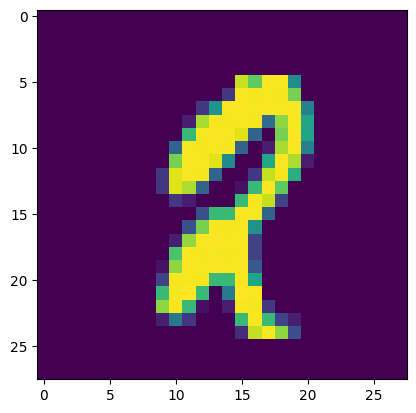


Label: [8] | Predicted: 2



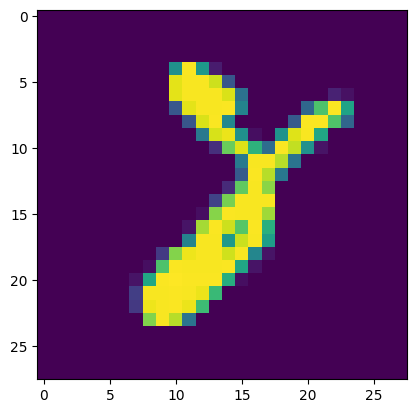


Label: [2] | Predicted: 4



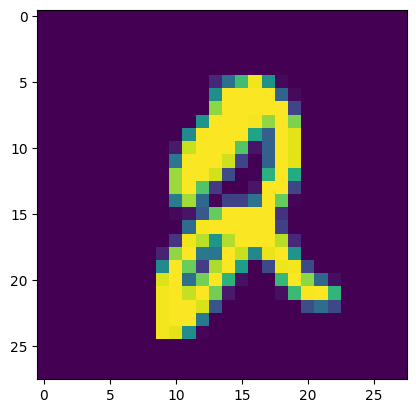


Label: [5] | Predicted: 6



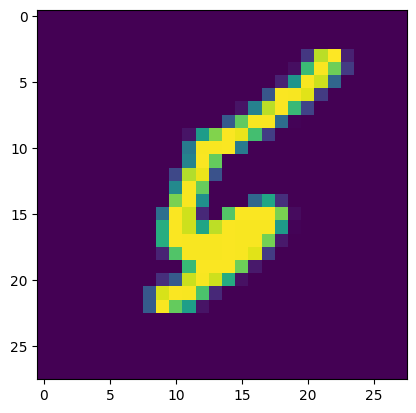


Label: [2] | Predicted: 8



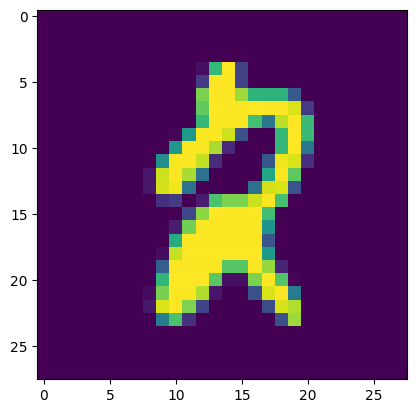


Label: [2] | Predicted: 0



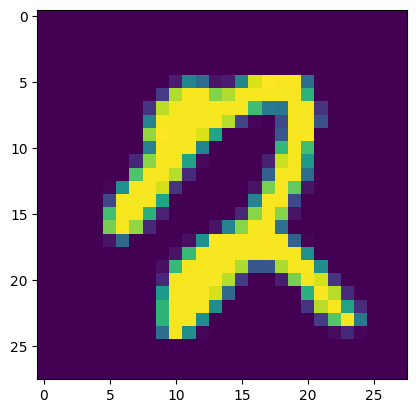


Label: [8] | Predicted: 9



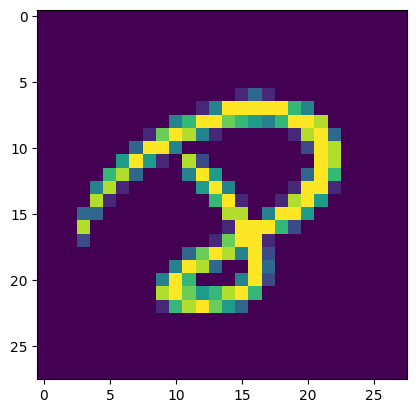


Label: [5] | Predicted: 6



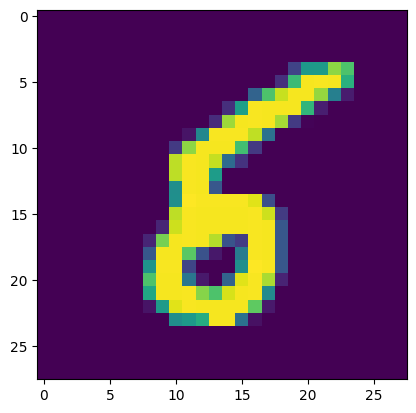


Label: [3] | Predicted: 2



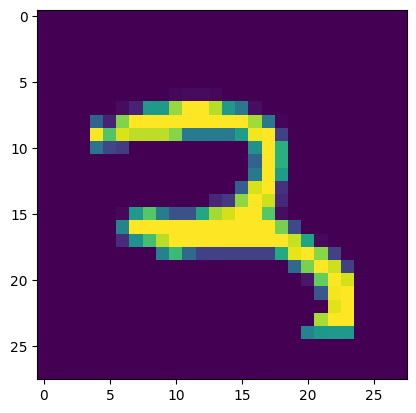


Label: [8] | Predicted: 3



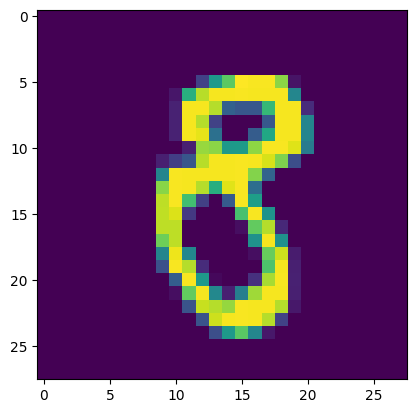


Label: [9] | Predicted: 0



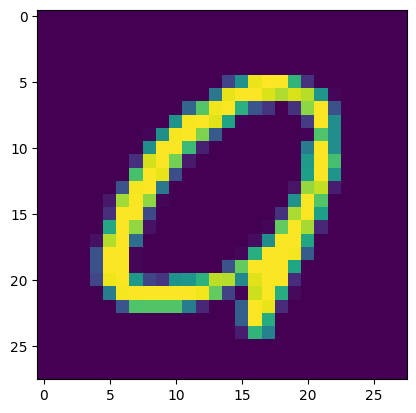


Label: [8] | Predicted: 5



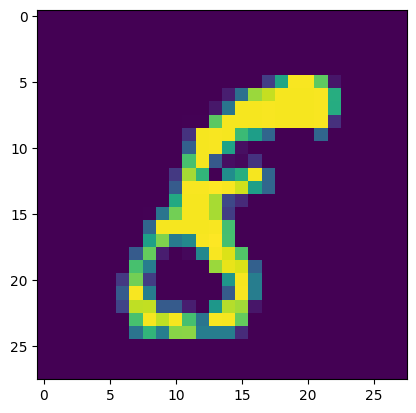


Label: [5] | Predicted: 8



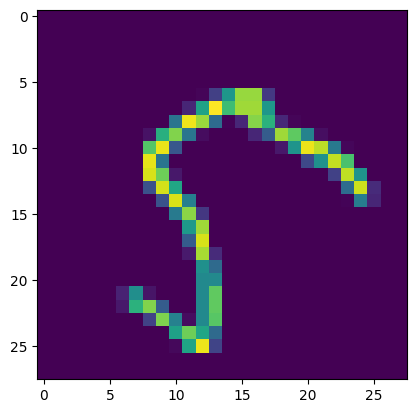


Label: [4] | Predicted: 7



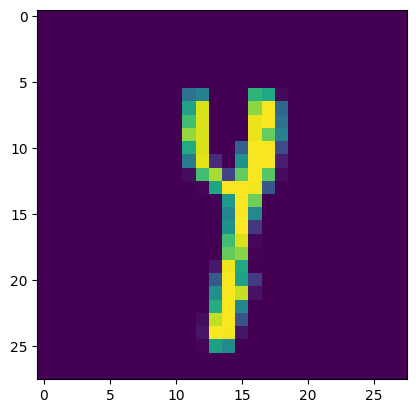


Label: [5] | Predicted: 8



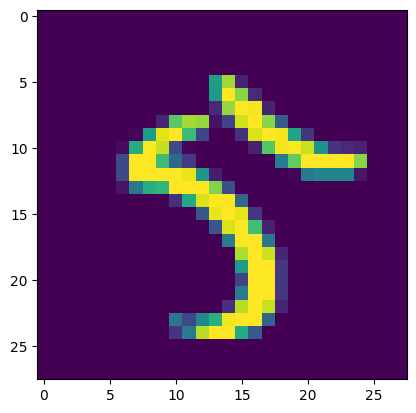


Label: [3] | Predicted: 7



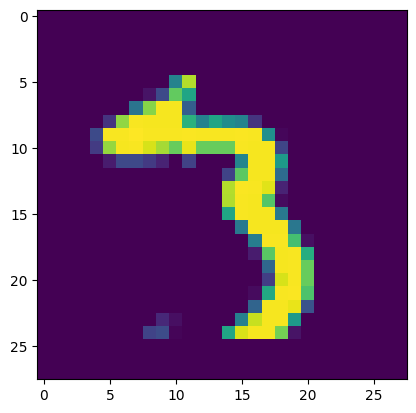


Label: [3] | Predicted: 7



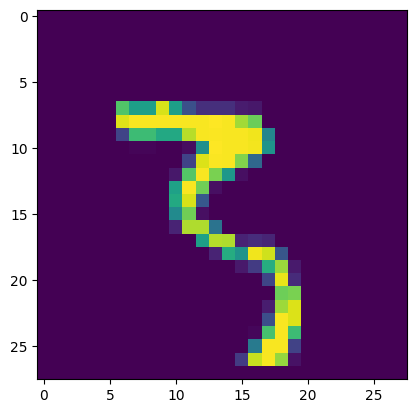


Label: [5] | Predicted: 8



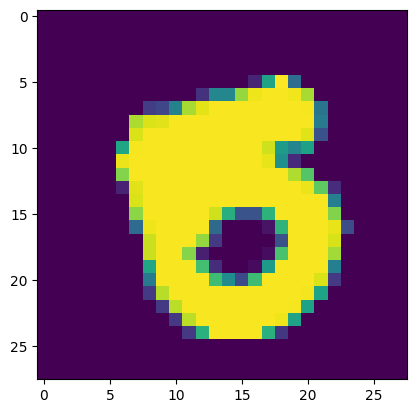


Label: [5] | Predicted: 8



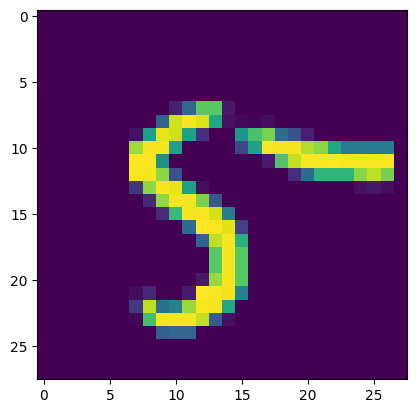


Label: [9] | Predicted: 7



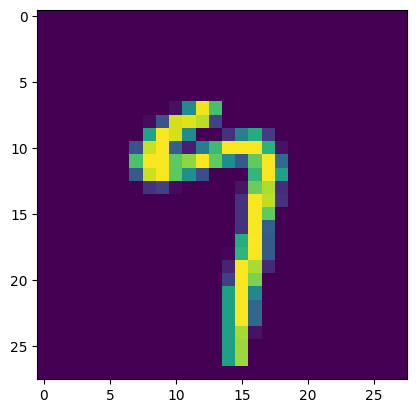


Label: [9] | Predicted: 7



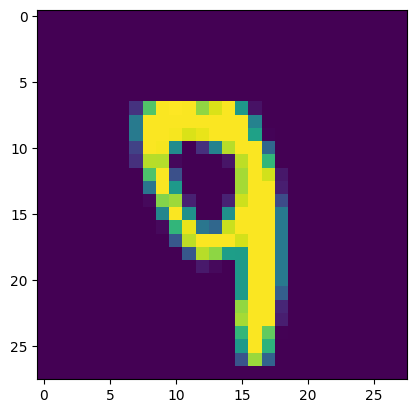


Label: [8] | Predicted: 9



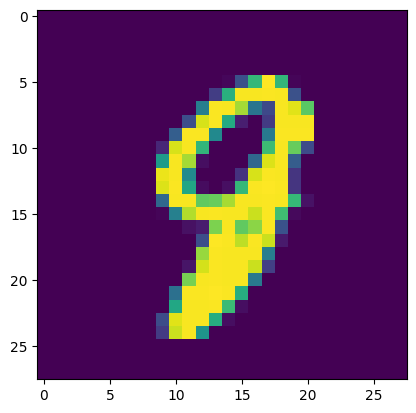


Label: [5] | Predicted: 1



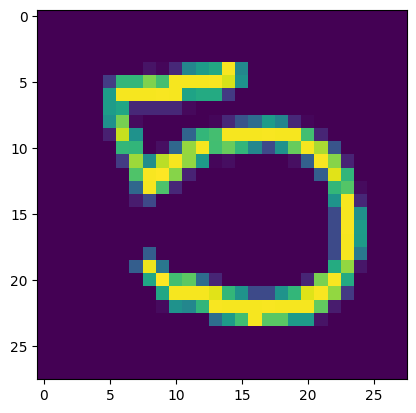


Label: [7] | Predicted: 9



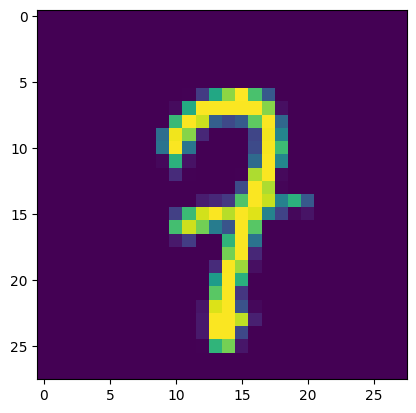


Label: [4] | Predicted: 9



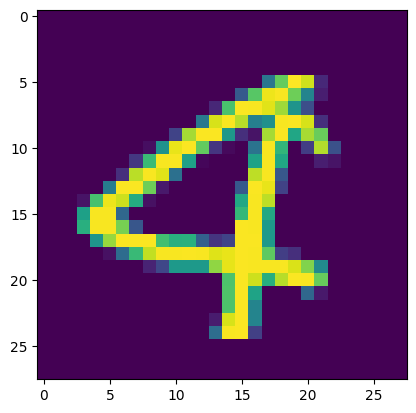


Label: [8] | Predicted: 5



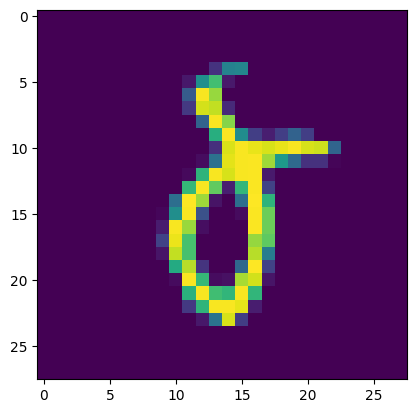


Label: [2] | Predicted: 6



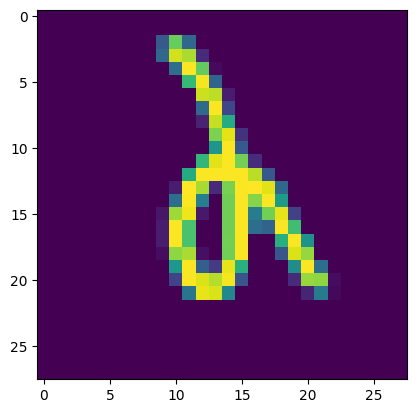


Label: [9] | Predicted: 8



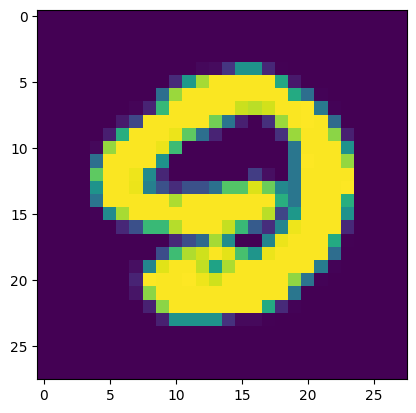


Label: [8] | Predicted: 0



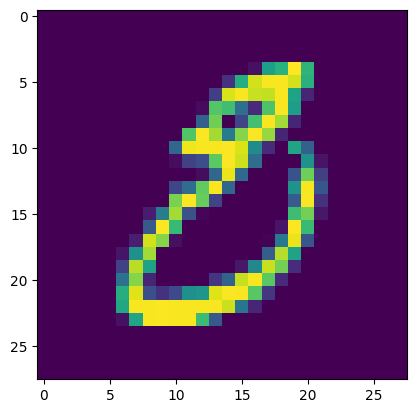


Label: [7] | Predicted: 2



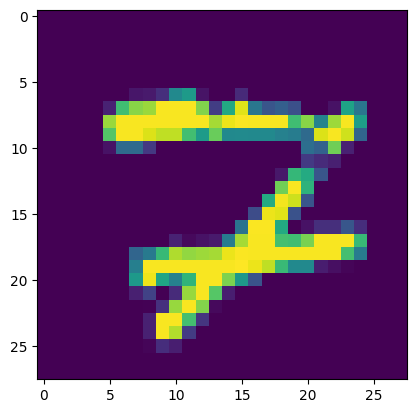


Label: [5] | Predicted: 3



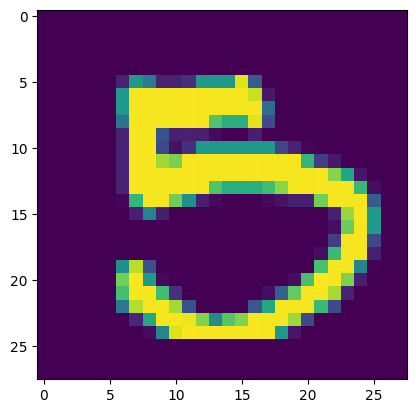


Label: [3] | Predicted: 5



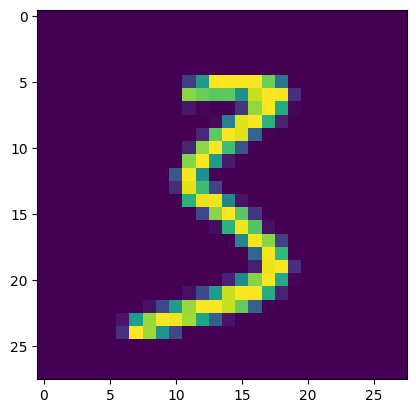


Label: [9] | Predicted: 4



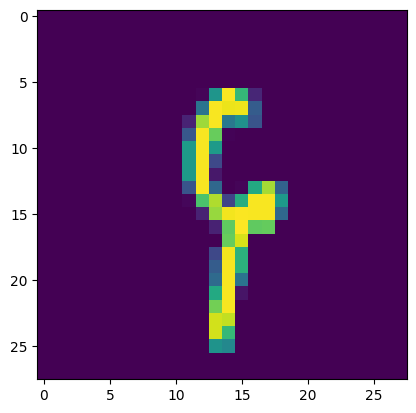


Label: [3] | Predicted: 5



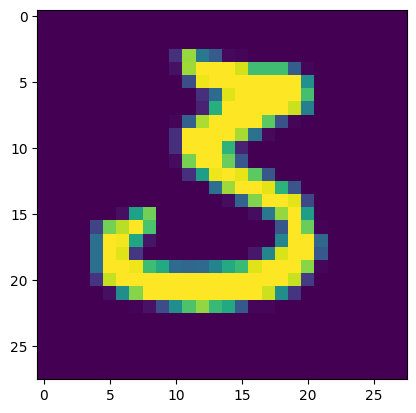


Label: [7] | Predicted: 9



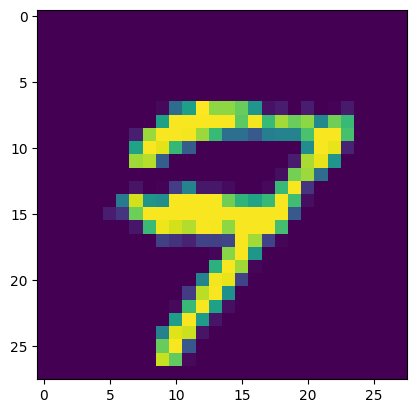


Label: [8] | Predicted: 5



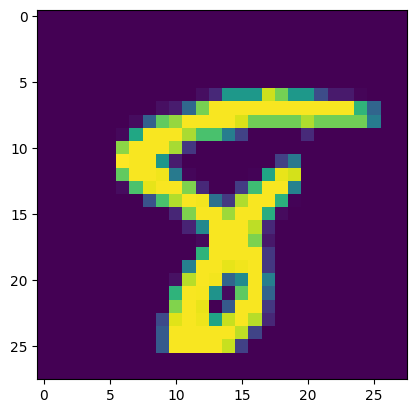


Label: [3] | Predicted: 2



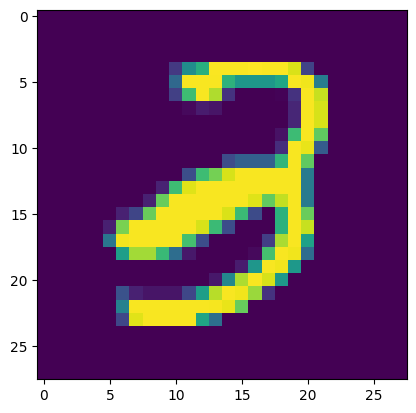


Label: [7] | Predicted: 9



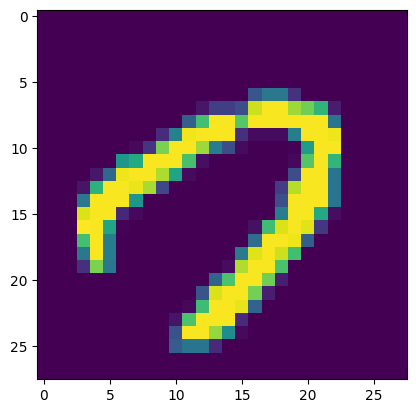


Label: [8] | Predicted: 3



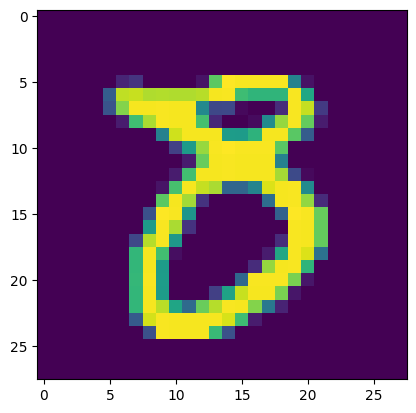


Label: [4] | Predicted: 1



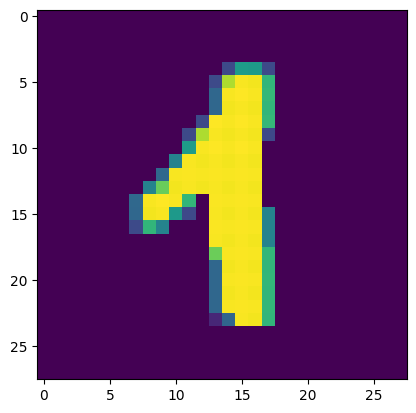


Label: [3] | Predicted: 8



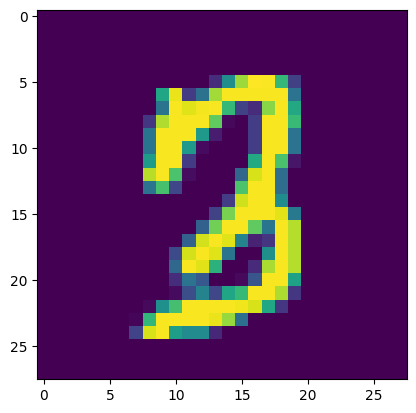


Label: [3] | Predicted: 8



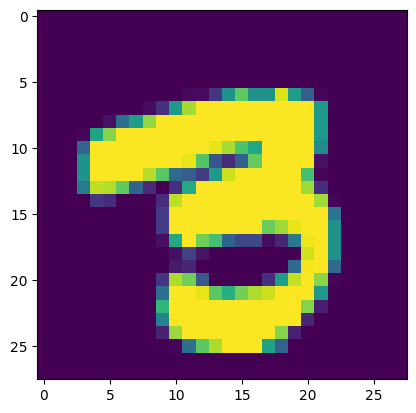


Label: [7] | Predicted: 2



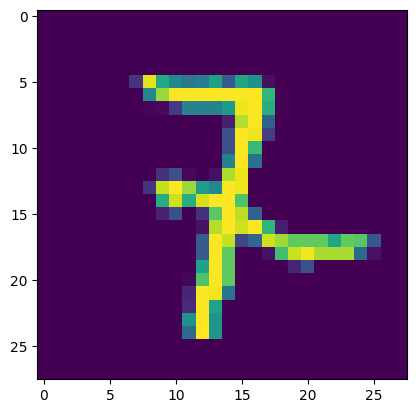


Label: [1] | Predicted: 6



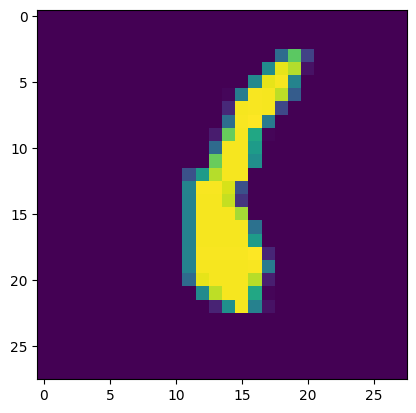


Label: [1] | Predicted: 2



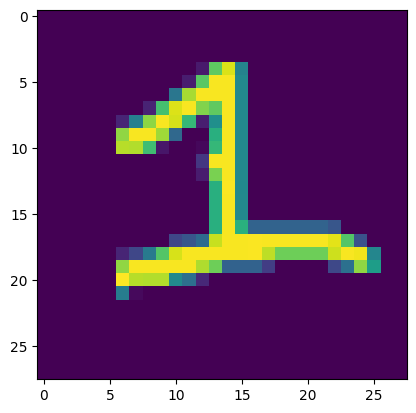


Label: [3] | Predicted: 8



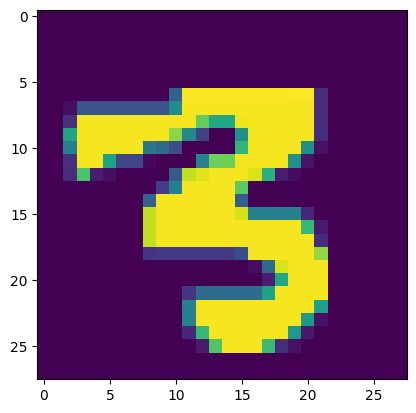


Label: [9] | Predicted: 1



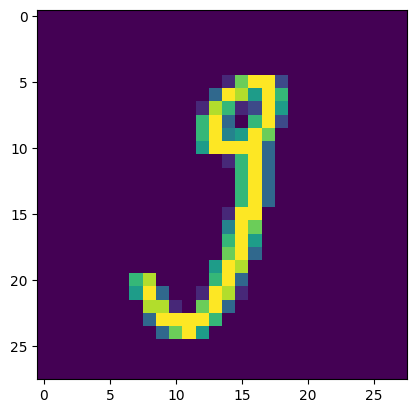


Label: [8] | Predicted: 6



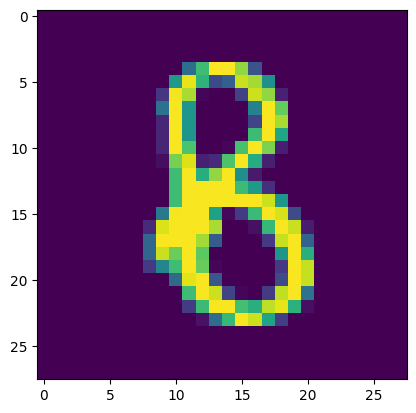


Label: [8] | Predicted: 5



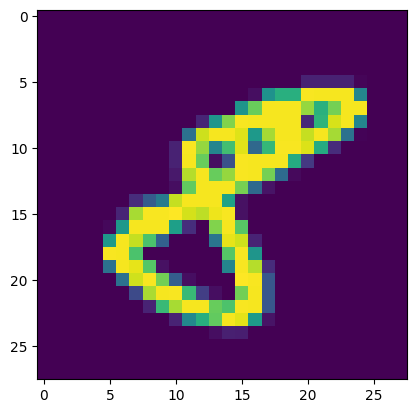


Label: [2] | Predicted: 1



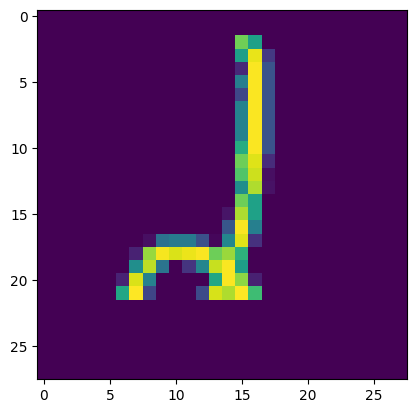


Label: [3] | Predicted: 9



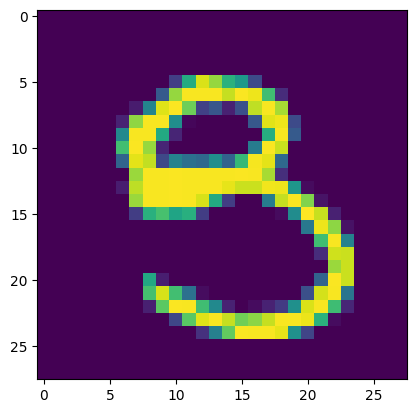


Label: [4] | Predicted: 8



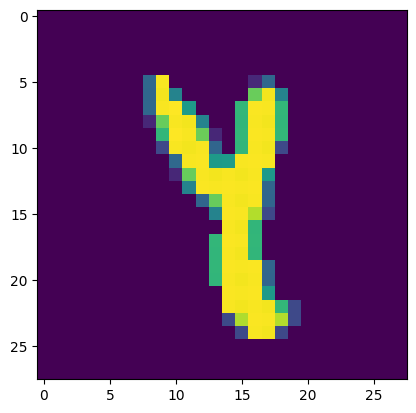


Label: [6] | Predicted: 0



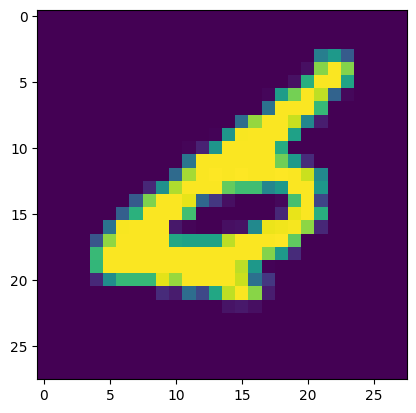


Label: [3] | Predicted: 5



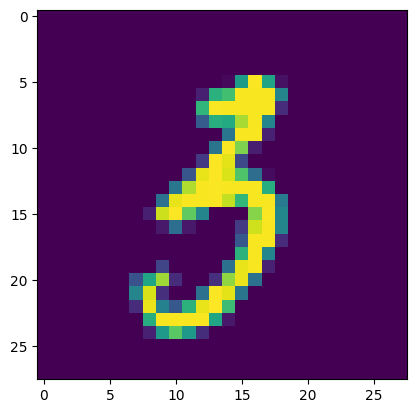


Label: [3] | Predicted: 0



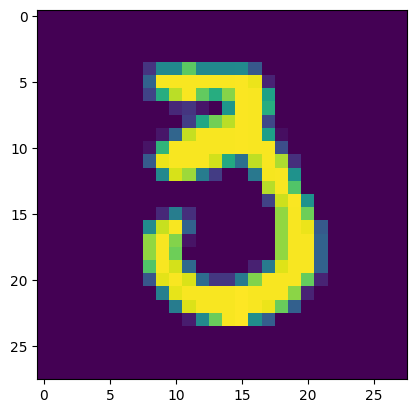


Label: [5] | Predicted: 6



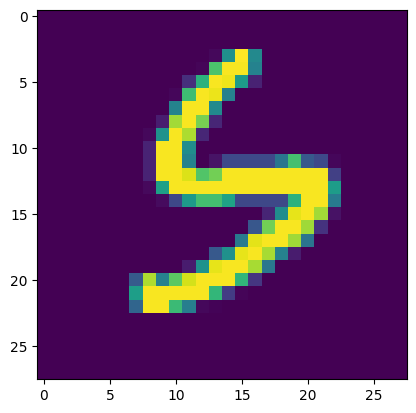


Label: [8] | Predicted: 9



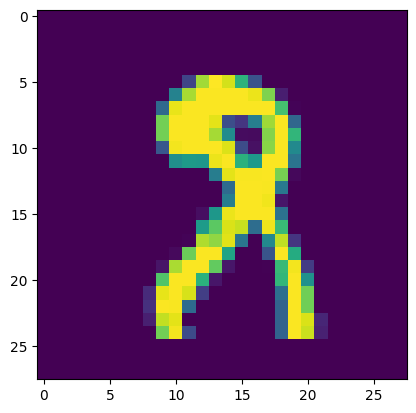


Label: [7] | Predicted: 9



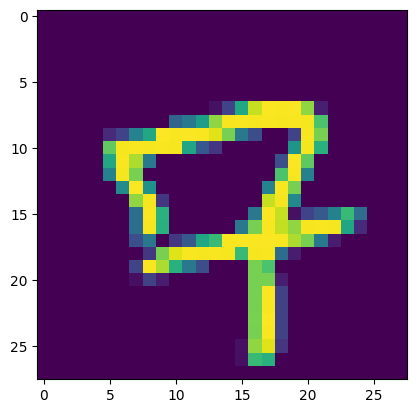


Label: [3] | Predicted: 5



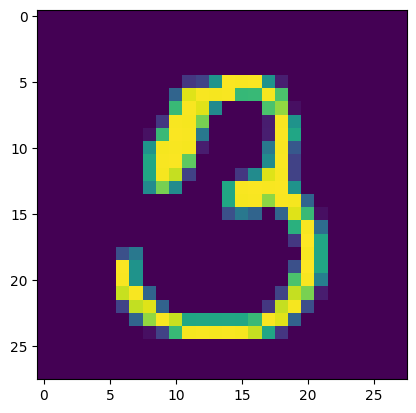


Label: [5] | Predicted: 3



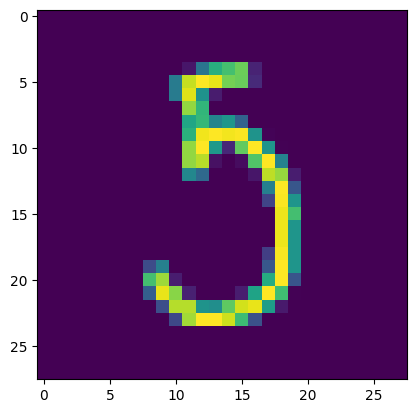


Label: [3] | Predicted: 5



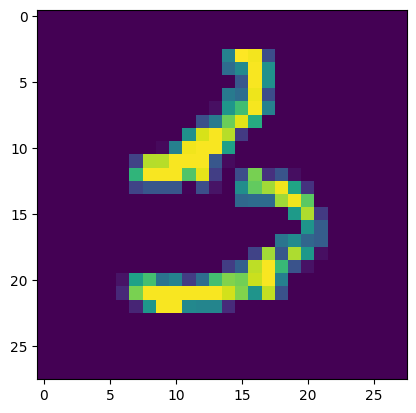


Label: [8] | Predicted: 0



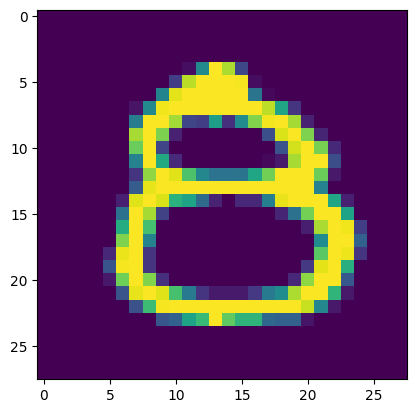


Label: [6] | Predicted: 8



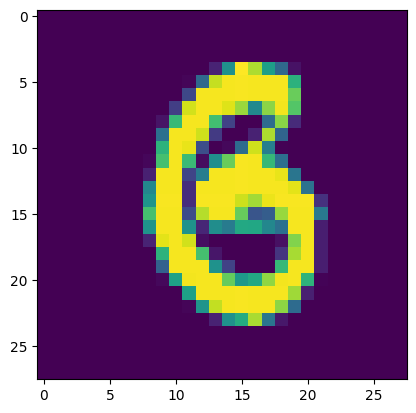


Label: [3] | Predicted: 2



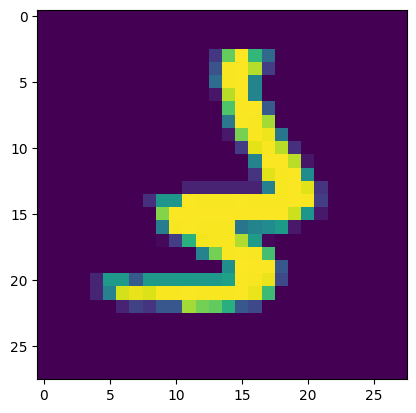


Label: [6] | Predicted: 2



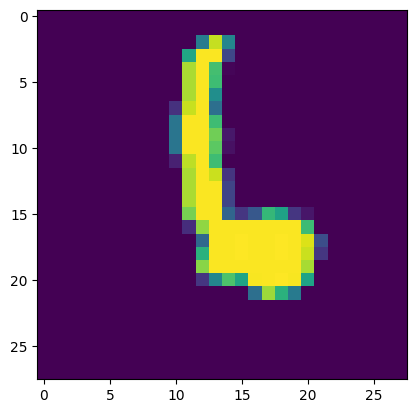


Label: [8] | Predicted: 5



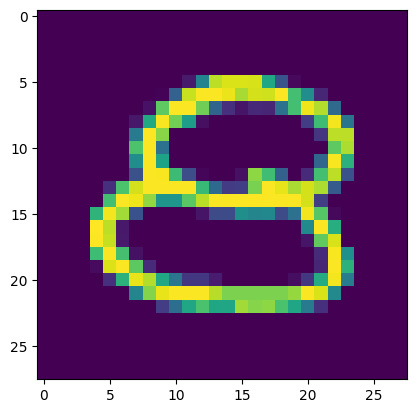


Label: [4] | Predicted: 1



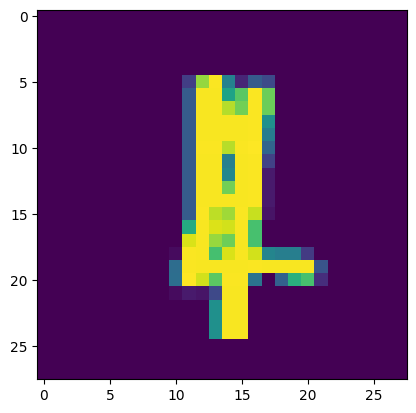


Label: [7] | Predicted: 9



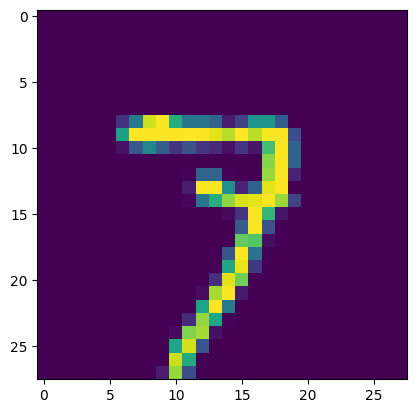


Label: [5] | Predicted: 0



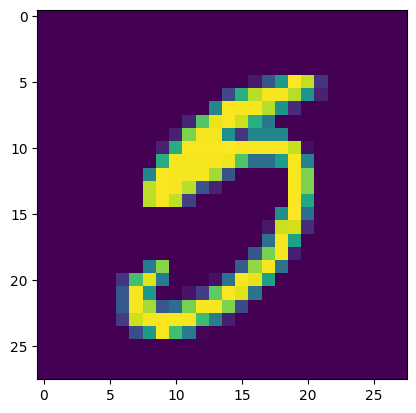


Label: [7] | Predicted: 9



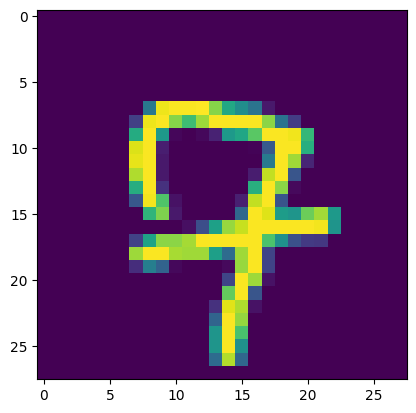


Label: [8] | Predicted: 9



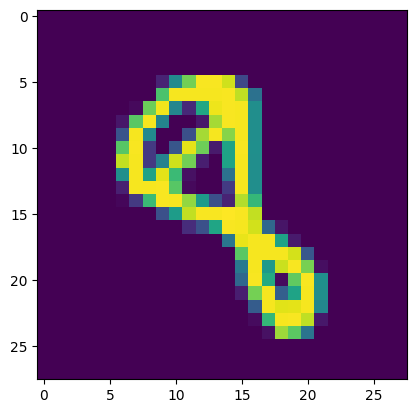


Label: [1] | Predicted: 8



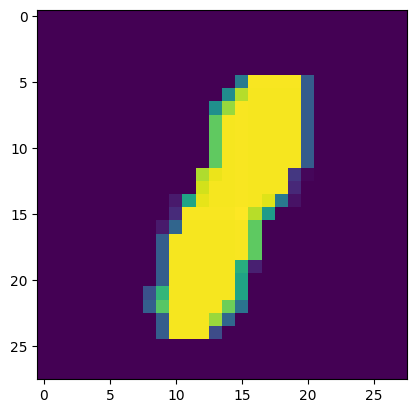


Label: [5] | Predicted: 3



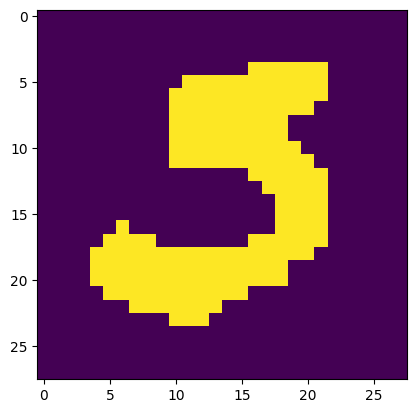


Label: [5] | Predicted: 8



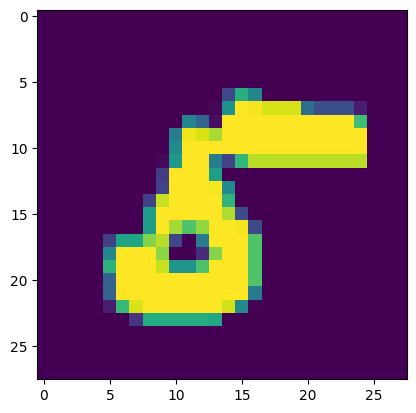


Label: [3] | Predicted: 8



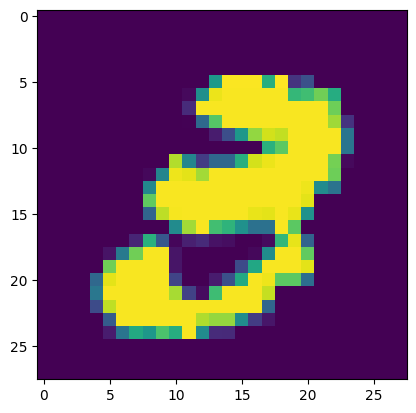


Label: [5] | Predicted: 3



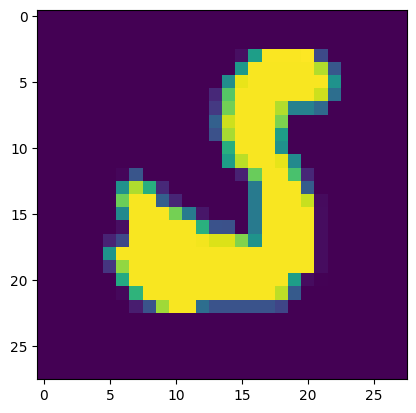


Label: [5] | Predicted: 2



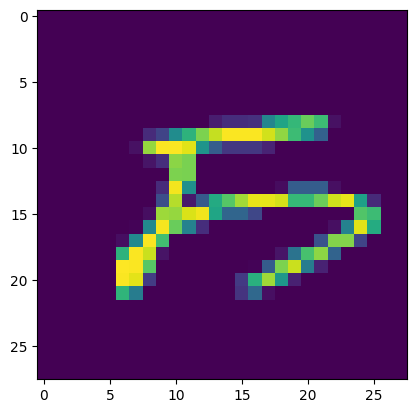


Label: [2] | Predicted: 1



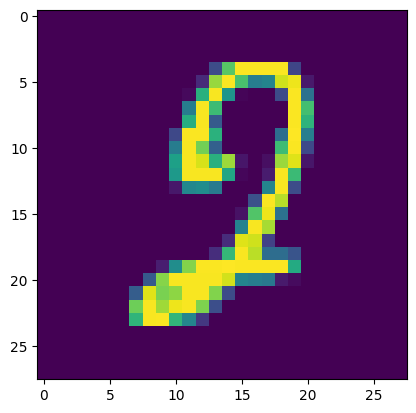


Label: [5] | Predicted: 9



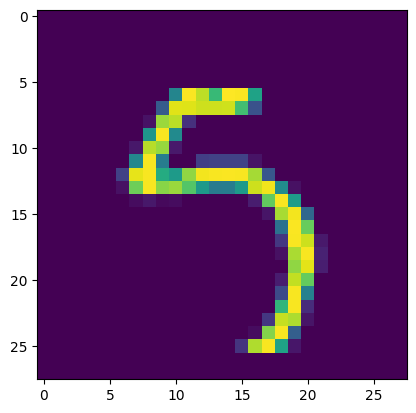


Label: [8] | Predicted: 5



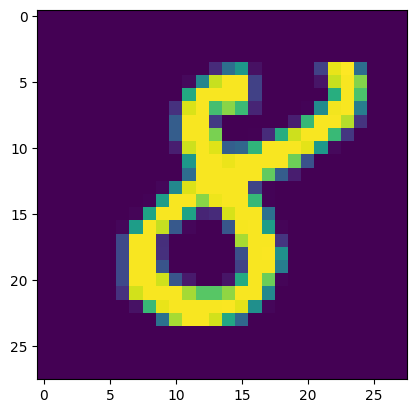


Label: [5] | Predicted: 3



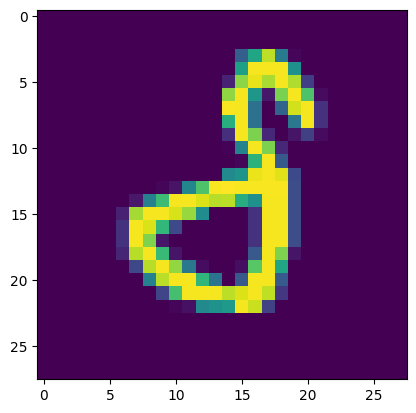


Label: [8] | Predicted: 1



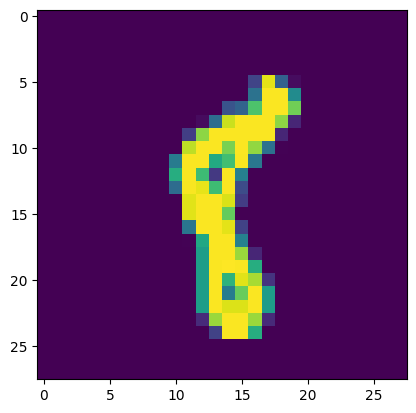


Label: [4] | Predicted: 0



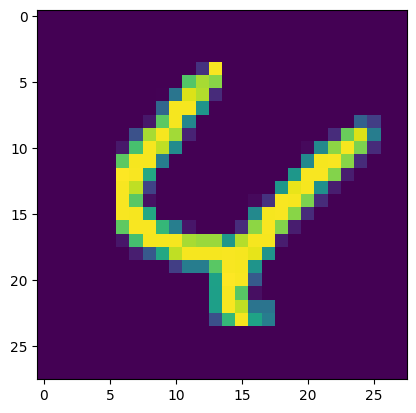


Label: [6] | Predicted: 4



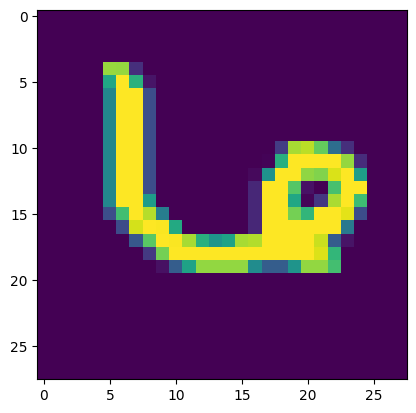


Label: [7] | Predicted: 9



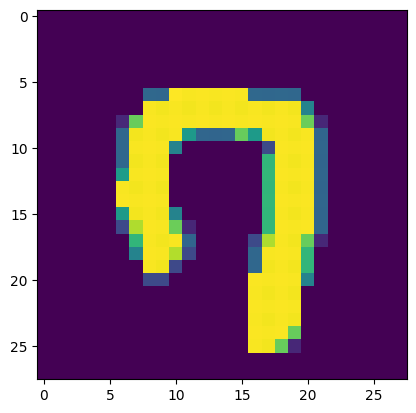


Label: [9] | Predicted: 8



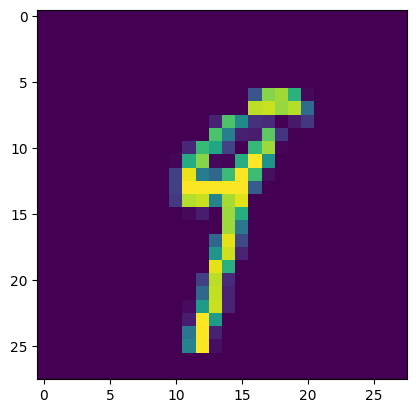


Label: [9] | Predicted: 7



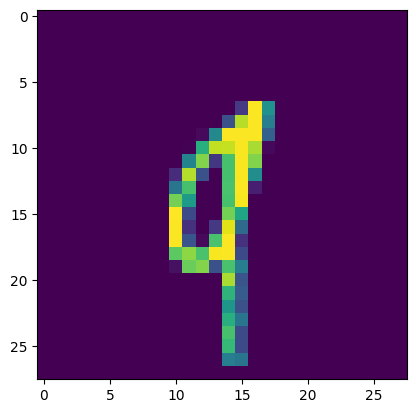


Label: [7] | Predicted: 0



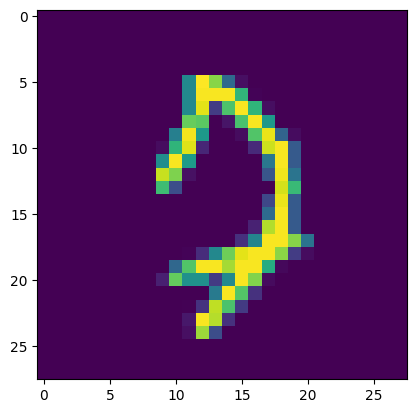


Label: [4] | Predicted: 9



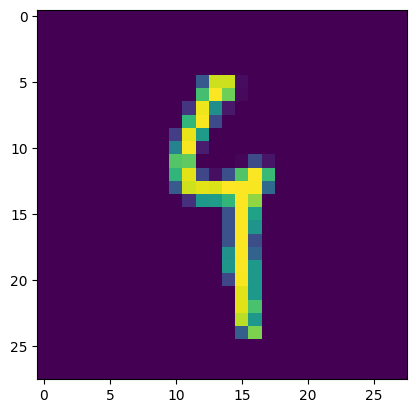


Label: [0] | Predicted: 2



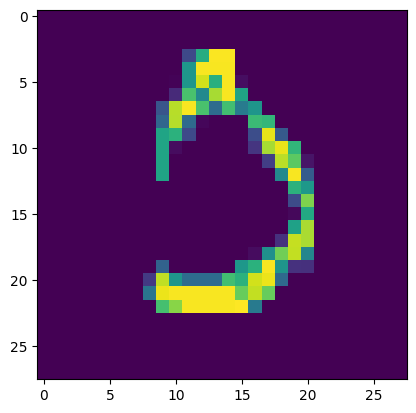


Label: [4] | Predicted: 9



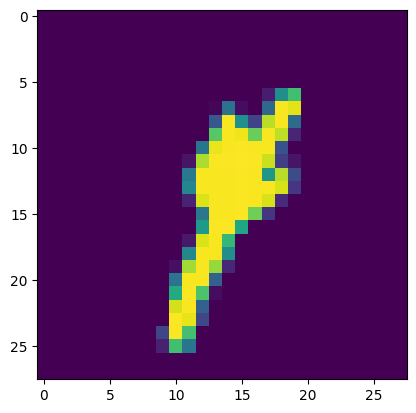


Label: [9] | Predicted: 3



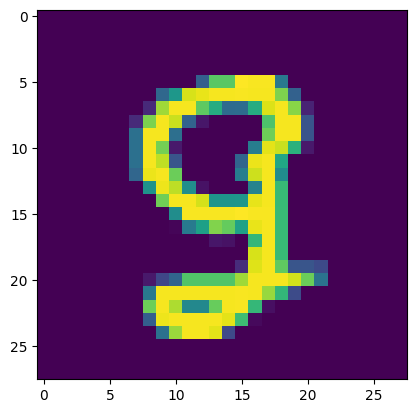


Label: [9] | Predicted: 7



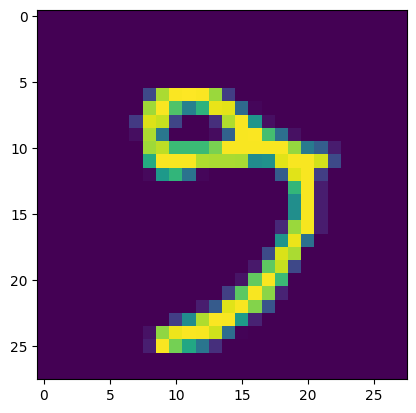


Label: [2] | Predicted: 8



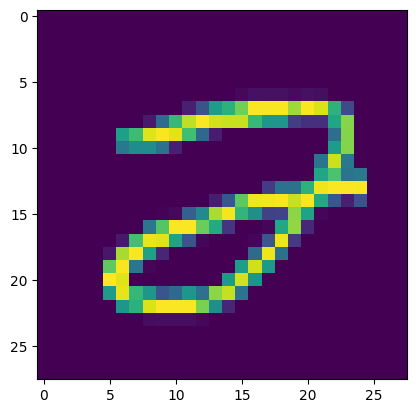


Label: [2] | Predicted: 3



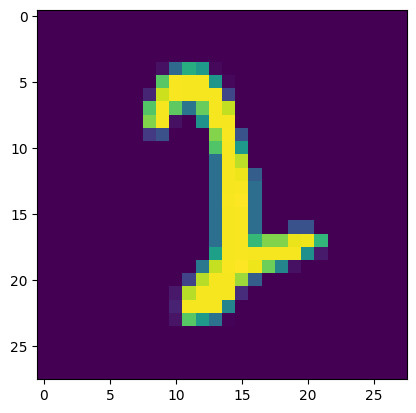


Label: [4] | Predicted: 9



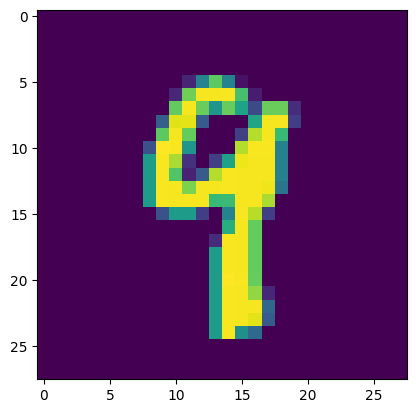


Label: [9] | Predicted: 8



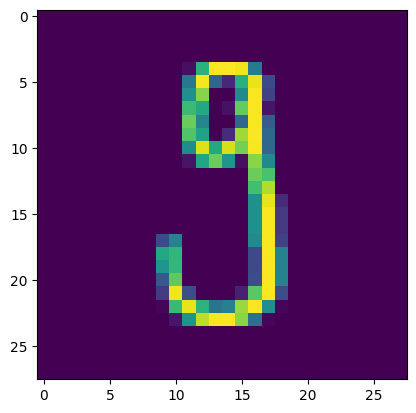


Label: [5] | Predicted: 0



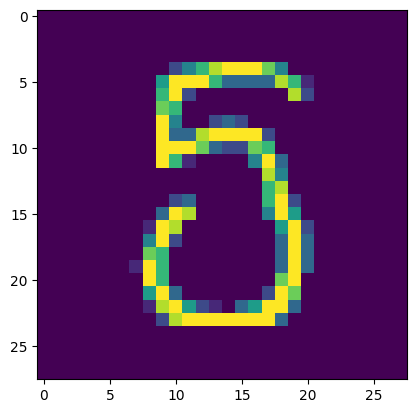


Label: [8] | Predicted: 5



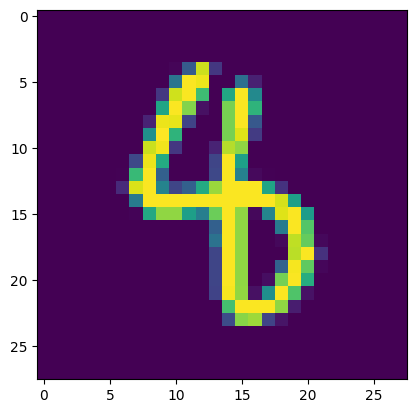


Label: [7] | Predicted: 3



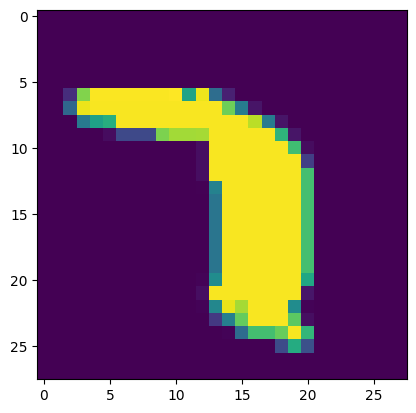


Label: [5] | Predicted: 3



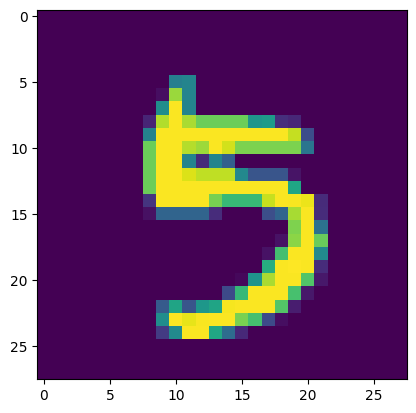


Label: [0] | Predicted: 7



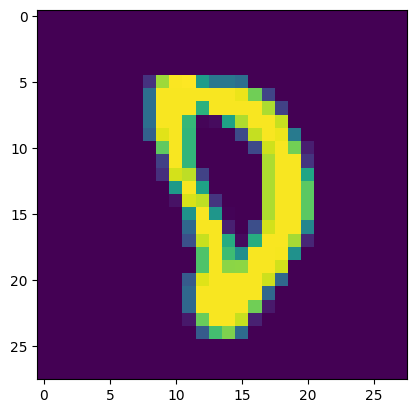


Label: [2] | Predicted: 7



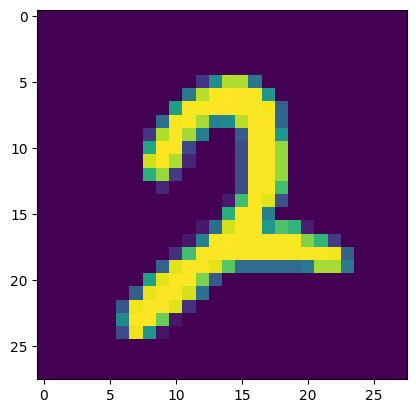


Label: [0] | Predicted: 9



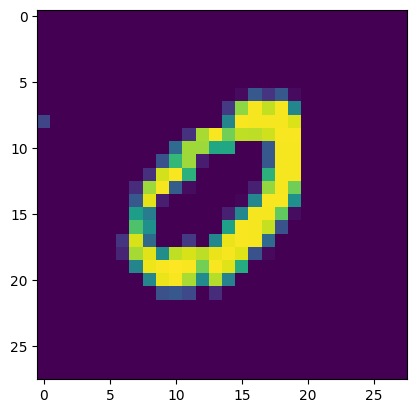


Label: [5] | Predicted: 3



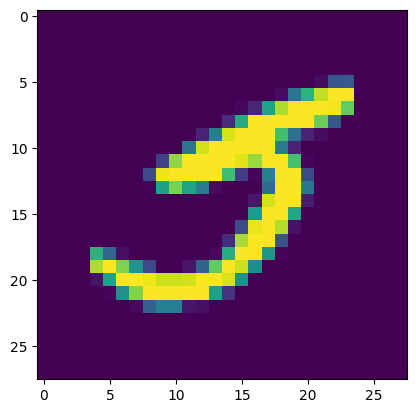


Label: [8] | Predicted: 3



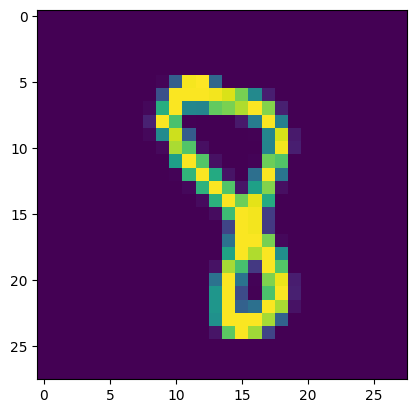


Label: [5] | Predicted: 6



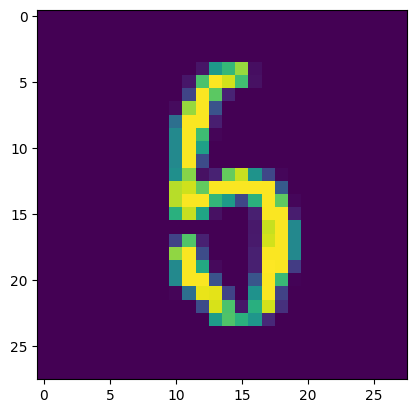


Label: [8] | Predicted: 2



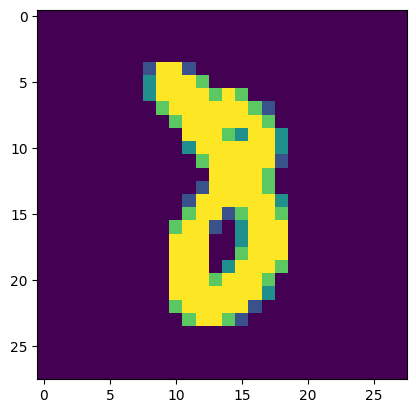


Label: [5] | Predicted: 8



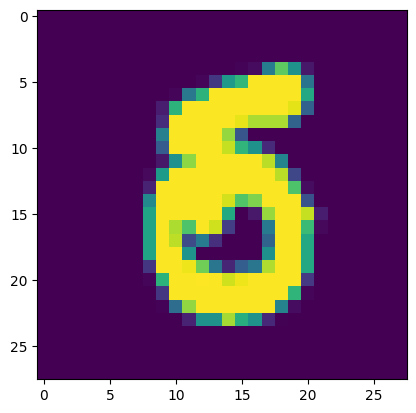


Label: [5] | Predicted: 3



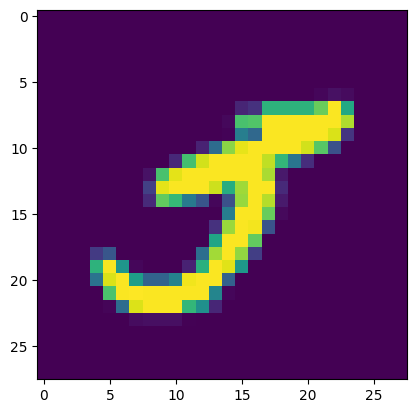


Label: [2] | Predicted: 6



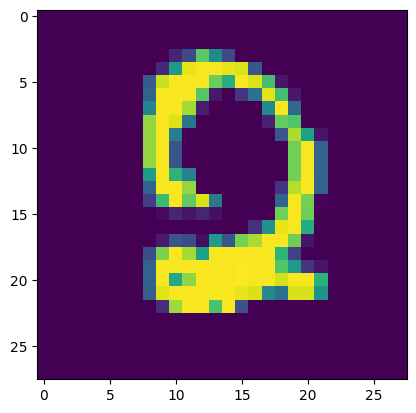


Label: [7] | Predicted: 3



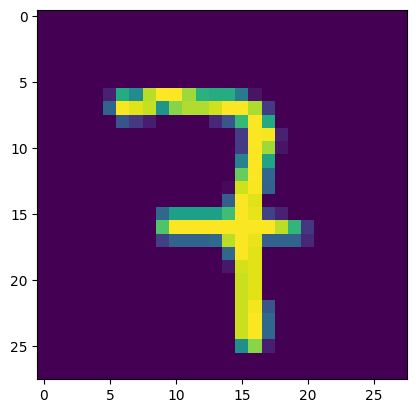


Label: [3] | Predicted: 5



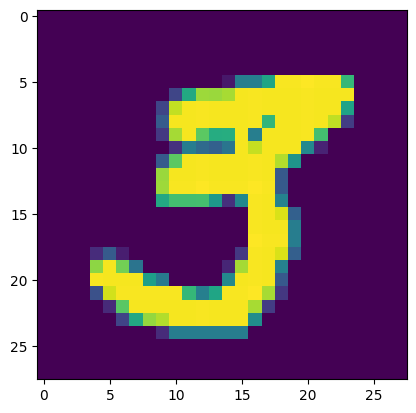


Label: [0] | Predicted: 3



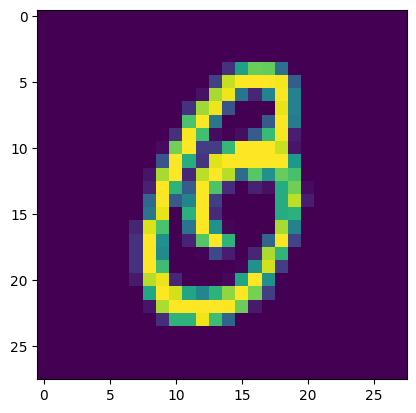


Label: [5] | Predicted: 6



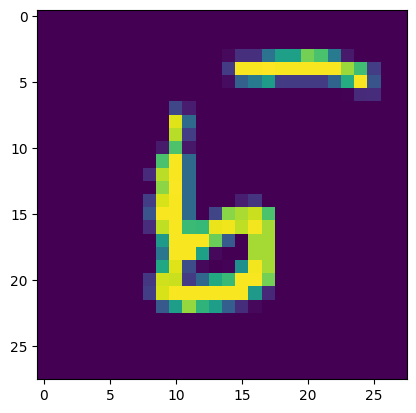


Label: [8] | Predicted: 3



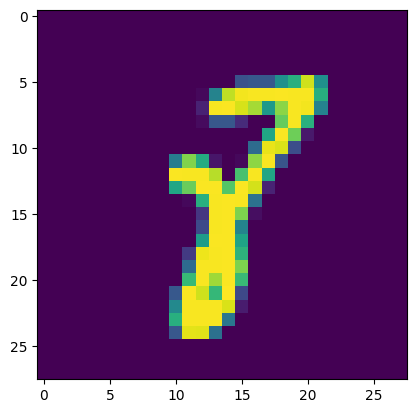


Label: [8] | Predicted: 3



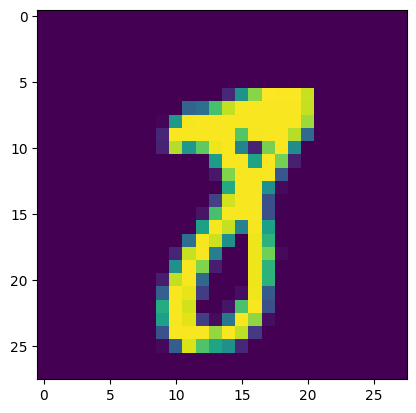


Label: [4] | Predicted: 9



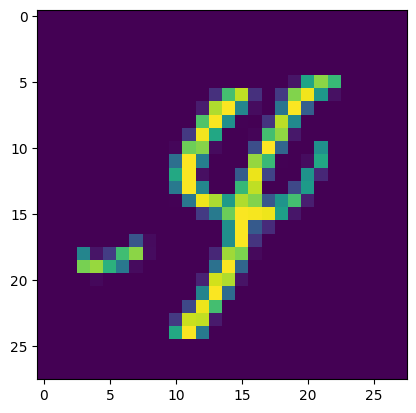


Label: [9] | Predicted: 5



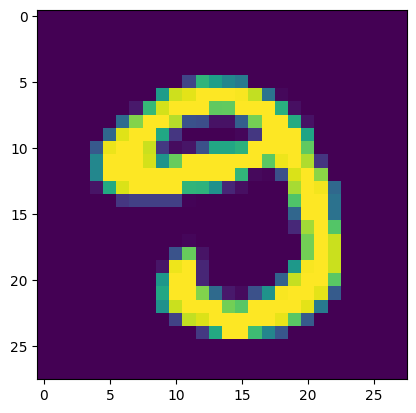


Label: [6] | Predicted: 5



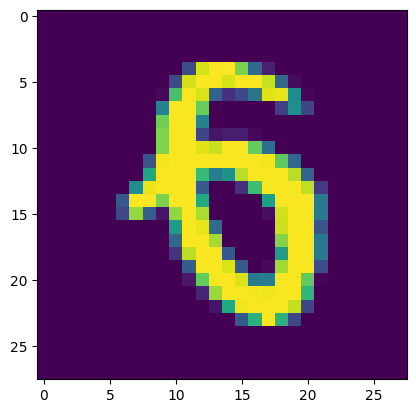


Label: [2] | Predicted: 3



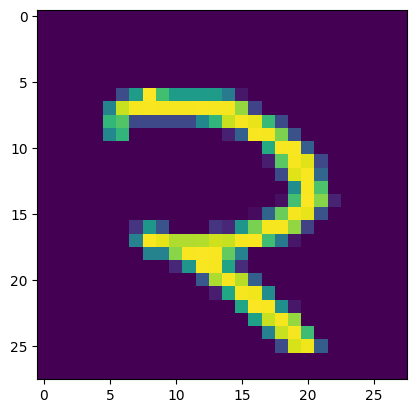


Label: [4] | Predicted: 9



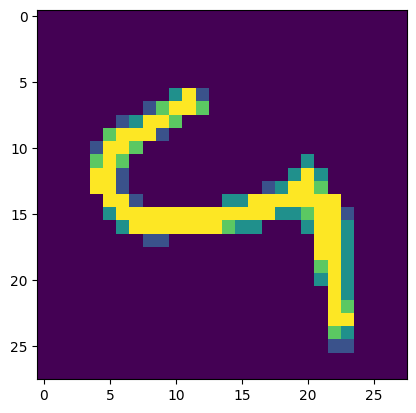


Label: [5] | Predicted: 3



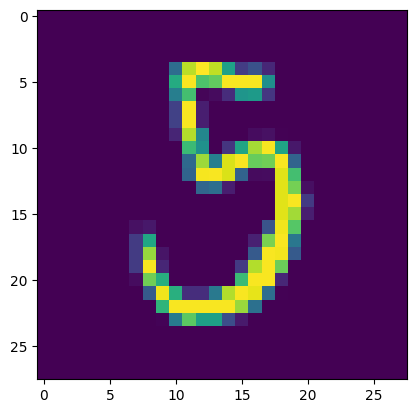


Label: [1] | Predicted: 7



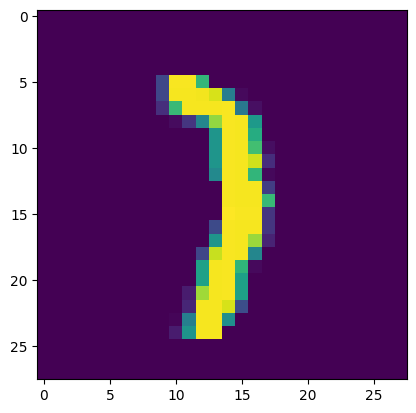


Label: [3] | Predicted: 5



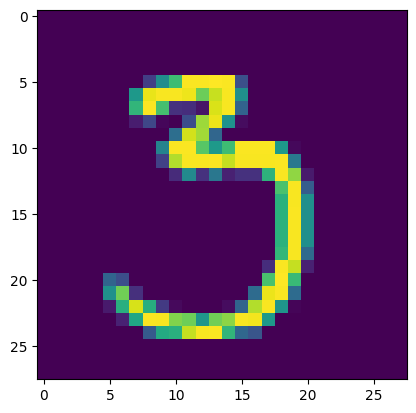


Label: [3] | Predicted: 8



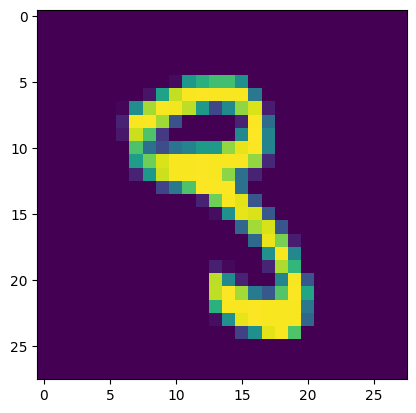


Label: [4] | Predicted: 1



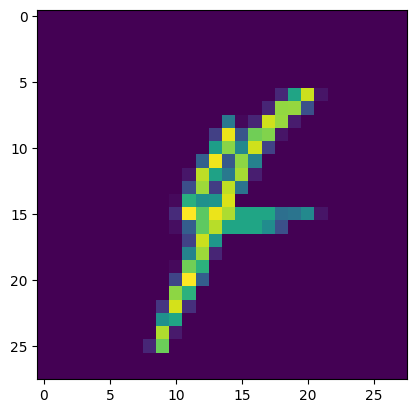


Label: [9] | Predicted: 4



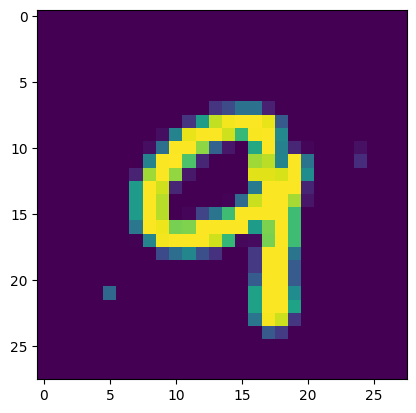


Label: [0] | Predicted: 3



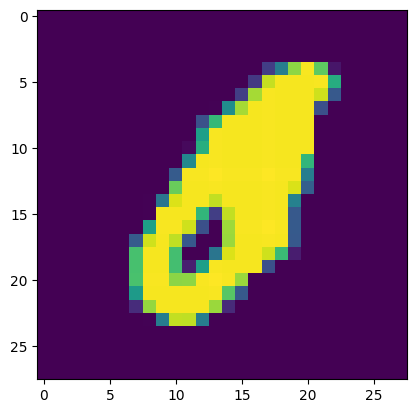


Label: [9] | Predicted: 4



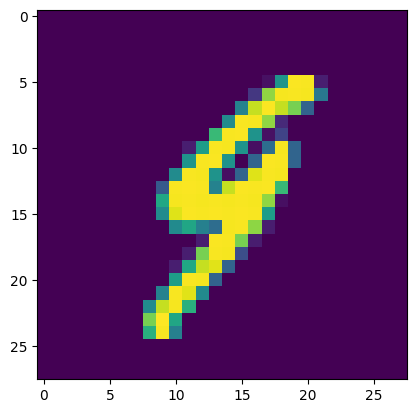


Label: [9] | Predicted: 4



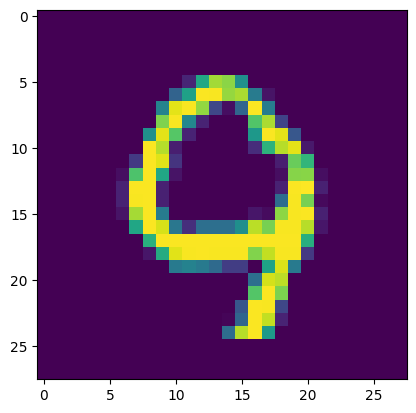


Label: [6] | Predicted: 0



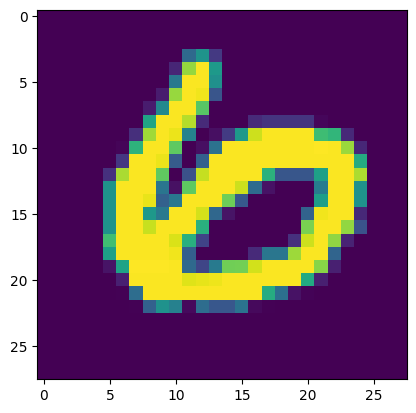


Label: [9] | Predicted: 8



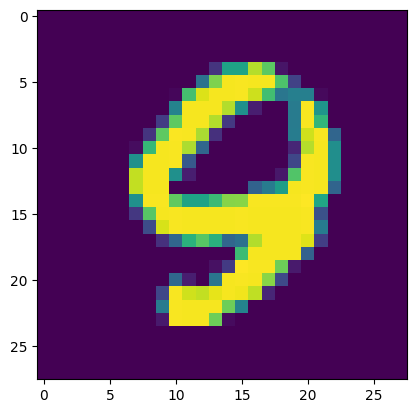


Label: [9] | Predicted: 3



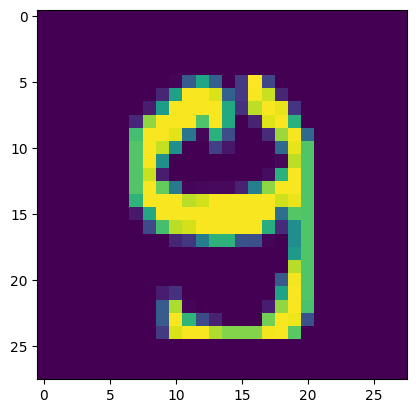


Label: [0] | Predicted: 2



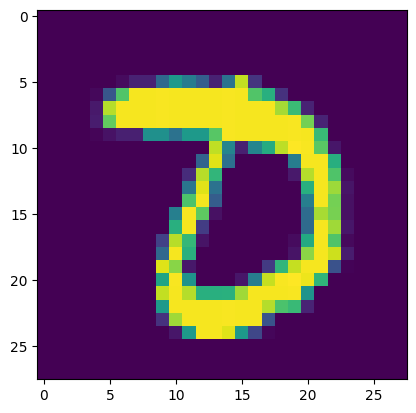


Label: [7] | Predicted: 1



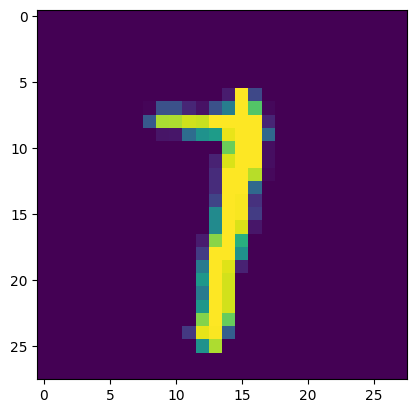


Label: [0] | Predicted: 6



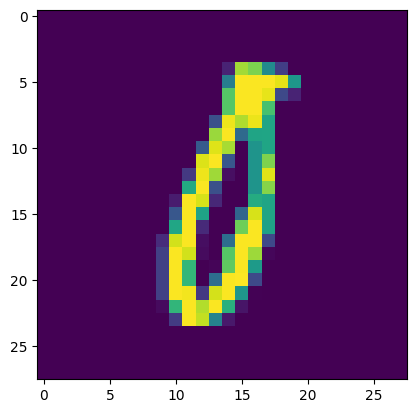


Label: [7] | Predicted: 4



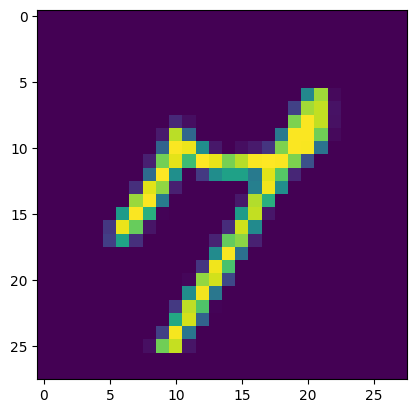


Label: [5] | Predicted: 3



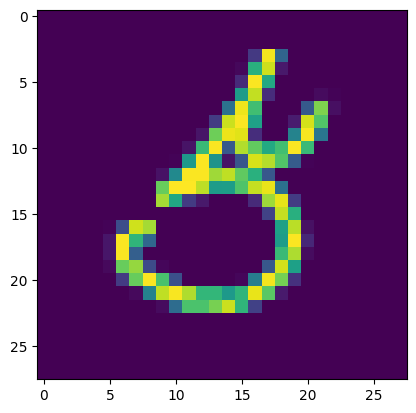


Label: [3] | Predicted: 8



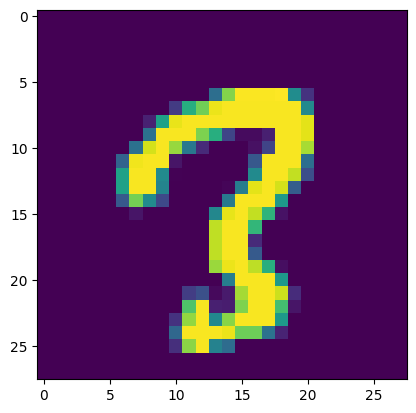


Label: [5] | Predicted: 9



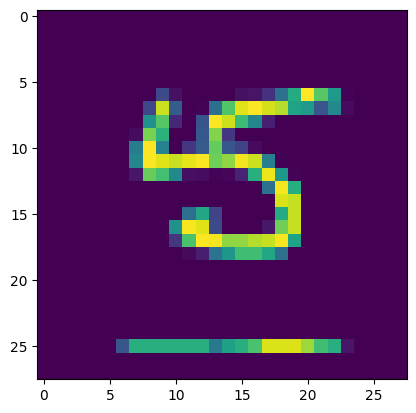


Label: [1] | Predicted: 6



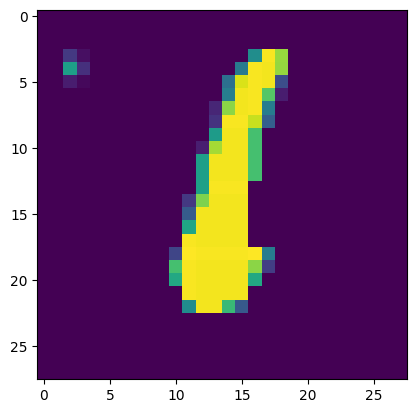


Label: [9] | Predicted: 7



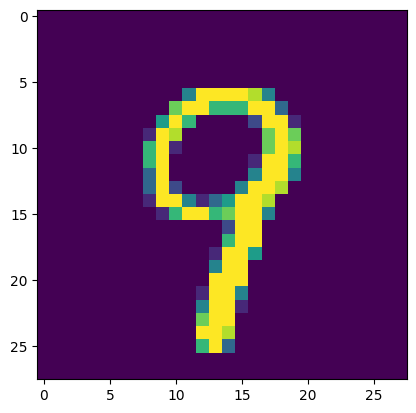


Label: [1] | Predicted: 8



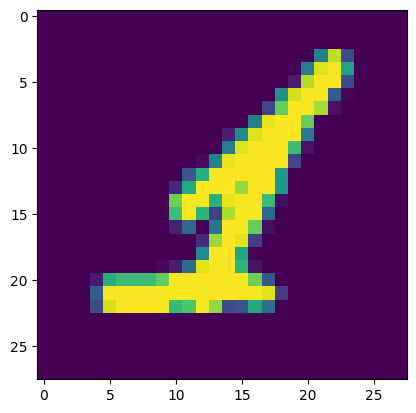


Label: [1] | Predicted: 8



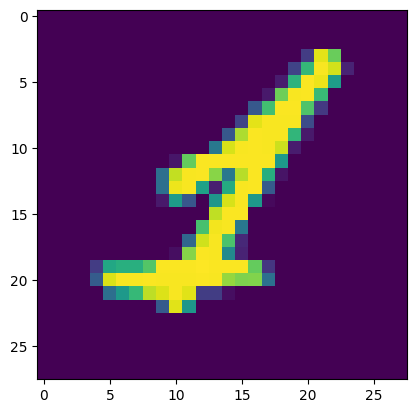


Label: [4] | Predicted: 2



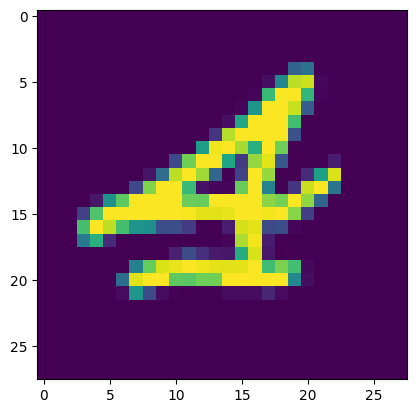


Label: [9] | Predicted: 8



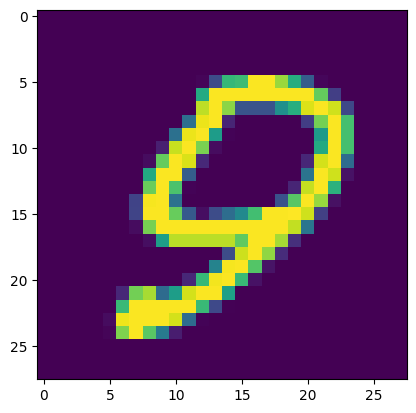


Label: [1] | Predicted: 8



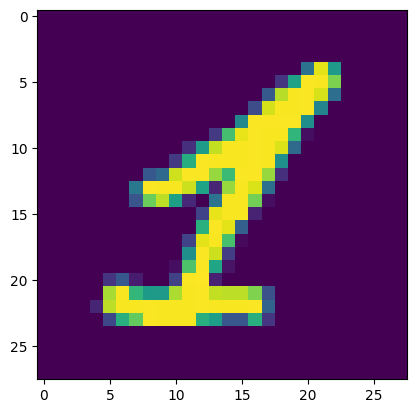


Label: [1] | Predicted: 8



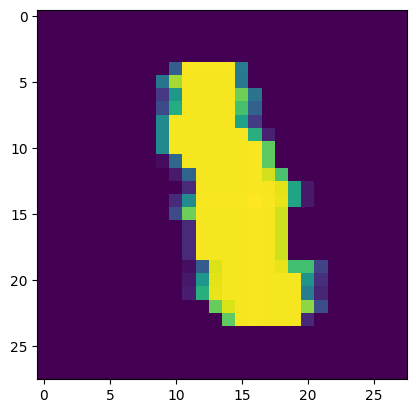


Label: [4] | Predicted: 9



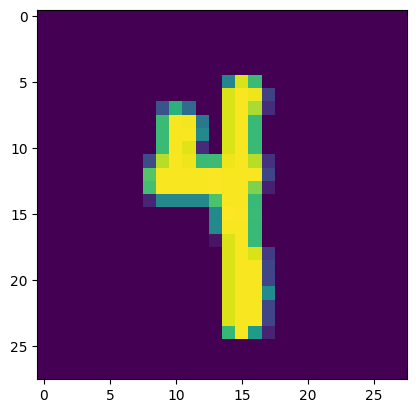


Label: [8] | Predicted: 6



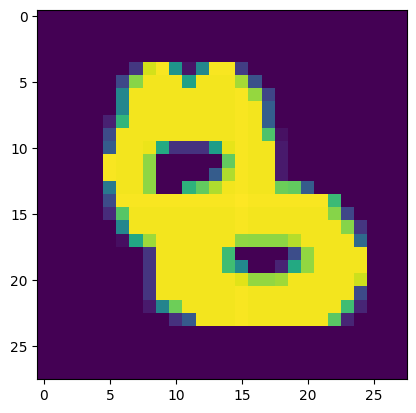


Label: [1] | Predicted: 3



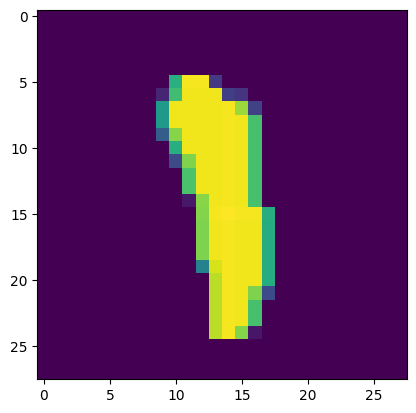


Label: [0] | Predicted: 9



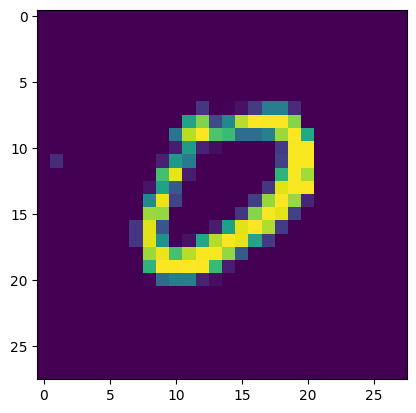


Label: [5] | Predicted: 6



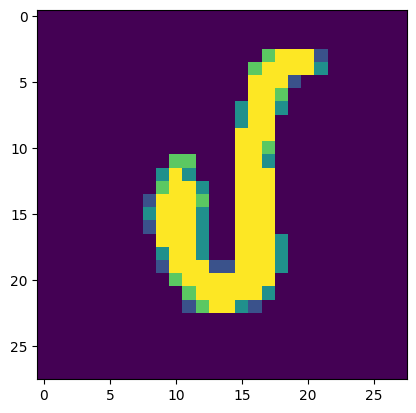


Label: [2] | Predicted: 0



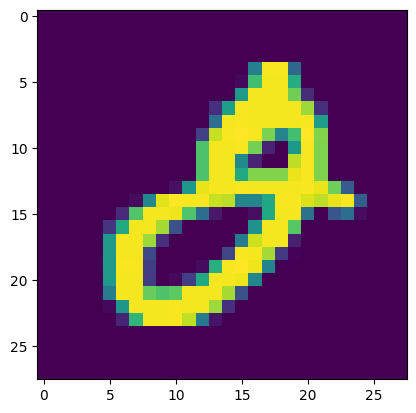


Label: [5] | Predicted: 3



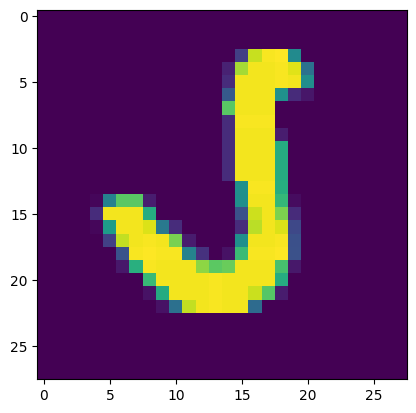


Label: [5] | Predicted: 6



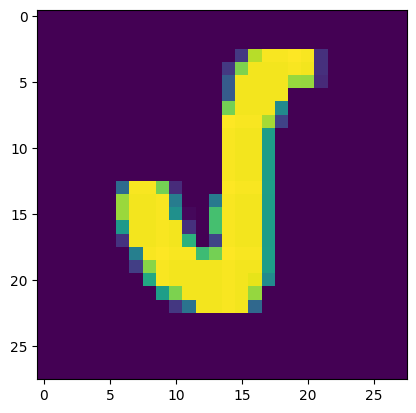


Label: [5] | Predicted: 6



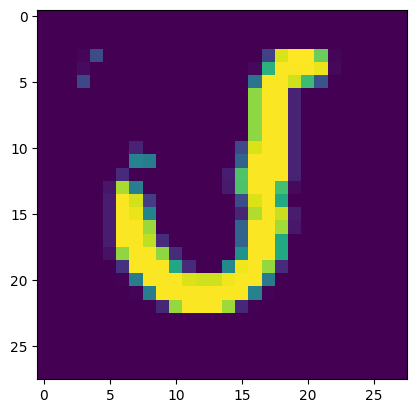


Label: [2] | Predicted: 0



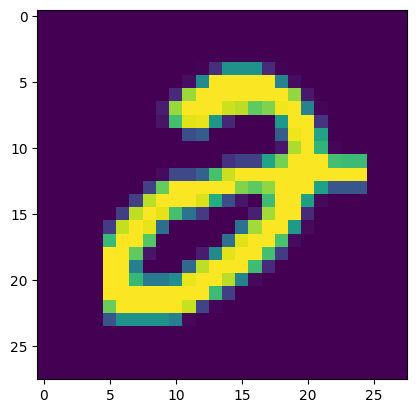


Label: [7] | Predicted: 3



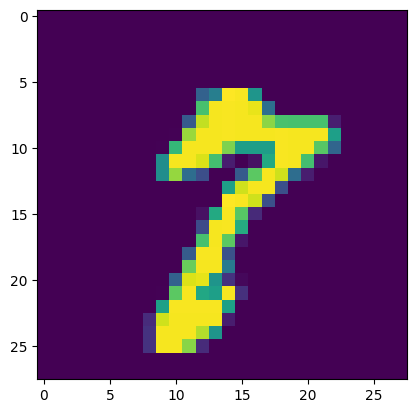


Label: [4] | Predicted: 7



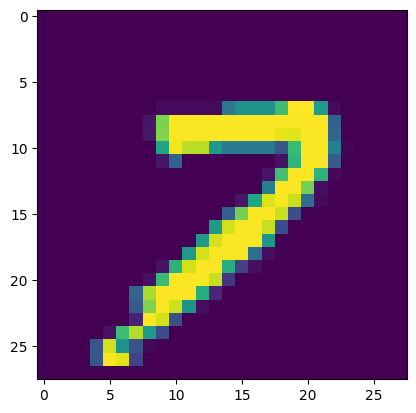


Label: [9] | Predicted: 5



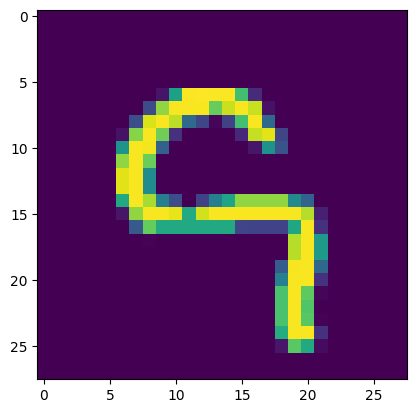


Label: [4] | Predicted: 9



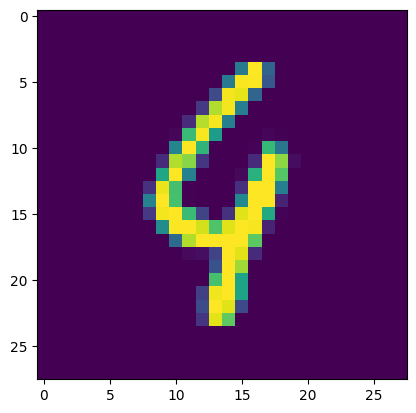


Label: [9] | Predicted: 8



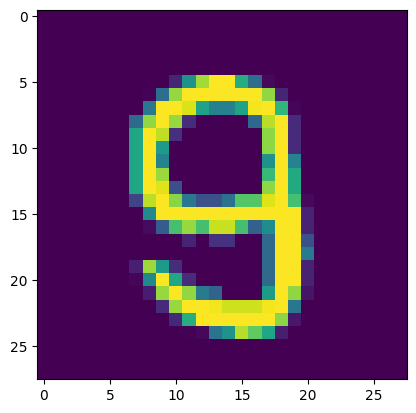


Label: [4] | Predicted: 6



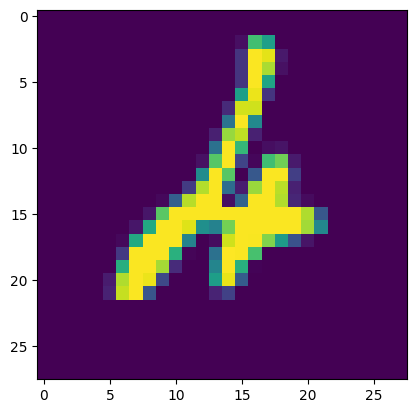


Label: [6] | Predicted: 0



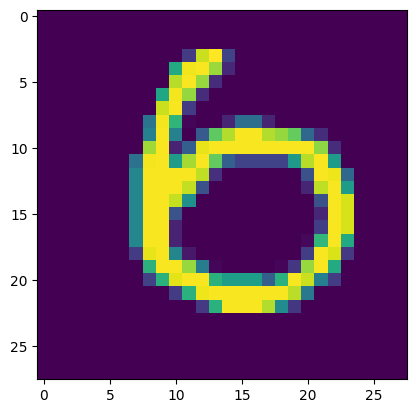


Label: [2] | Predicted: 7



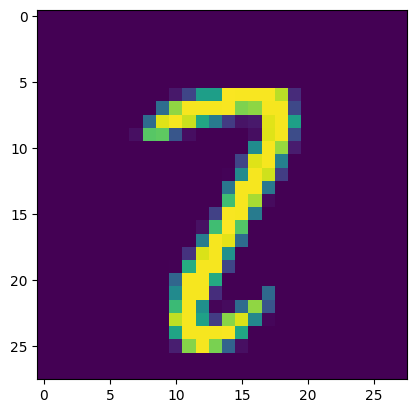


Label: [5] | Predicted: 3



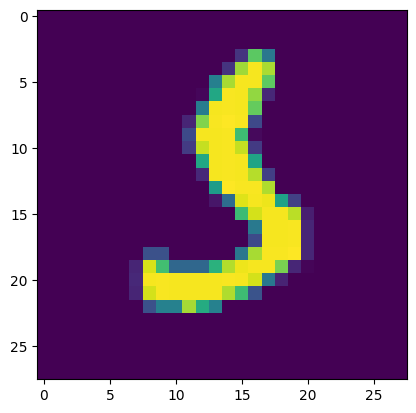


Label: [5] | Predicted: 3



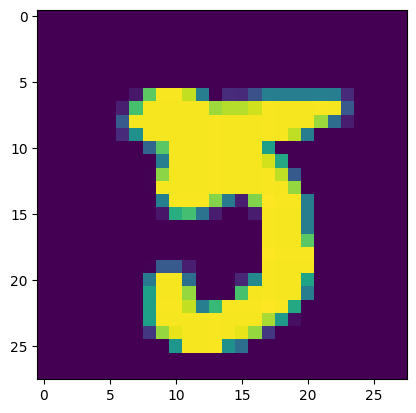


Label: [6] | Predicted: 0



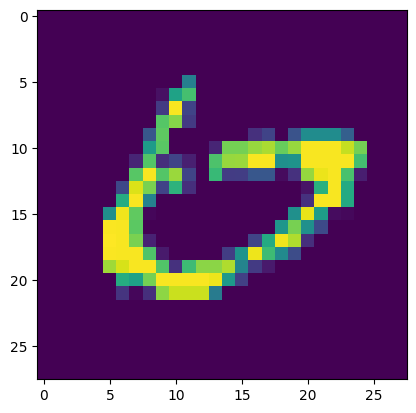


Label: [4] | Predicted: 9



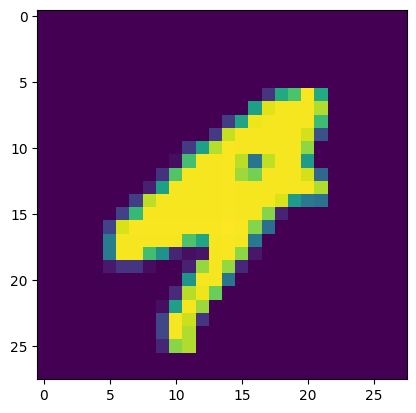


Label: [3] | Predicted: 5



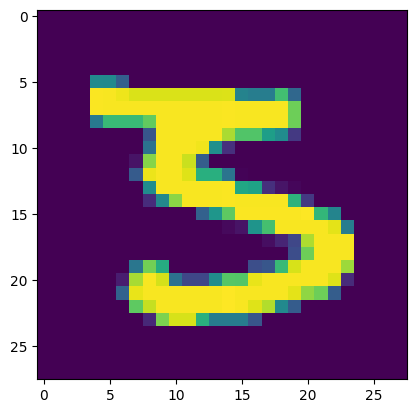


Label: [8] | Predicted: 2



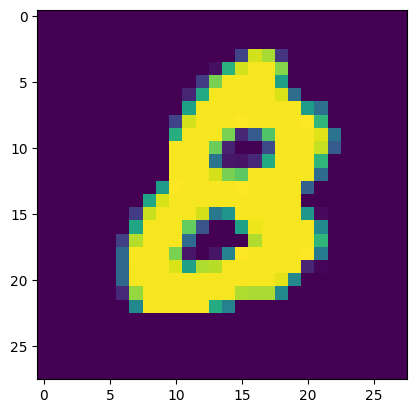


Label: [8] | Predicted: 2



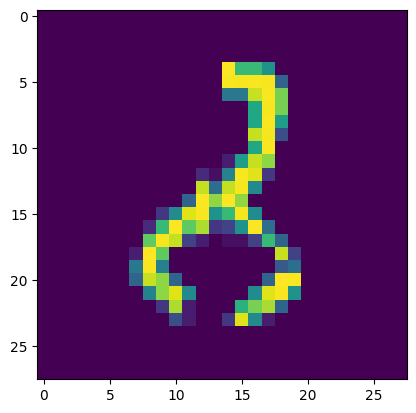


Label: [1] | Predicted: 8



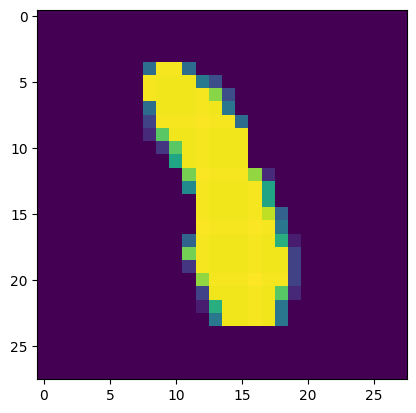


Label: [2] | Predicted: 6



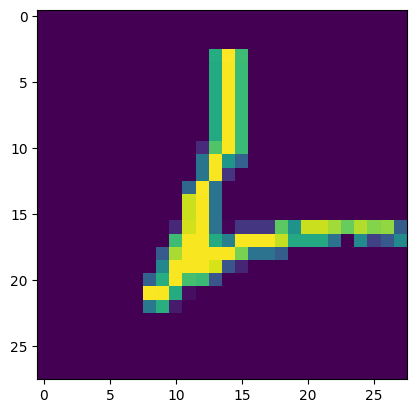


Label: [7] | Predicted: 3



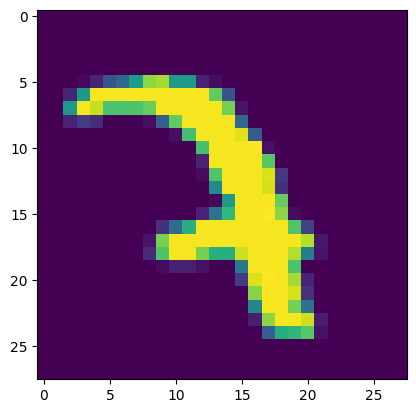


Label: [4] | Predicted: 9



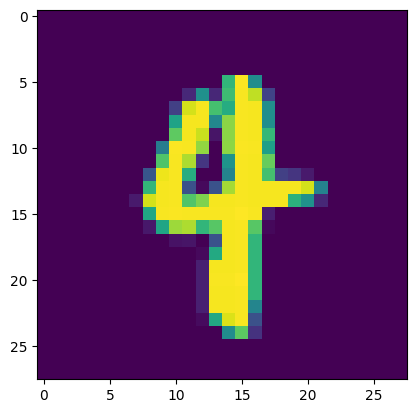


Label: [5] | Predicted: 8



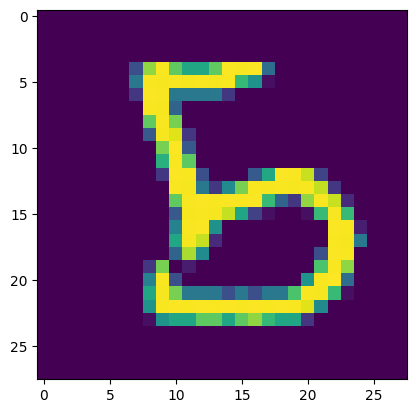


Label: [9] | Predicted: 7



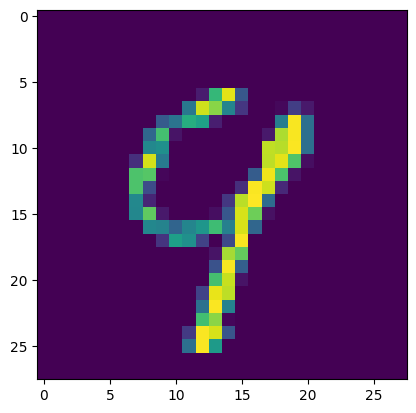


Label: [3] | Predicted: 8



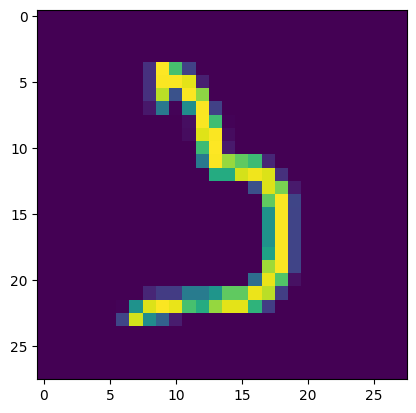


Label: [3] | Predicted: 5



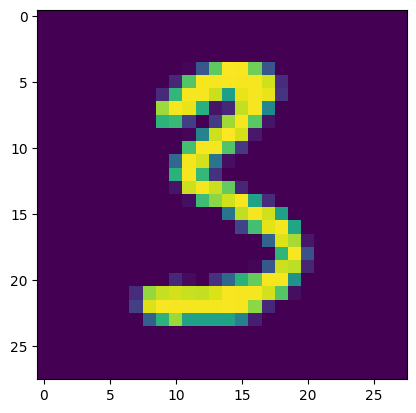


Label: [1] | Predicted: 5



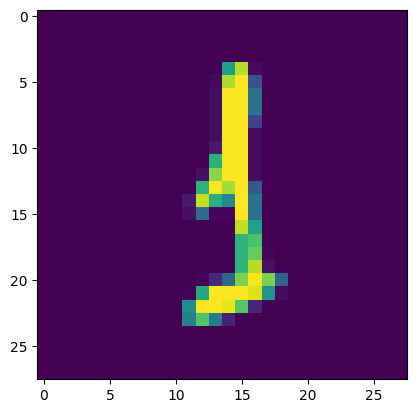


Label: [2] | Predicted: 0



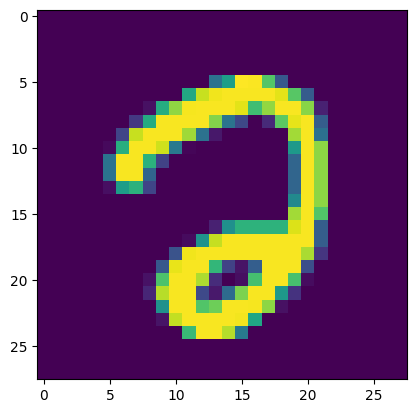


Label: [6] | Predicted: 0



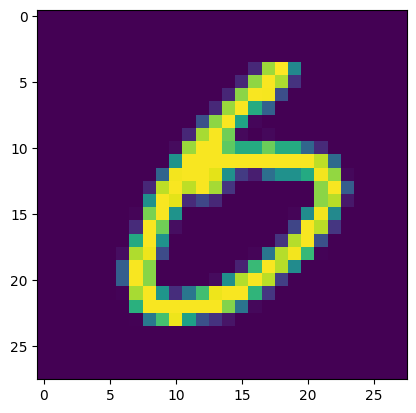


Label: [6] | Predicted: 5



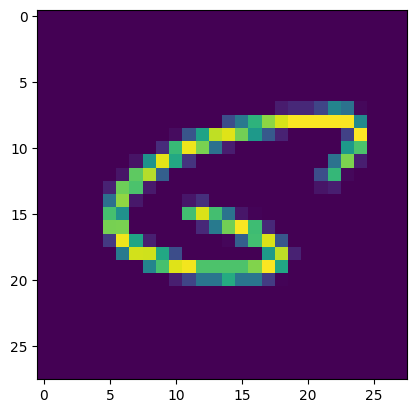


Label: [6] | Predicted: 8



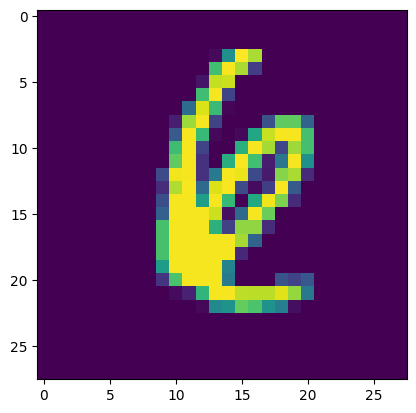


Label: [8] | Predicted: 3



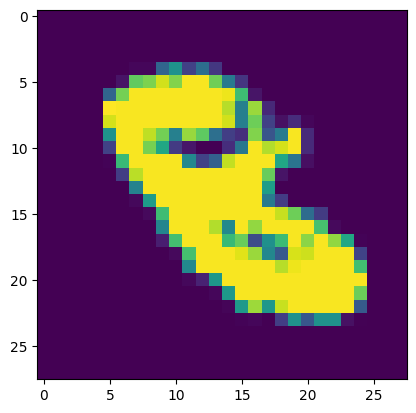


Label: [9] | Predicted: 8



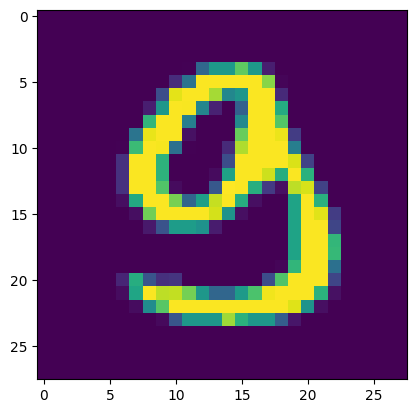


Label: [4] | Predicted: 6



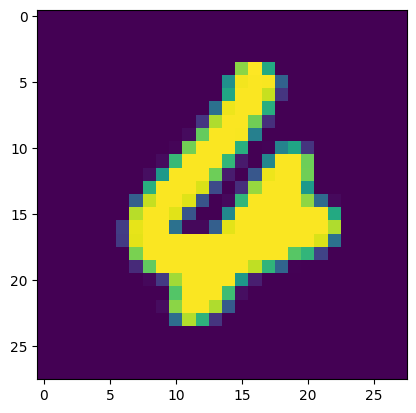


Label: [3] | Predicted: 7



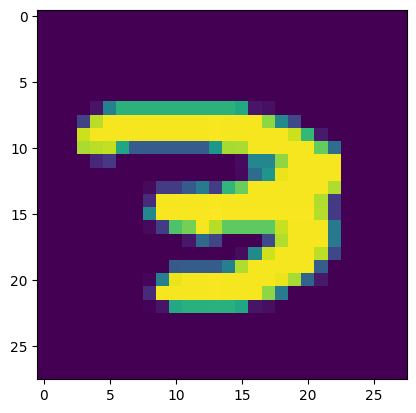


Label: [7] | Predicted: 5



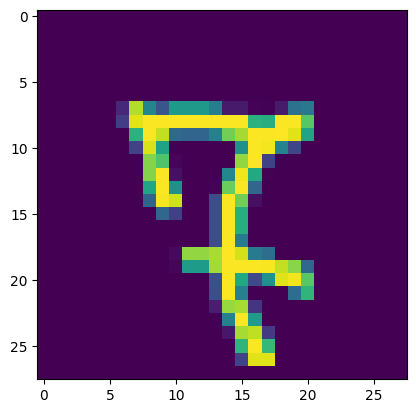


Label: [3] | Predicted: 5



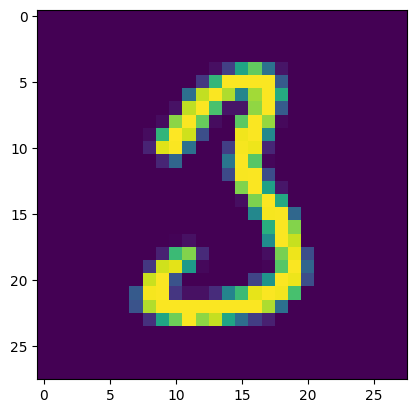


Label: [4] | Predicted: 0



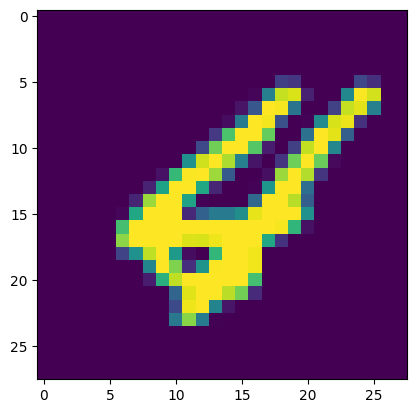


Label: [6] | Predicted: 1



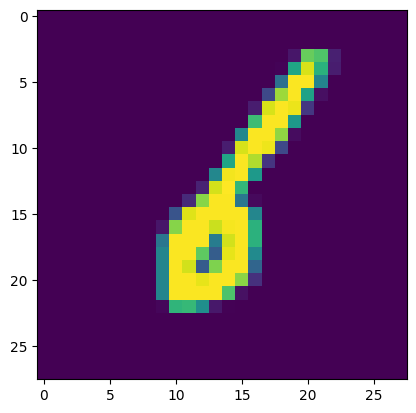


Label: [7] | Predicted: 2



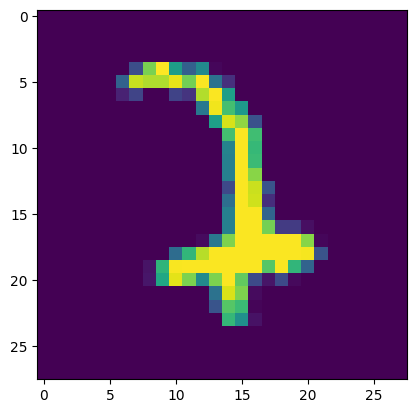


Label: [9] | Predicted: 6



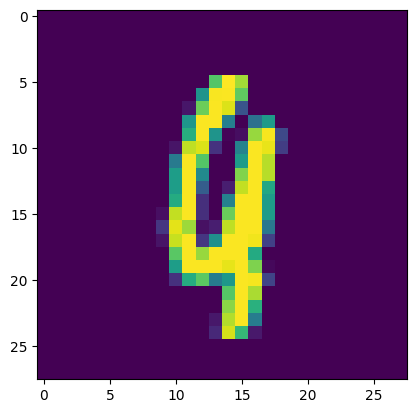


Label: [4] | Predicted: 9



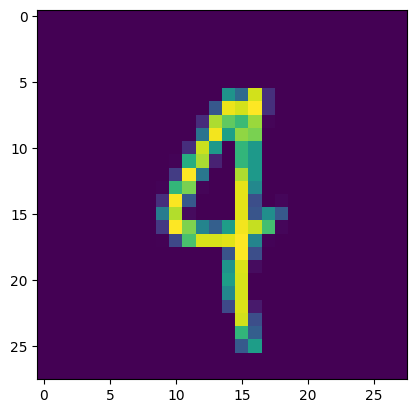


Label: [9] | Predicted: 7



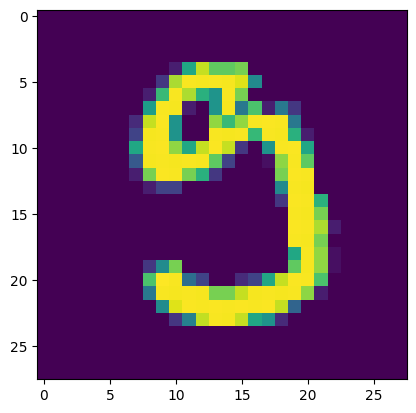


Label: [7] | Predicted: 2



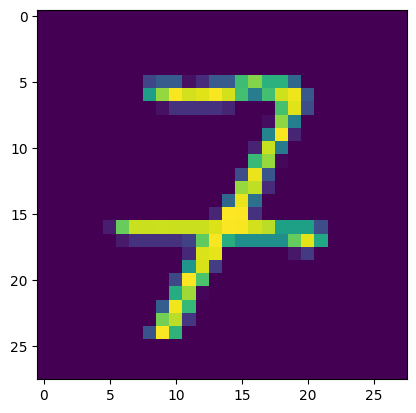


Label: [3] | Predicted: 5



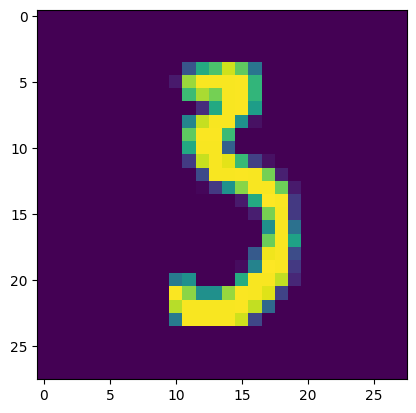


Label: [5] | Predicted: 7



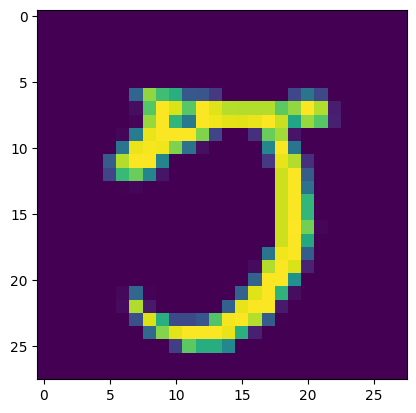


Label: [8] | Predicted: 3



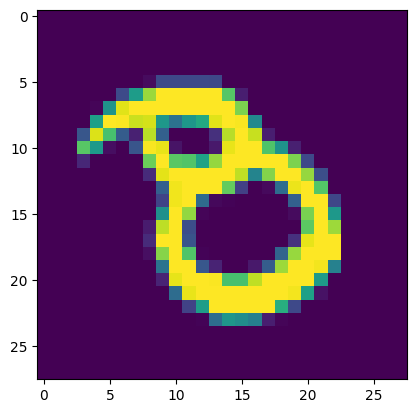


Label: [7] | Predicted: 8



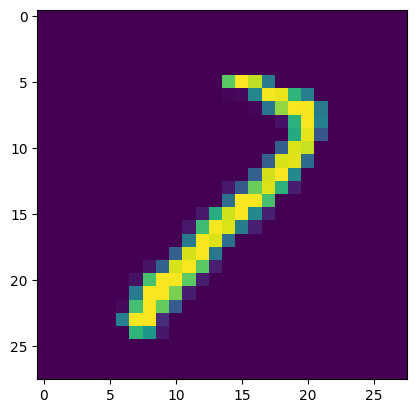


Label: [5] | Predicted: 3



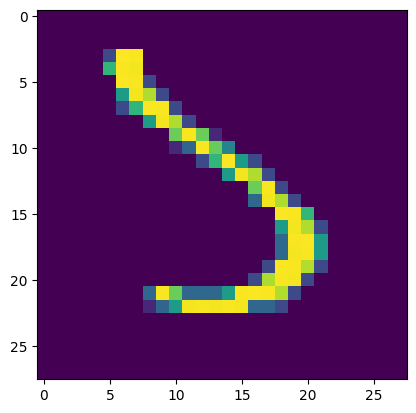


Label: [2] | Predicted: 3



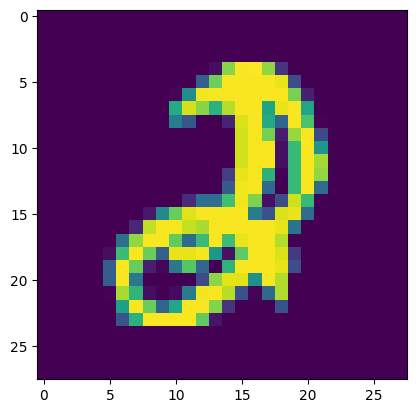


Label: [6] | Predicted: 9



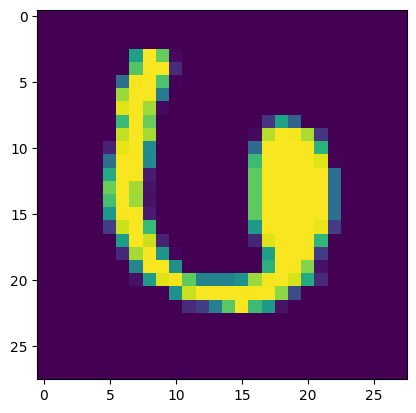


Label: [8] | Predicted: 3



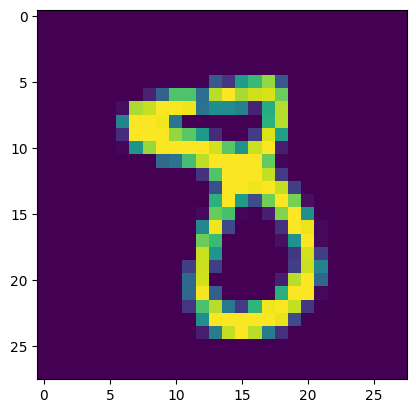


Label: [8] | Predicted: 7



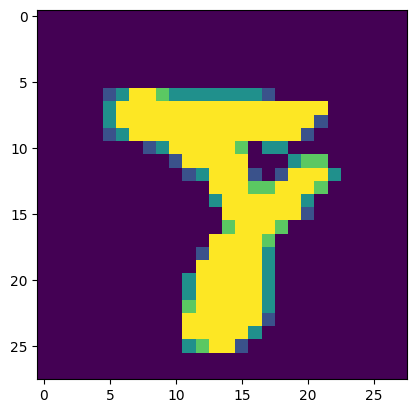


Label: [3] | Predicted: 5



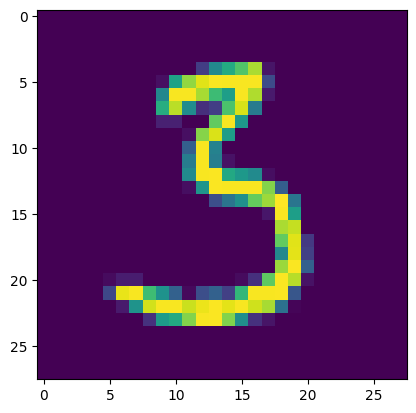


Label: [4] | Predicted: 6



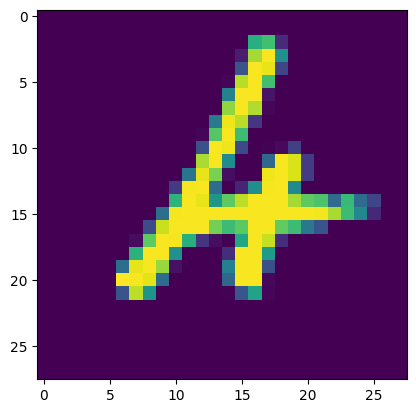


Label: [9] | Predicted: 3



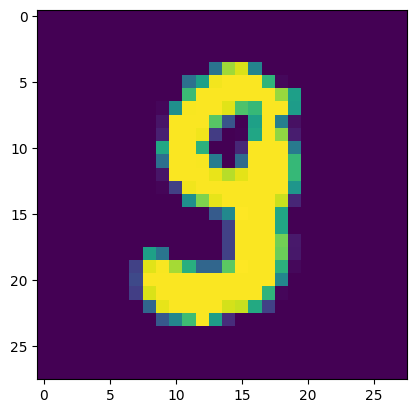


Label: [6] | Predicted: 4



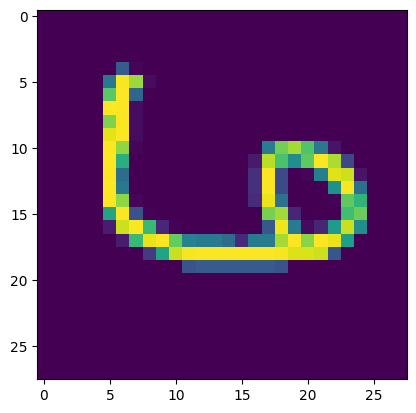


Label: [9] | Predicted: 7



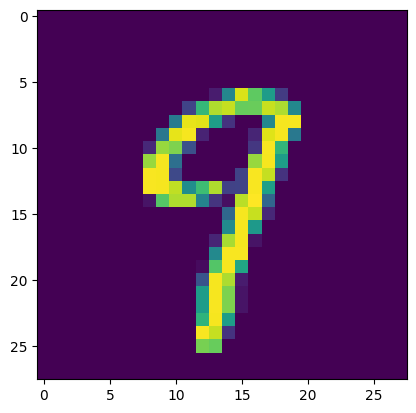


Label: [3] | Predicted: 7



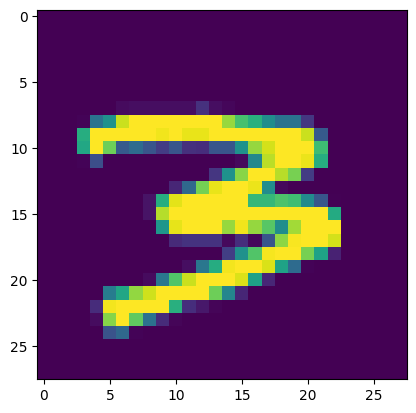


Label: [2] | Predicted: 0



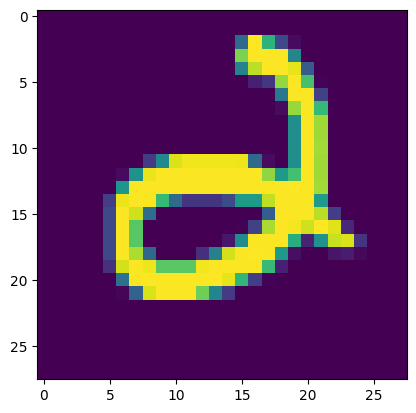


Label: [0] | Predicted: 6



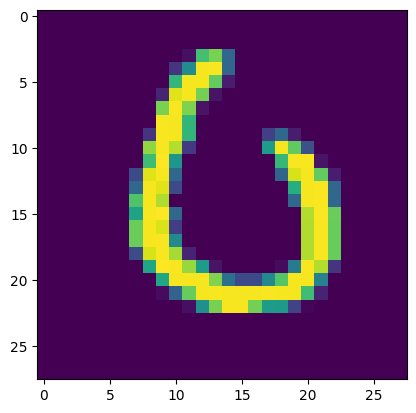


Label: [3] | Predicted: 7



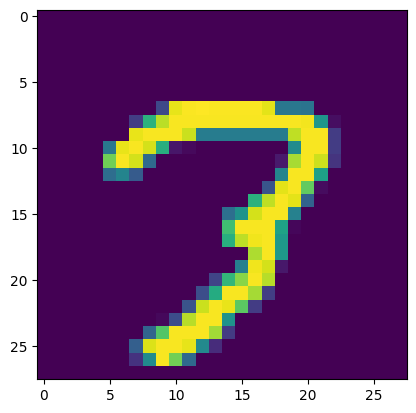


Label: [9] | Predicted: 3



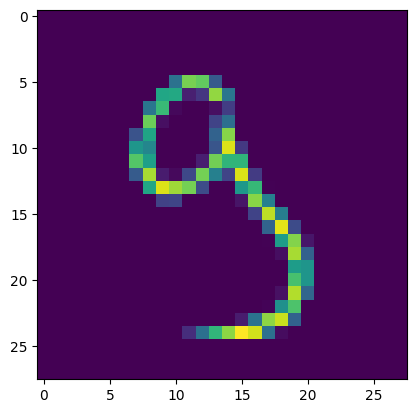


Label: [8] | Predicted: 0



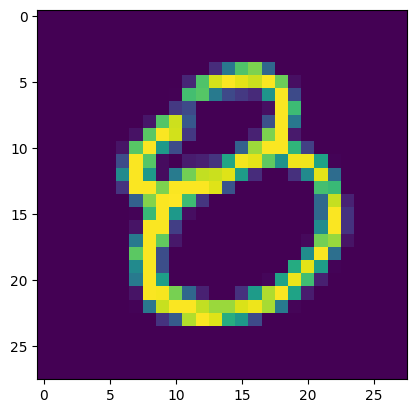


Label: [4] | Predicted: 2



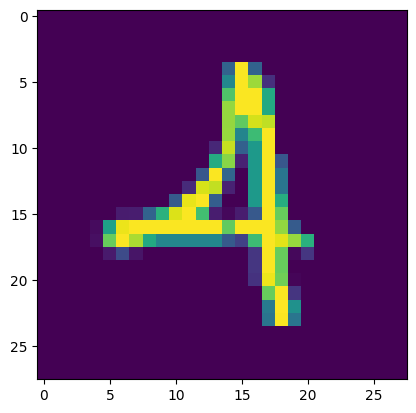


Label: [7] | Predicted: 1



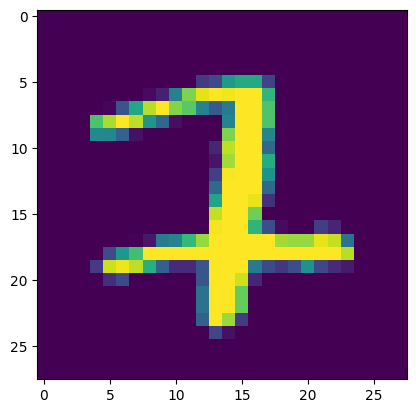


Label: [2] | Predicted: 8



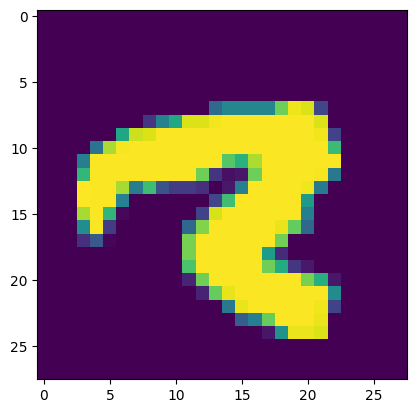


Label: [8] | Predicted: 2



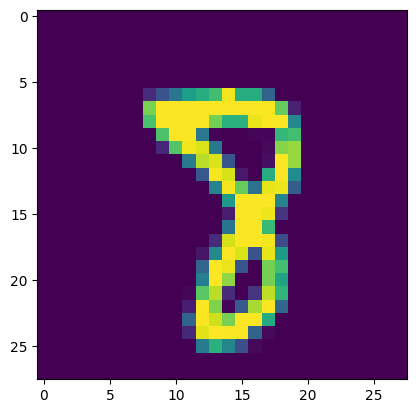


Label: [9] | Predicted: 4



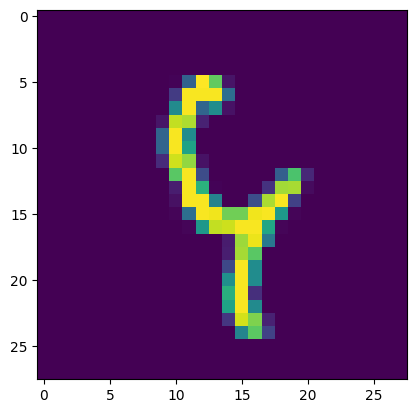


Label: [7] | Predicted: 3



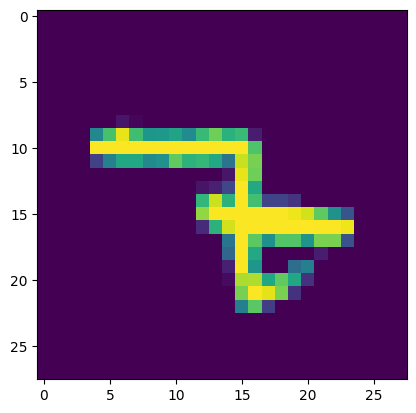


Label: [5] | Predicted: 0



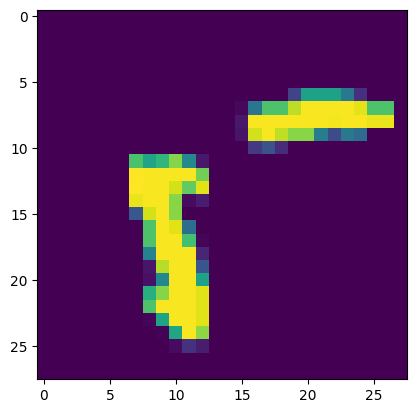


Label: [7] | Predicted: 8



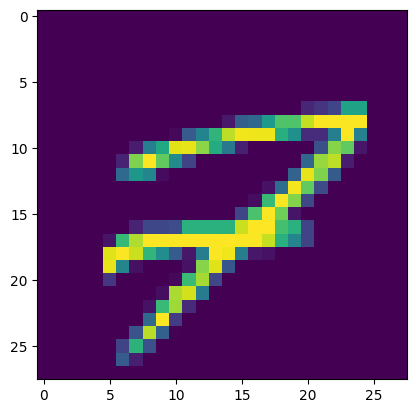


Label: [9] | Predicted: 3



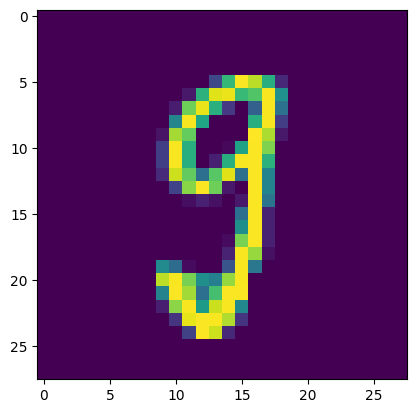


Label: [6] | Predicted: 5



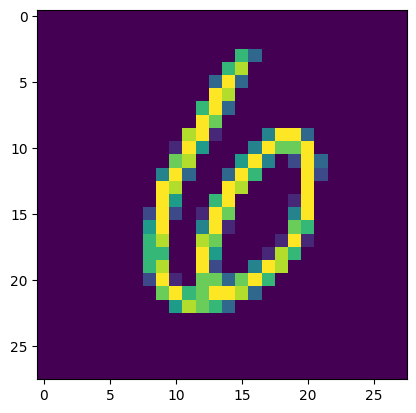


Label: [6] | Predicted: 5



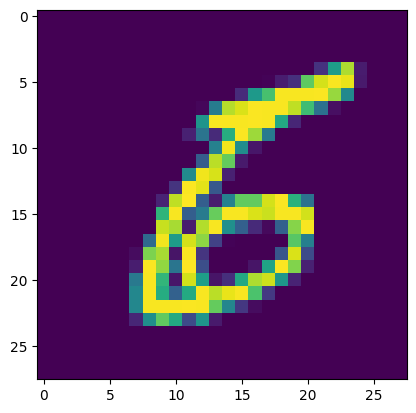


Label: [0] | Predicted: 9



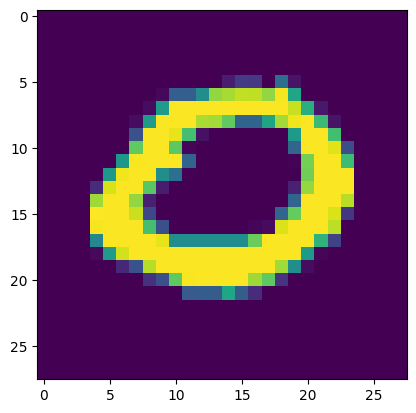


Label: [5] | Predicted: 6



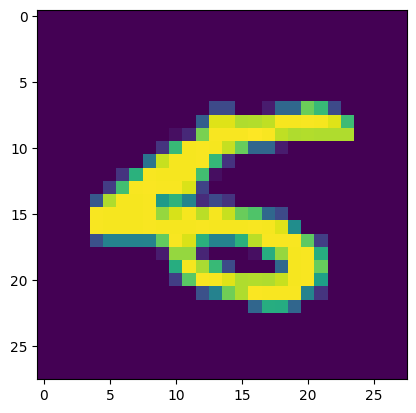


Label: [4] | Predicted: 9



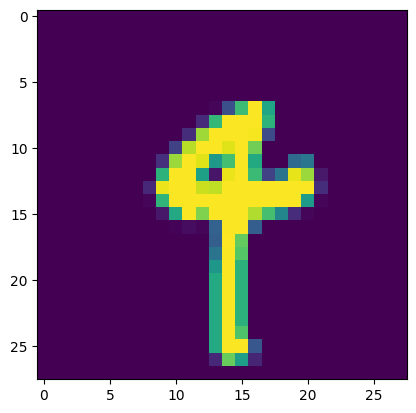


Label: [7] | Predicted: 9



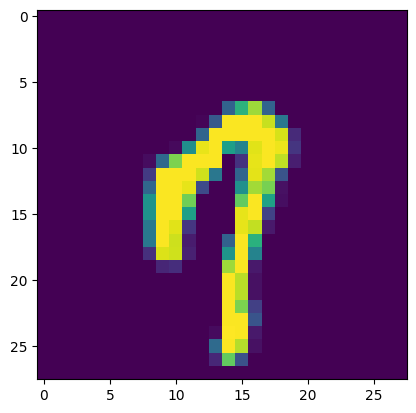


Label: [3] | Predicted: 7



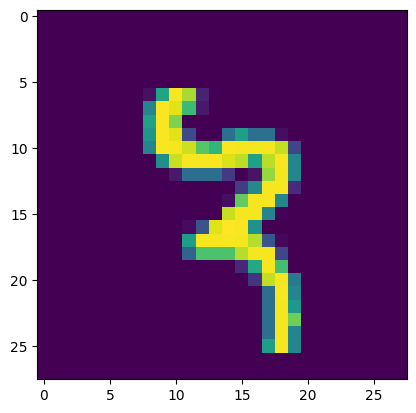


Label: [9] | Predicted: 2



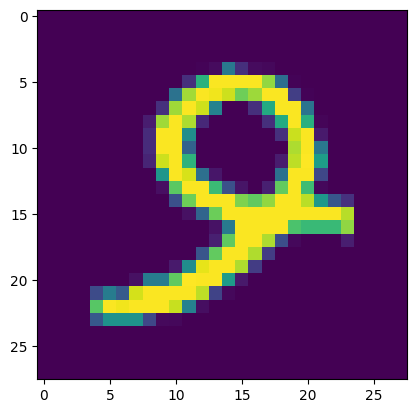


Label: [4] | Predicted: 9



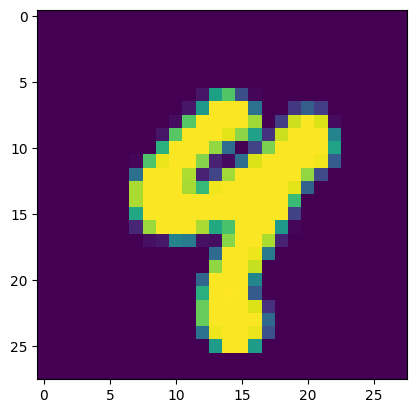


Label: [6] | Predicted: 1



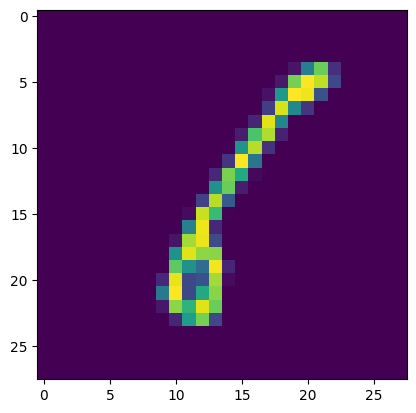


Label: [5] | Predicted: 8



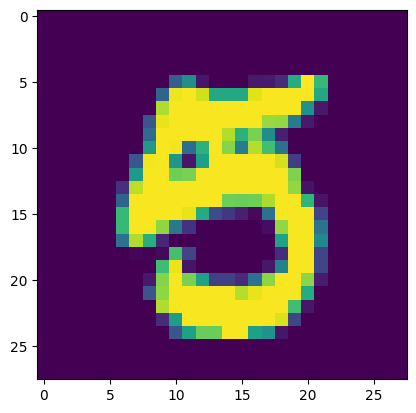


Label: [2] | Predicted: 3



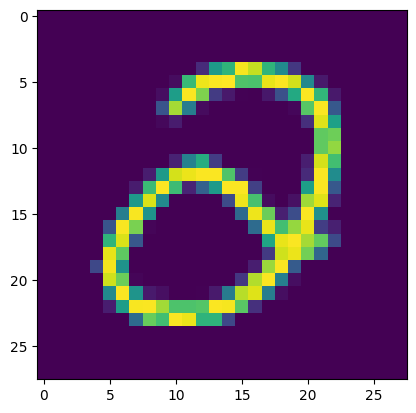


Label: [9] | Predicted: 8



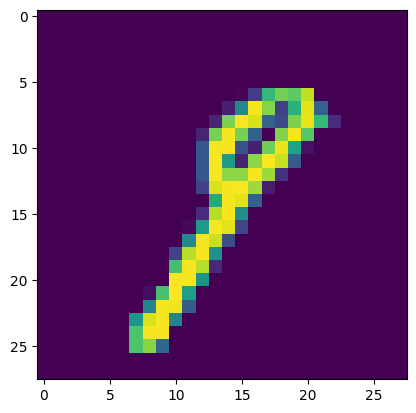


Label: [8] | Predicted: 0



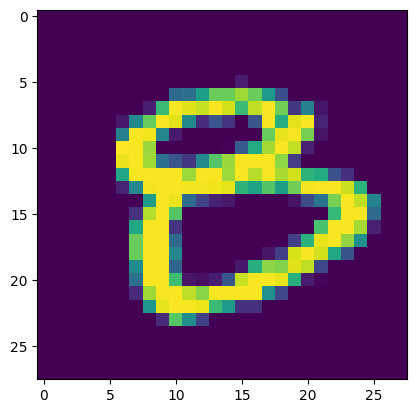


Label: [9] | Predicted: 6



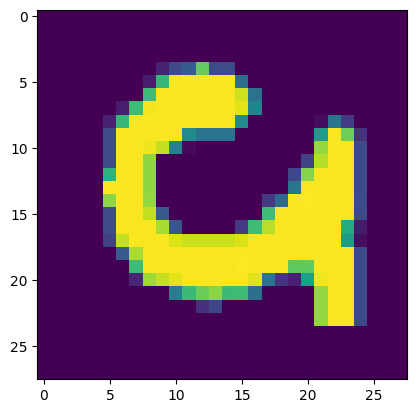


Label: [5] | Predicted: 9



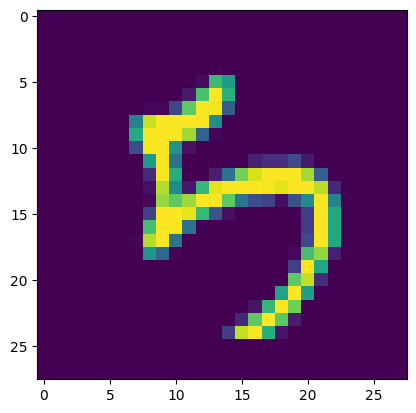


Label: [9] | Predicted: 1



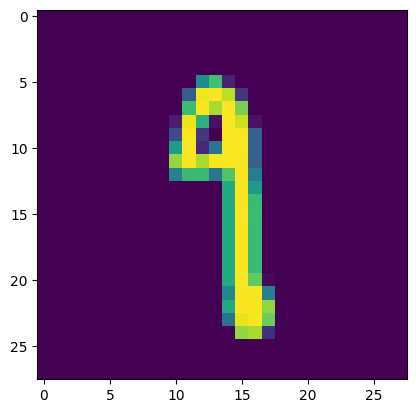


Label: [3] | Predicted: 2



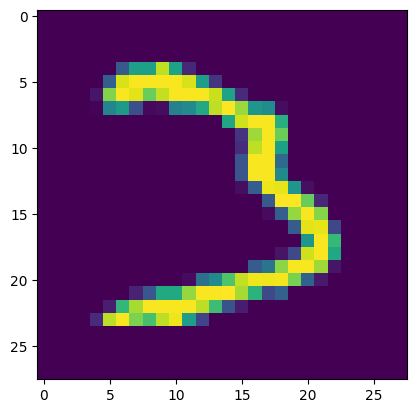


Label: [9] | Predicted: 4



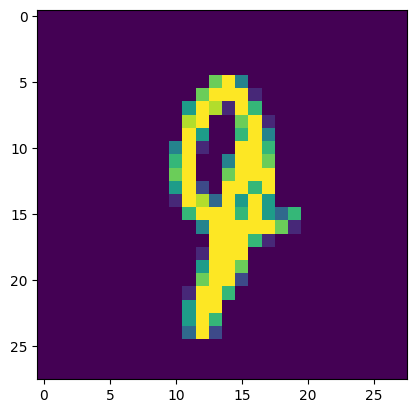


Label: [9] | Predicted: 7



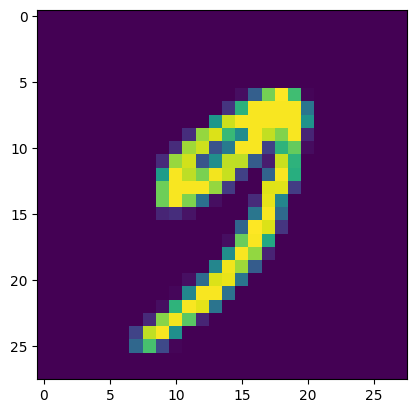


Label: [5] | Predicted: 3



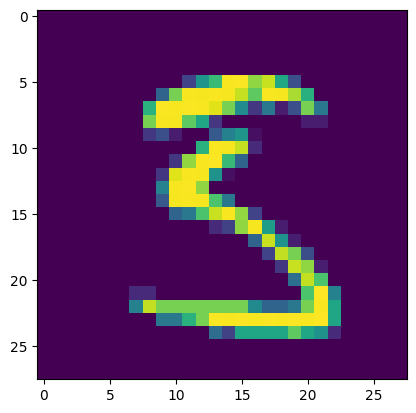


Label: [7] | Predicted: 1



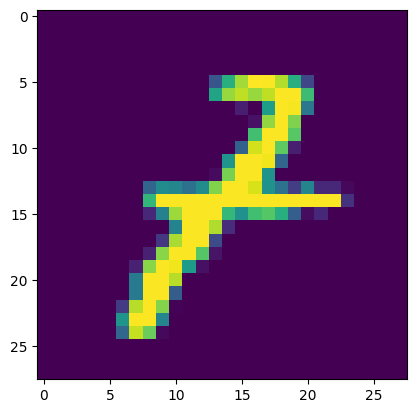


Label: [2] | Predicted: 8



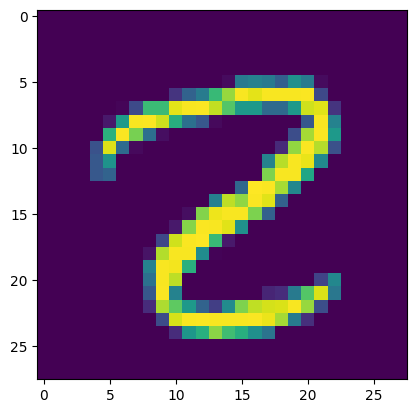


Label: [9] | Predicted: 0



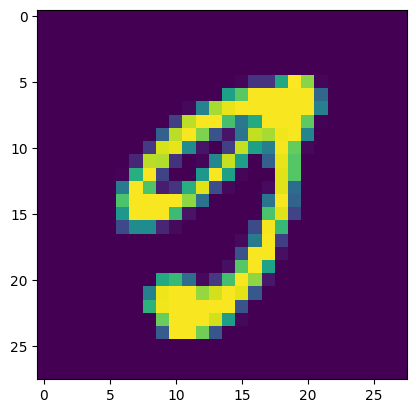


Label: [6] | Predicted: 1



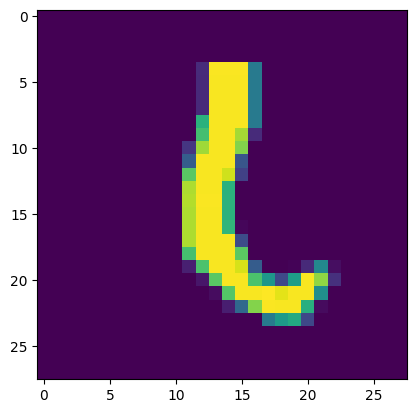


Label: [9] | Predicted: 7



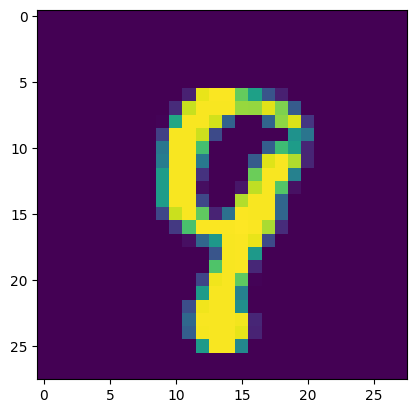


Label: [4] | Predicted: 7



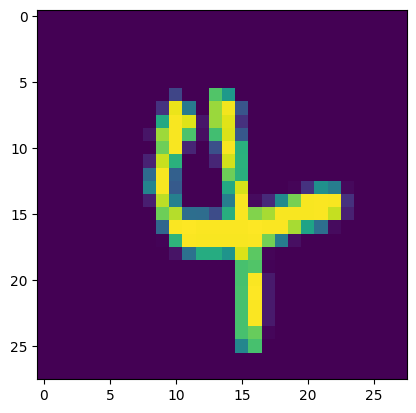


Label: [8] | Predicted: 0



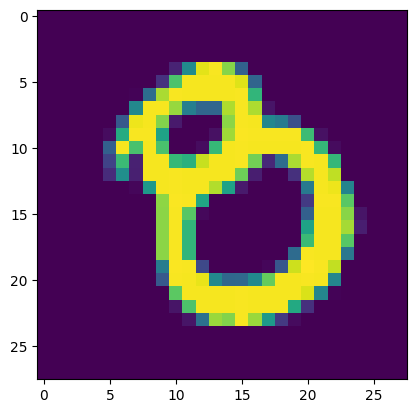


Label: [7] | Predicted: 3



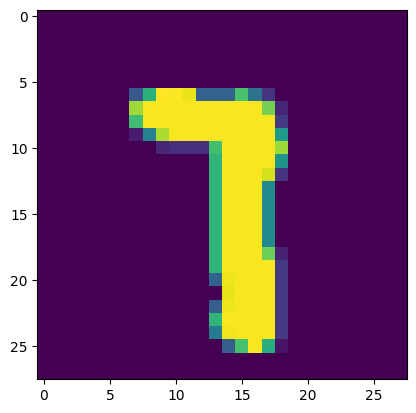


Label: [3] | Predicted: 2



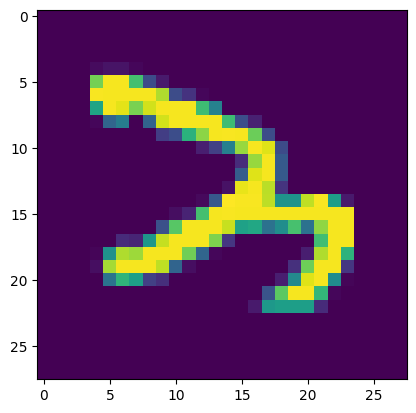


Label: [9] | Predicted: 5



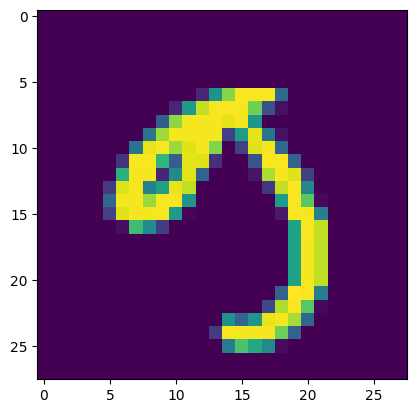


Label: [3] | Predicted: 7



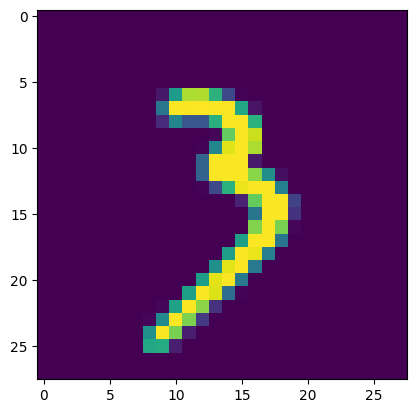


Label: [9] | Predicted: 7



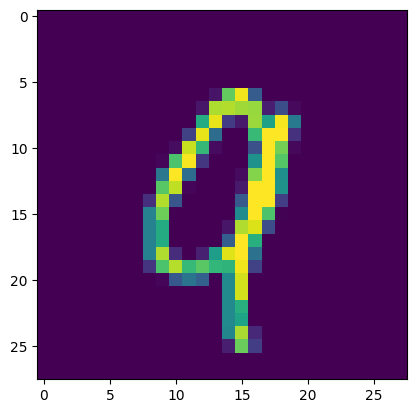


Label: [6] | Predicted: 2



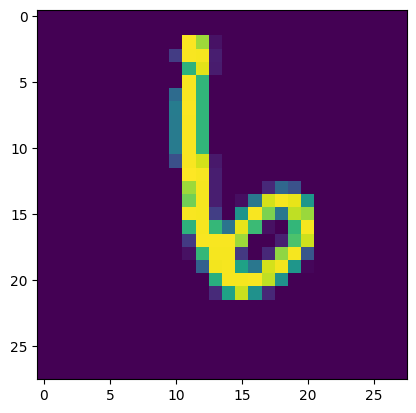


Label: [6] | Predicted: 5



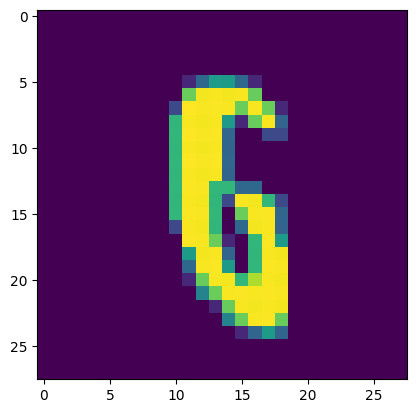


Label: [9] | Predicted: 8



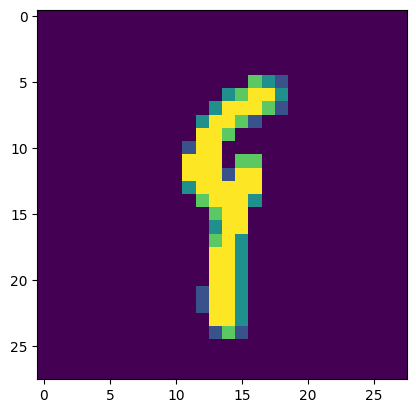


Label: [6] | Predicted: 5



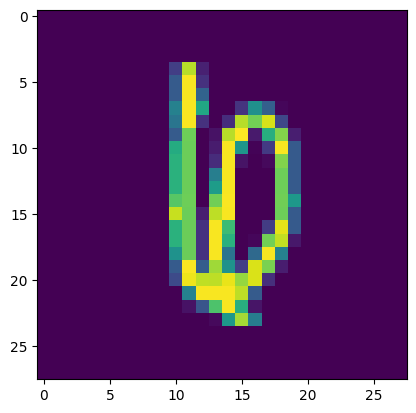


Label: [1] | Predicted: 3



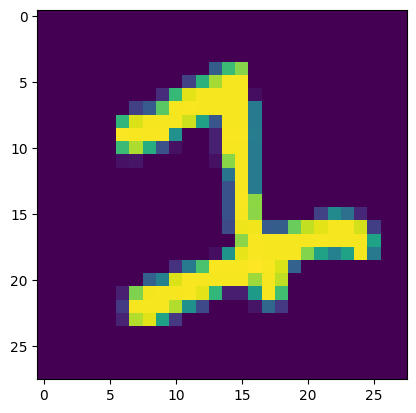


Label: [5] | Predicted: 9



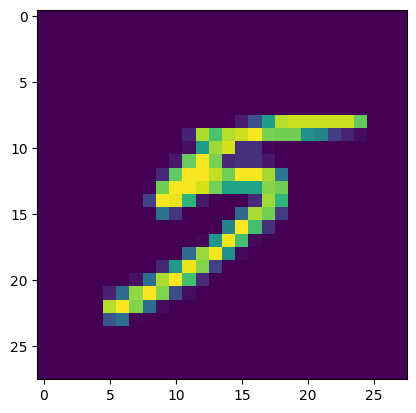


Label: [5] | Predicted: 9



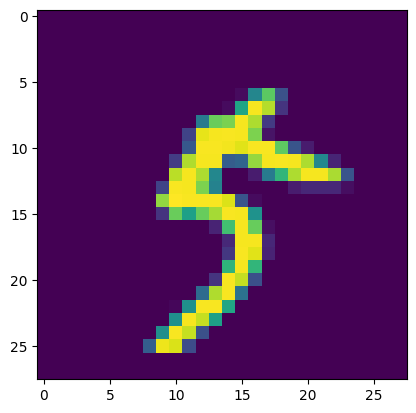


Label: [7] | Predicted: 6



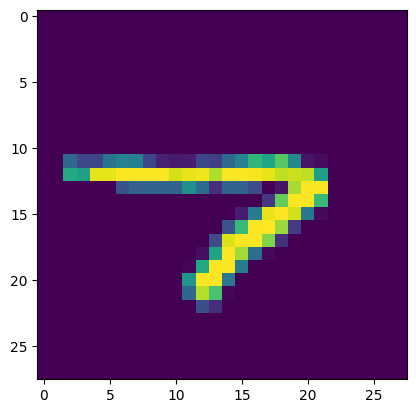


Label: [7] | Predicted: 9



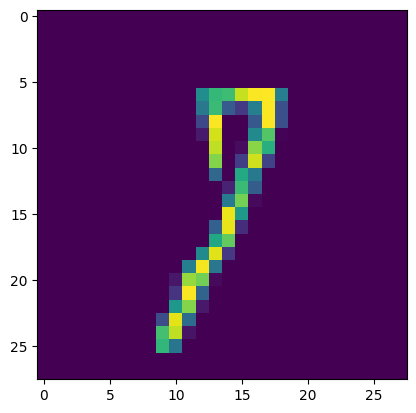


Label: [8] | Predicted: 3



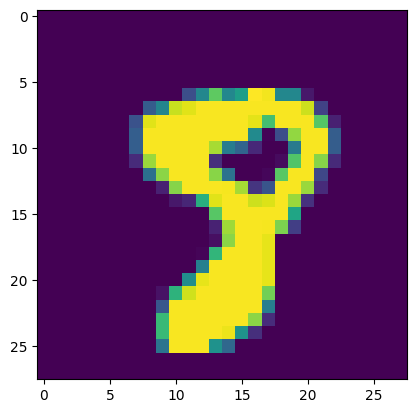


Label: [2] | Predicted: 6



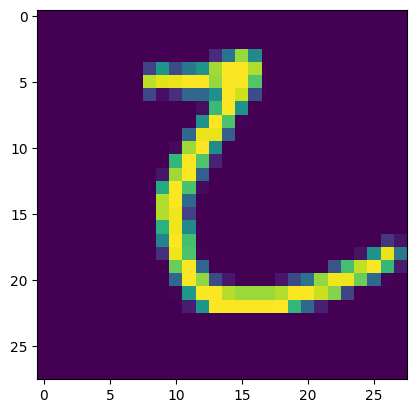


Label: [4] | Predicted: 9



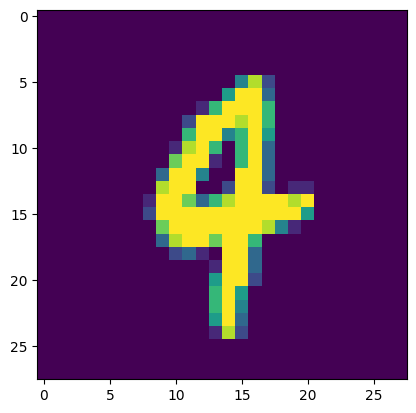


Label: [6] | Predicted: 0



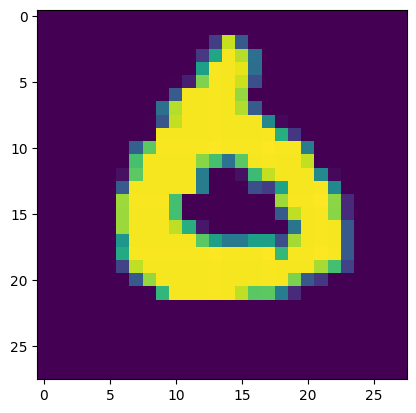


Label: [2] | Predicted: 1



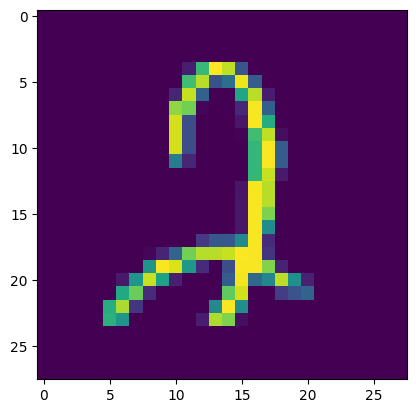


Label: [9] | Predicted: 1



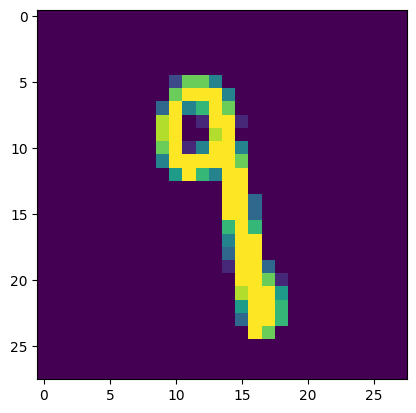


Label: [6] | Predicted: 4



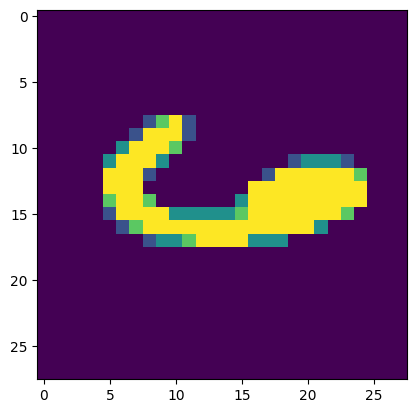


Label: [4] | Predicted: 9



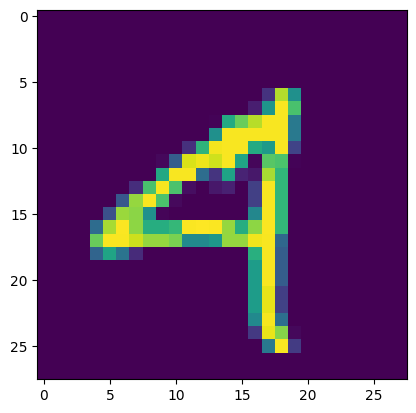


Label: [3] | Predicted: 2



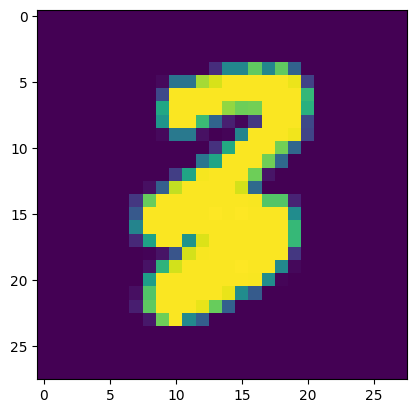


Label: [5] | Predicted: 0



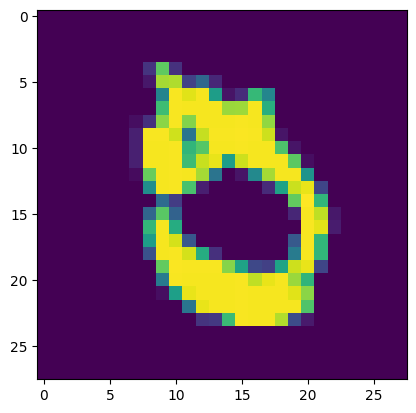


Label: [8] | Predicted: 5



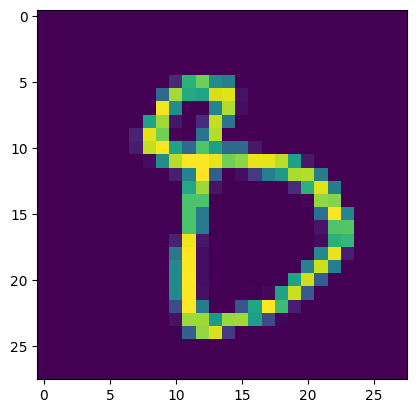


Label: [9] | Predicted: 8



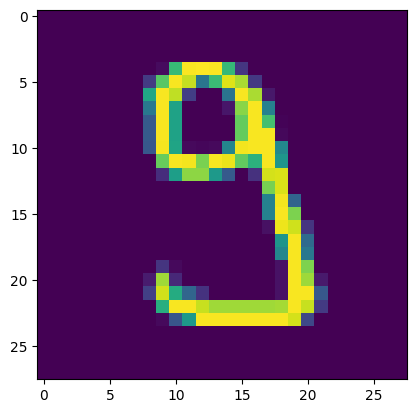


Label: [2] | Predicted: 3



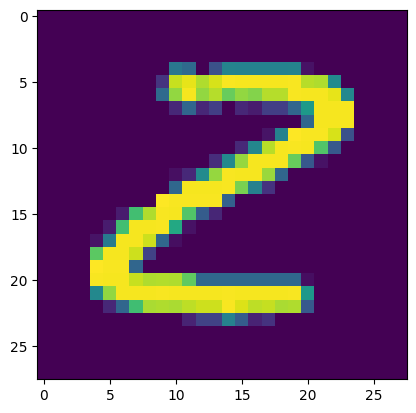


Label: [8] | Predicted: 4



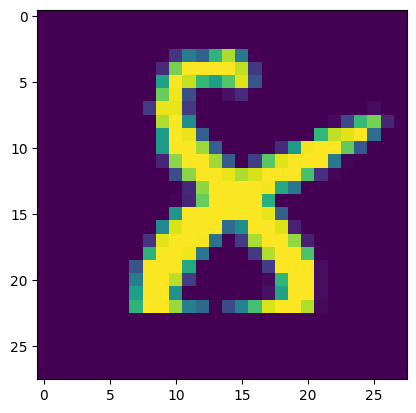


Label: [8] | Predicted: 9



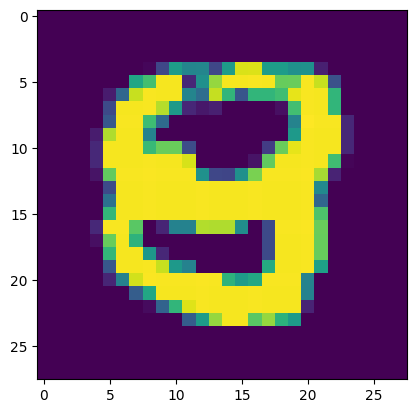


Label: [6] | Predicted: 9



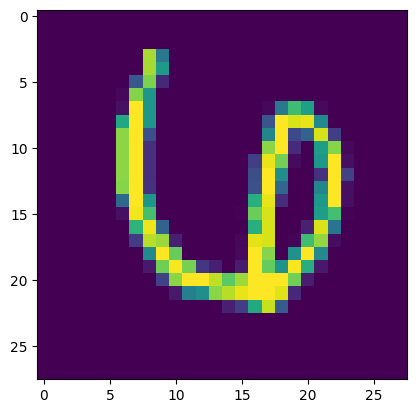


Label: [7] | Predicted: 2



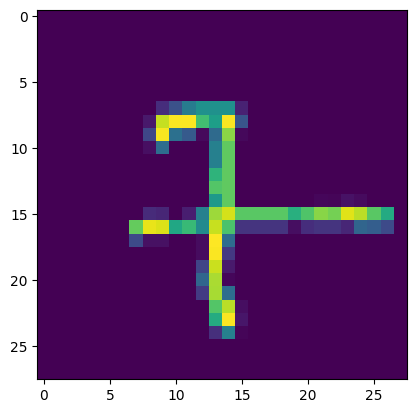


Label: [8] | Predicted: 3



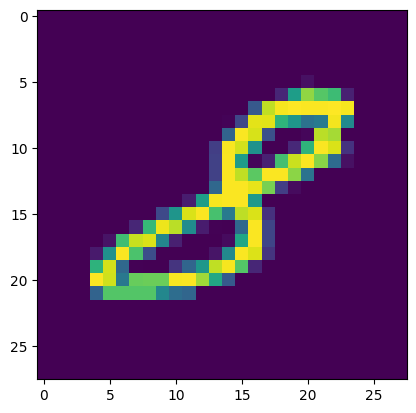


Label: [5] | Predicted: 8



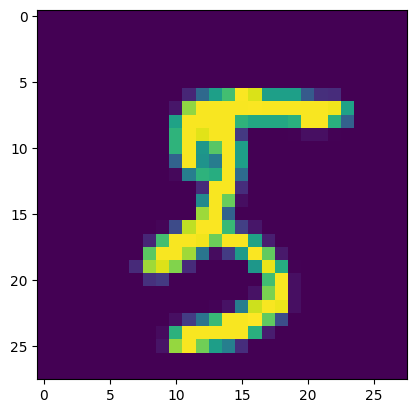


Label: [4] | Predicted: 6



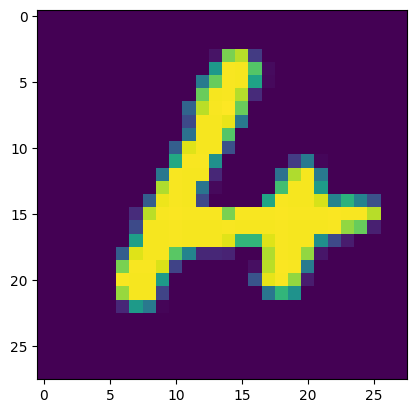


Label: [7] | Predicted: 3



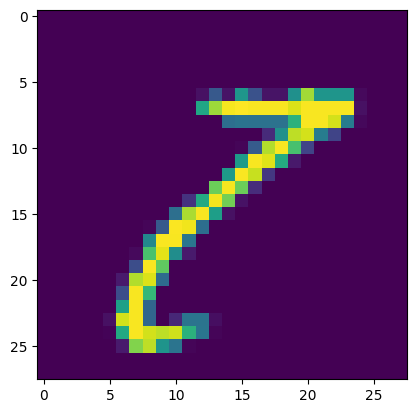


Label: [5] | Predicted: 6



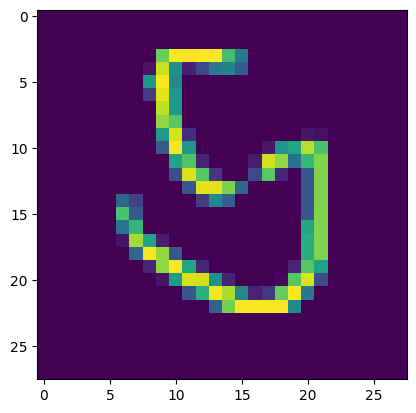


Label: [1] | Predicted: 2



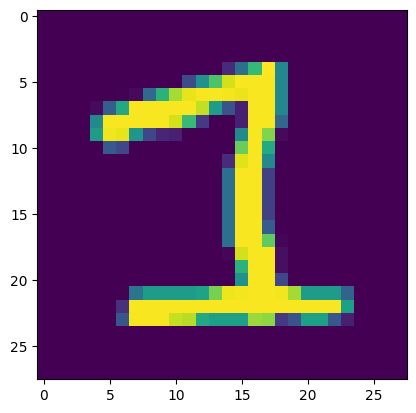


Label: [4] | Predicted: 6



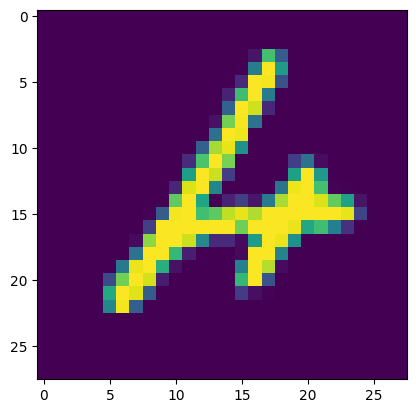


Label: [3] | Predicted: 5



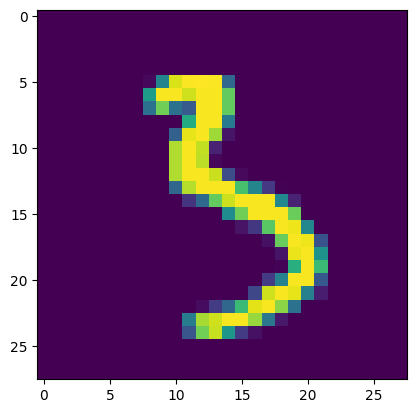


Label: [0] | Predicted: 8



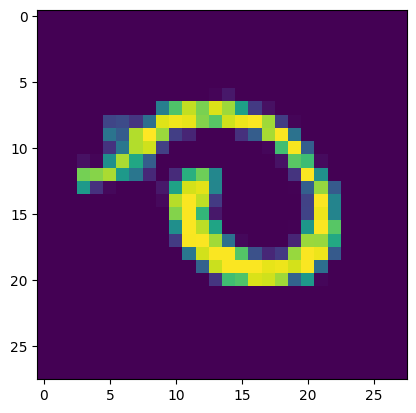


Label: [9] | Predicted: 3



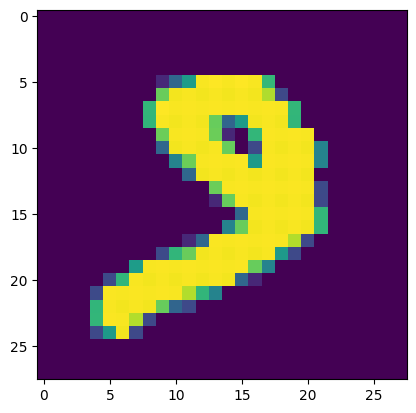


Label: [8] | Predicted: 6



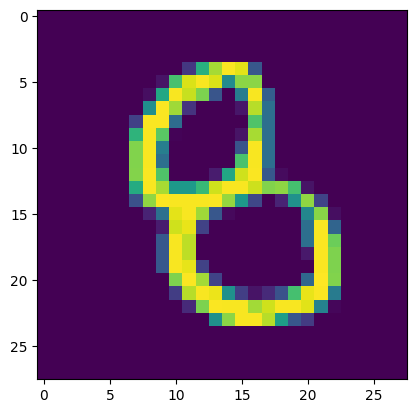


Label: [2] | Predicted: 1



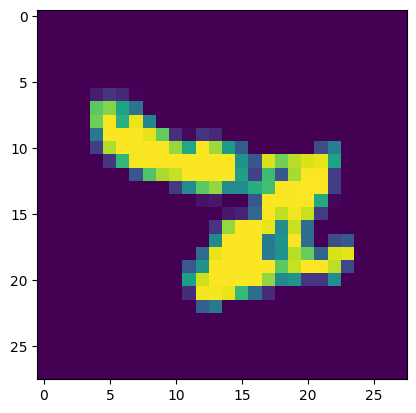


Label: [7] | Predicted: 9



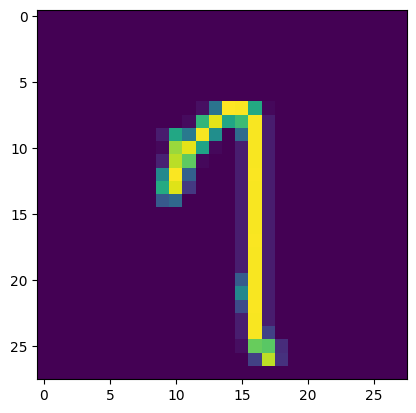


Label: [1] | Predicted: 7



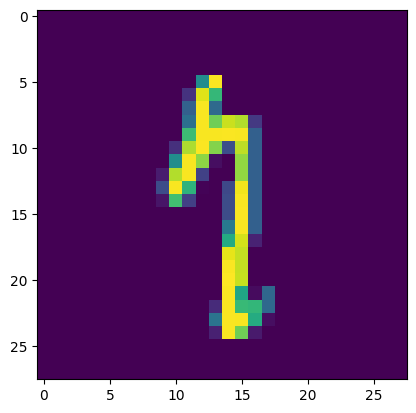


Label: [2] | Predicted: 6



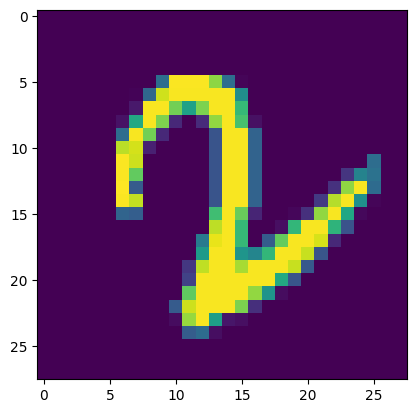


Label: [2] | Predicted: 8



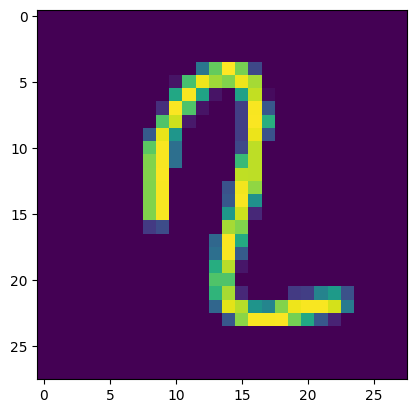


Label: [5] | Predicted: 3



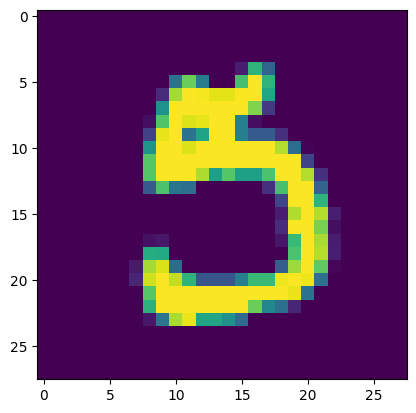


Label: [3] | Predicted: 2



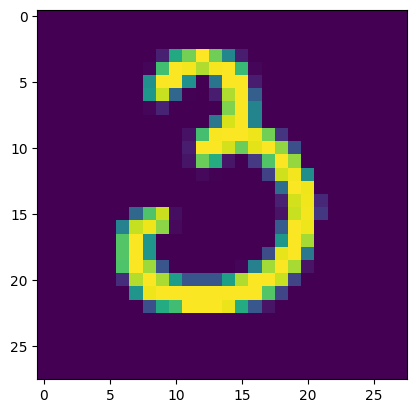


Label: [9] | Predicted: 7



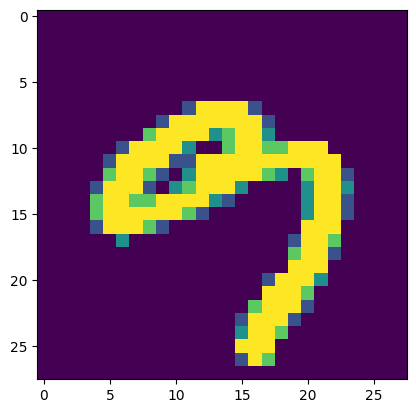


Label: [3] | Predicted: 7



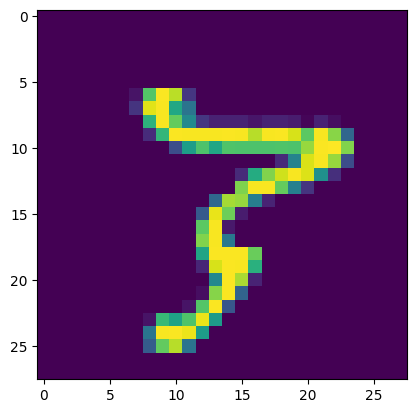


Label: [9] | Predicted: 7



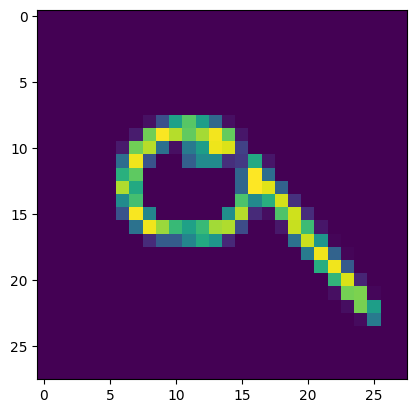


Label: [9] | Predicted: 5



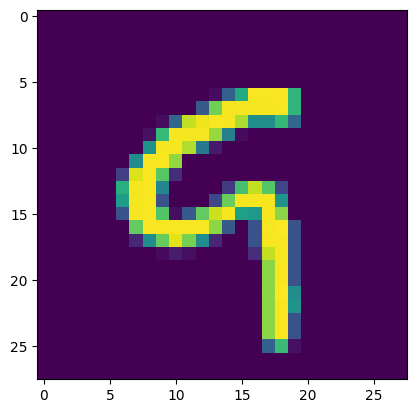


Label: [7] | Predicted: 9



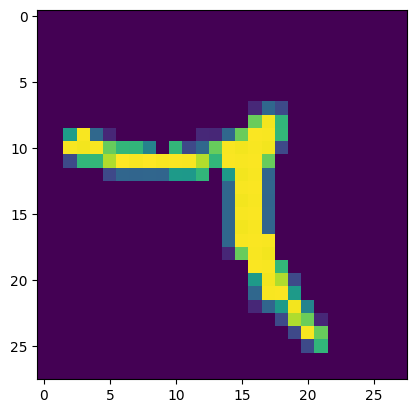


Label: [9] | Predicted: 4



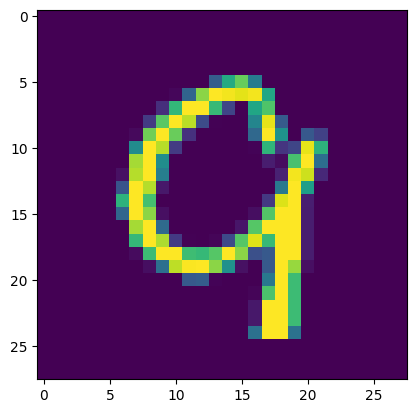


Label: [8] | Predicted: 7



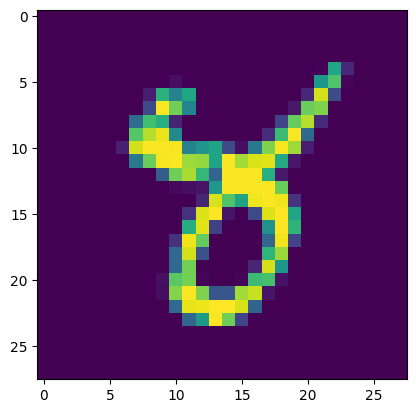


Label: [7] | Predicted: 2



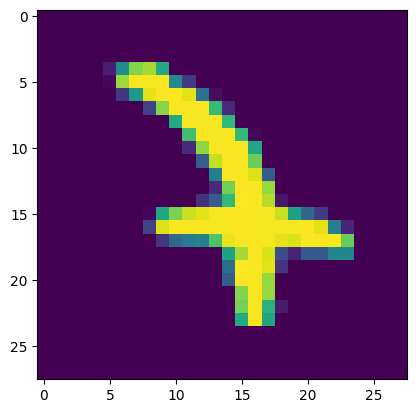


Label: [6] | Predicted: 0



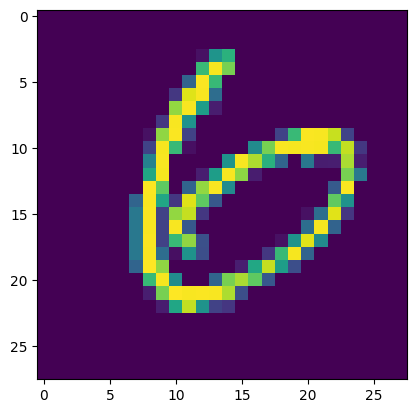


Label: [8] | Predicted: 7



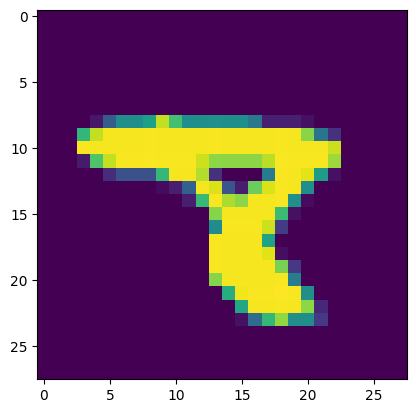


Label: [9] | Predicted: 1



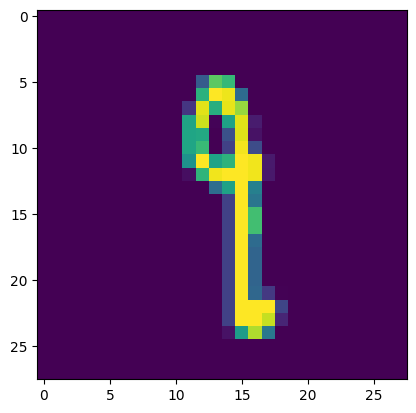


Label: [2] | Predicted: 7



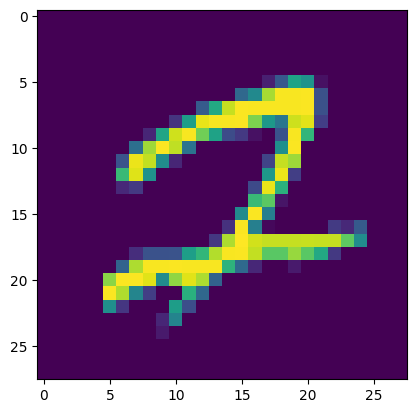


Label: [9] | Predicted: 5



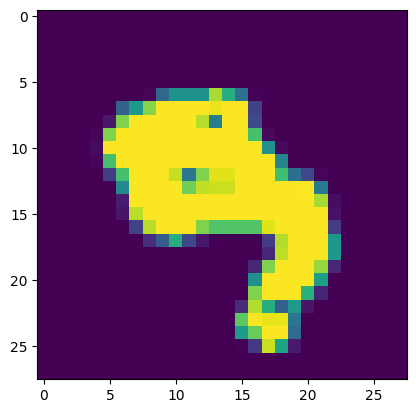


Label: [9] | Predicted: 7



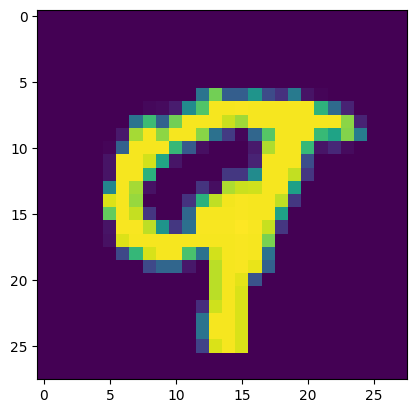


Label: [6] | Predicted: 5



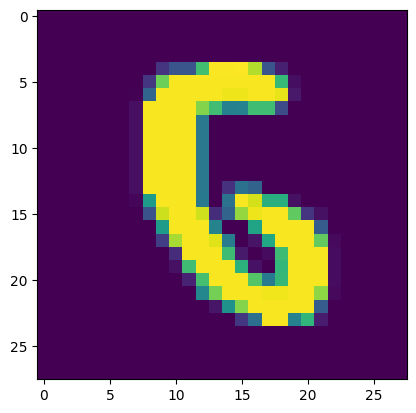


Label: [7] | Predicted: 4



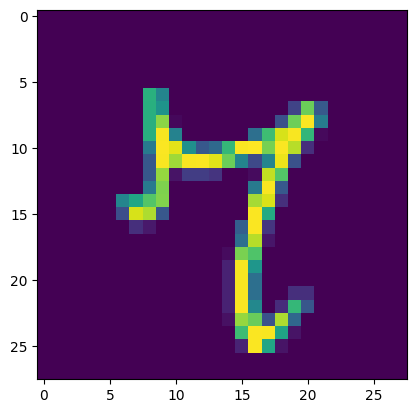


Label: [3] | Predicted: 9



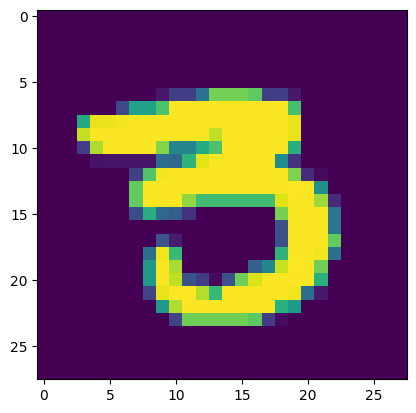


Label: [4] | Predicted: 9



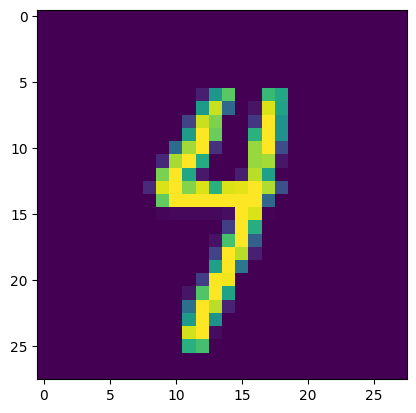


Label: [4] | Predicted: 9



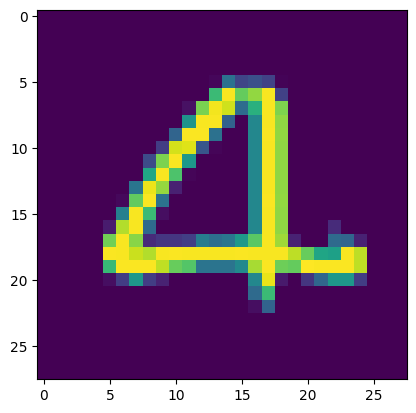


Label: [3] | Predicted: 5



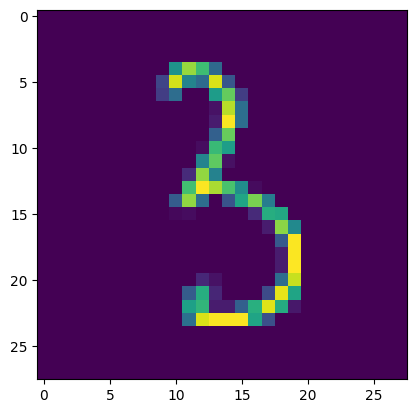


Label: [8] | Predicted: 9



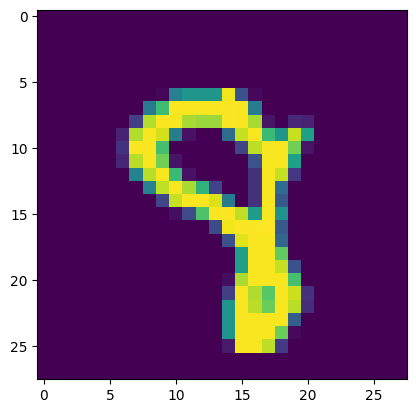


Label: [8] | Predicted: 3



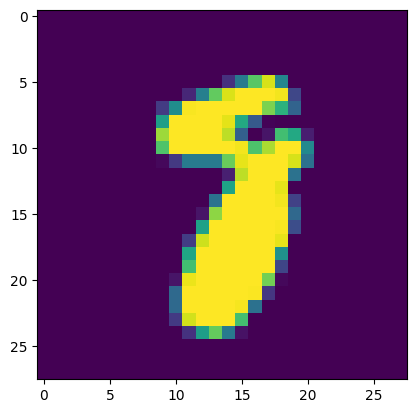


Label: [9] | Predicted: 7



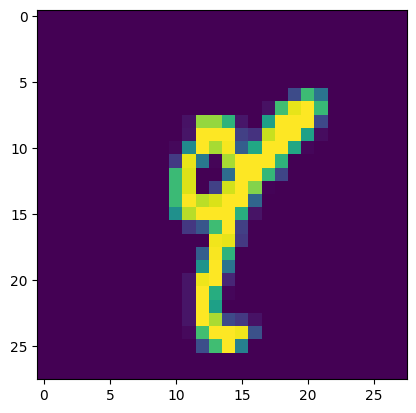


Label: [8] | Predicted: 3



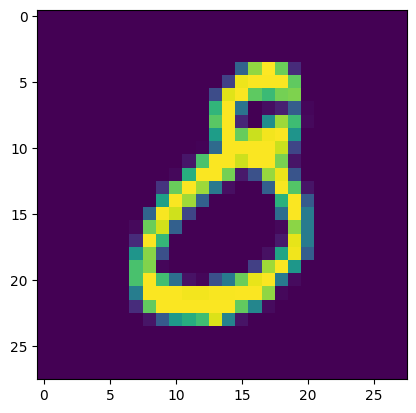


Label: [9] | Predicted: 6



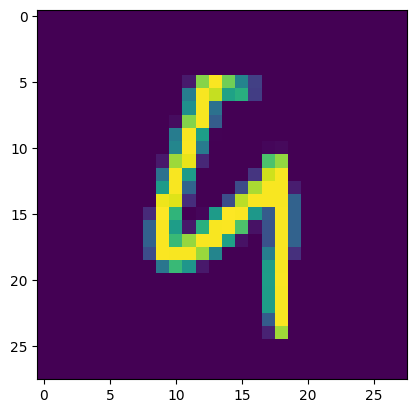


Label: [4] | Predicted: 9



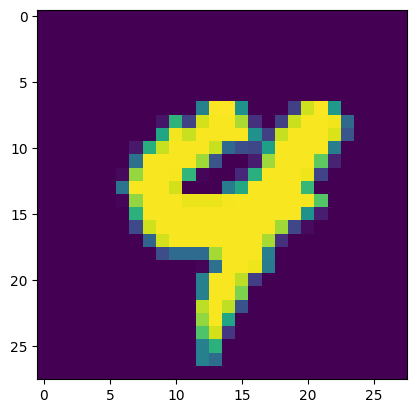


Label: [9] | Predicted: 0



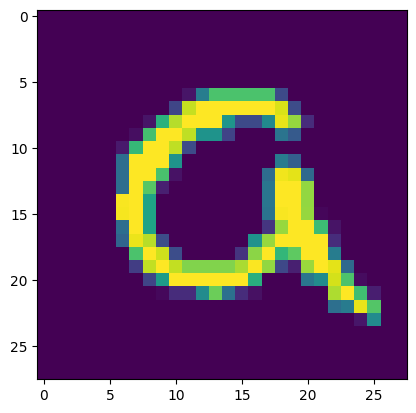


Label: [0] | Predicted: 8



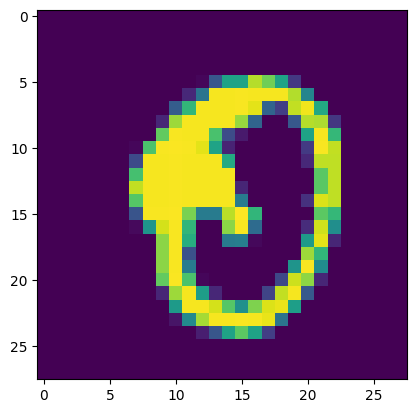


Label: [7] | Predicted: 9



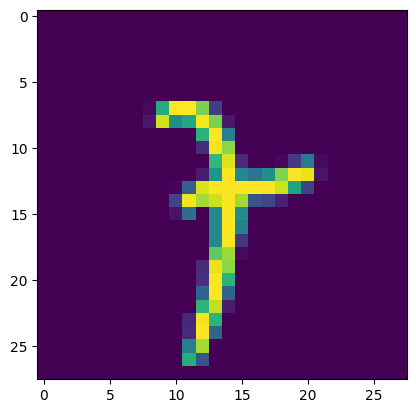


Label: [4] | Predicted: 7



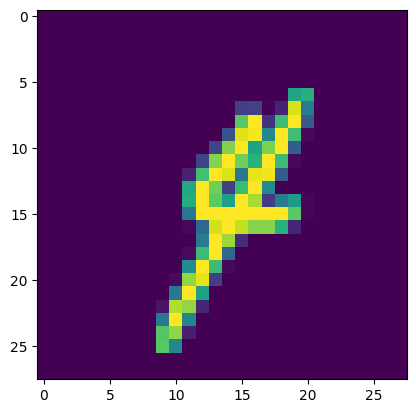


Label: [8] | Predicted: 5



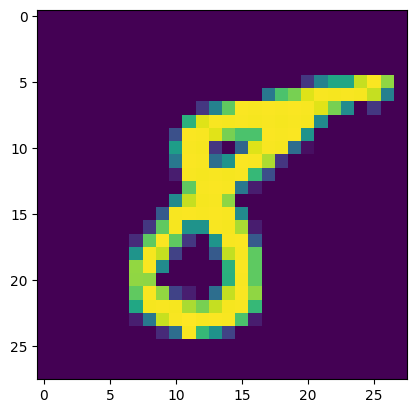


Label: [1] | Predicted: 6



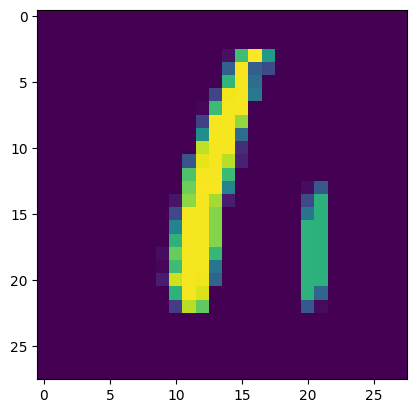


Label: [1] | Predicted: 8



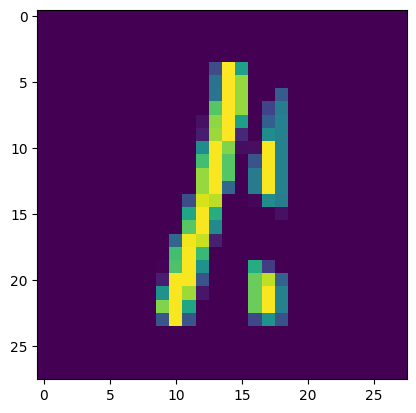


Label: [2] | Predicted: 3



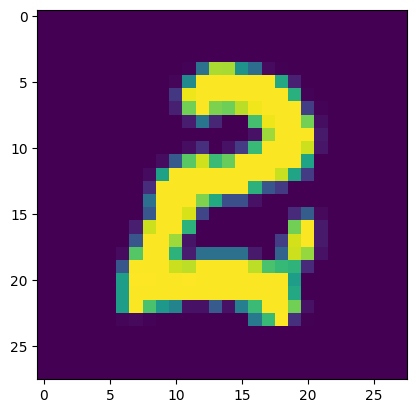


Label: [1] | Predicted: 5



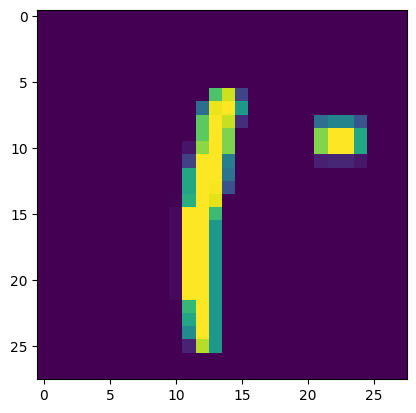


Label: [4] | Predicted: 3



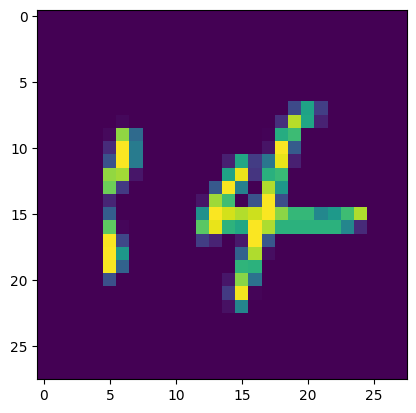


Label: [3] | Predicted: 9



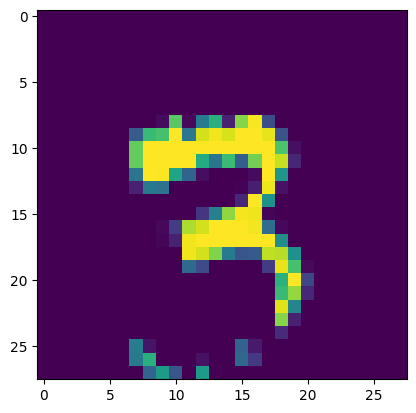


Label: [6] | Predicted: 5



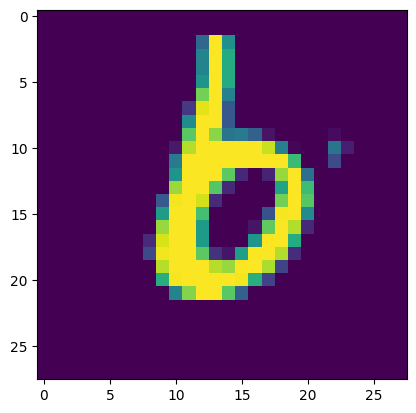


Label: [7] | Predicted: 0



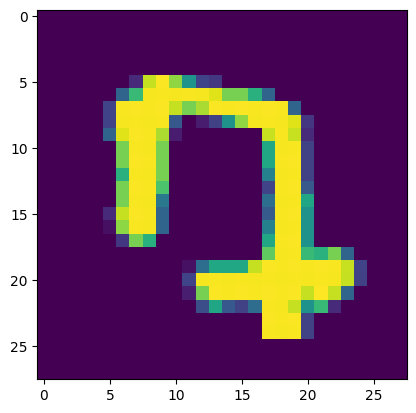


Label: [4] | Predicted: 9



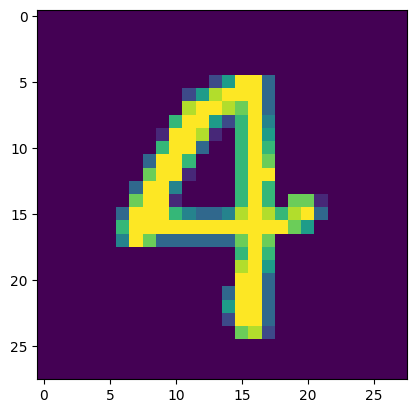


Label: [4] | Predicted: 9



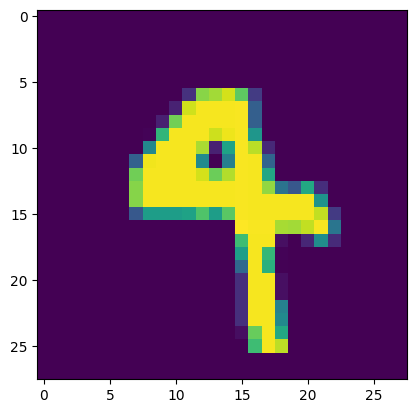


Label: [5] | Predicted: 3



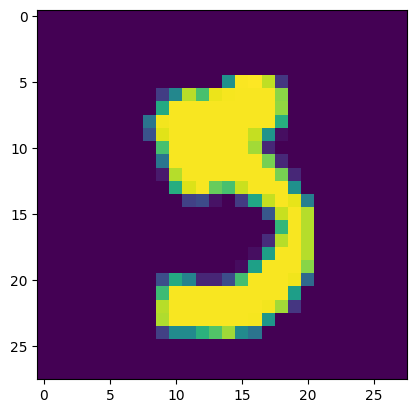


Label: [3] | Predicted: 8



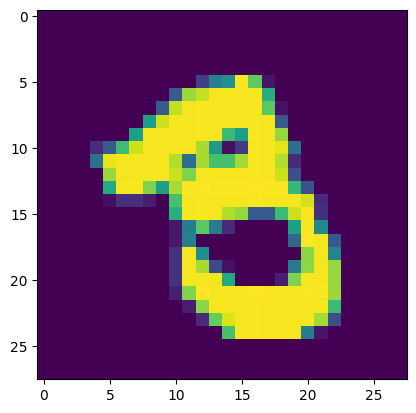


Label: [5] | Predicted: 3



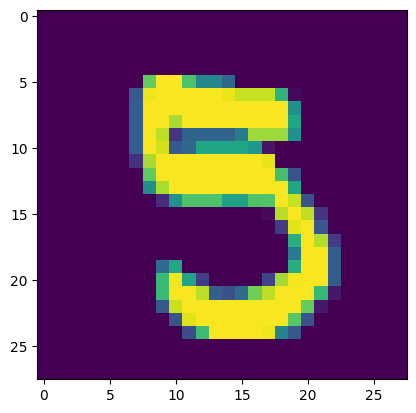


Label: [3] | Predicted: 8



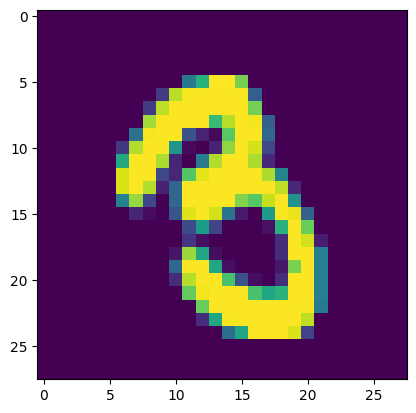


Label: [5] | Predicted: 3



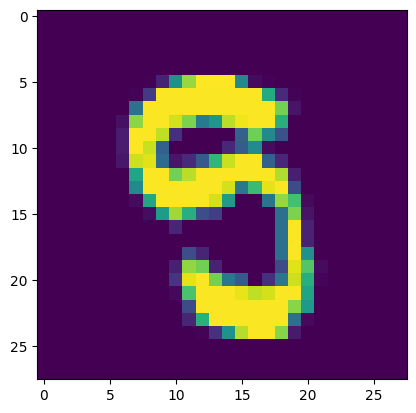


Label: [3] | Predicted: 8



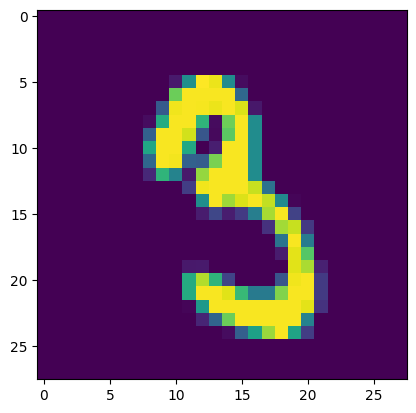


Label: [5] | Predicted: 3



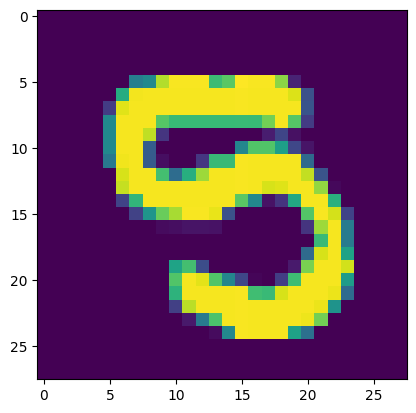


Label: [3] | Predicted: 5



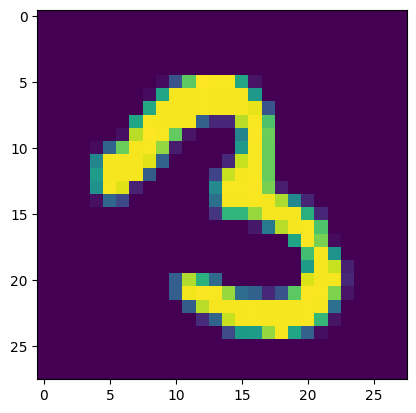


Label: [3] | Predicted: 8



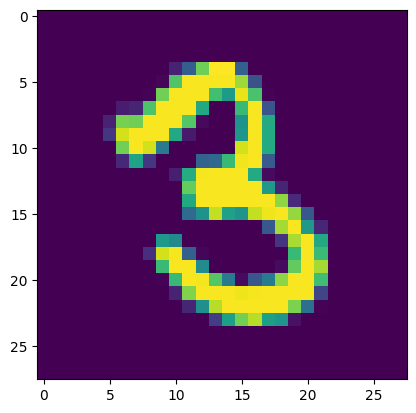


Label: [3] | Predicted: 8



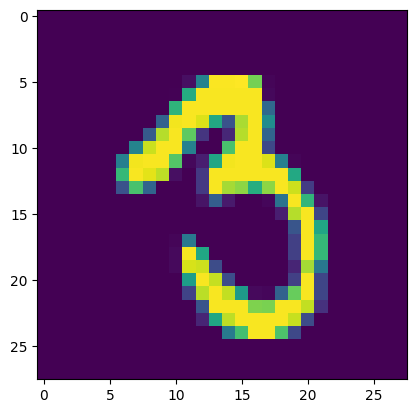


Label: [9] | Predicted: 3



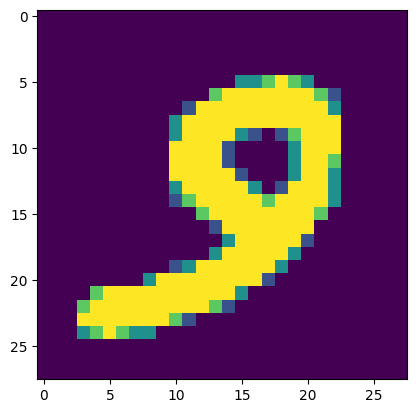


Label: [9] | Predicted: 8



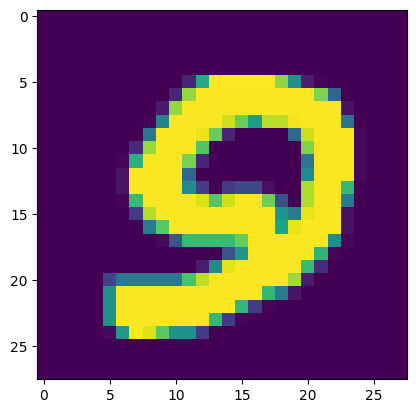


Label: [5] | Predicted: 3



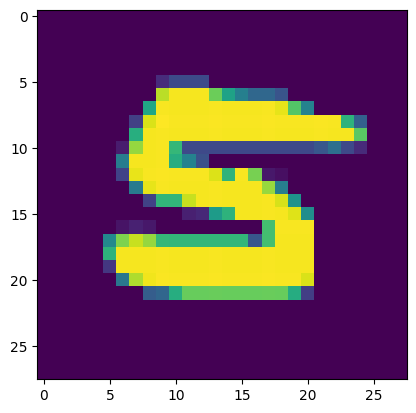


Label: [0] | Predicted: 6



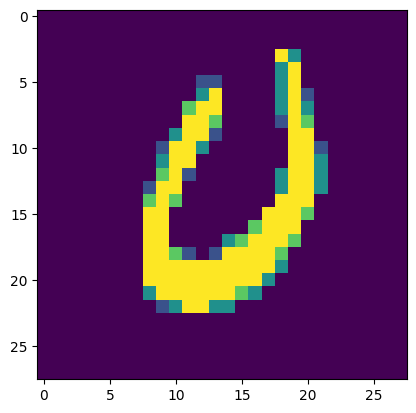


Label: [8] | Predicted: 9



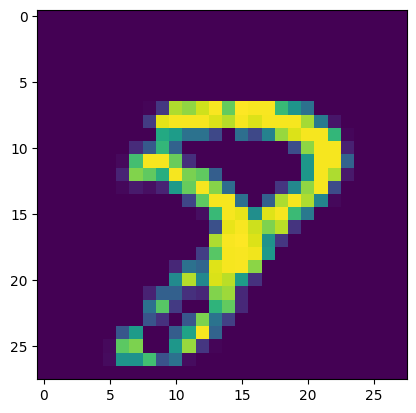


Label: [9] | Predicted: 3



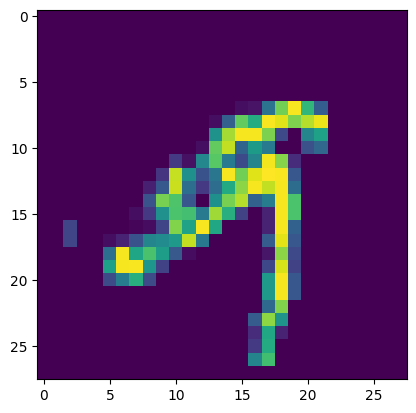


Label: [2] | Predicted: 6



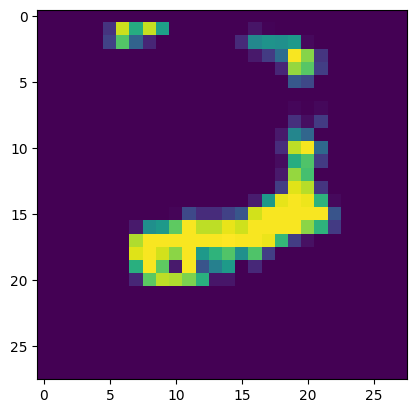


Label: [7] | Predicted: 2



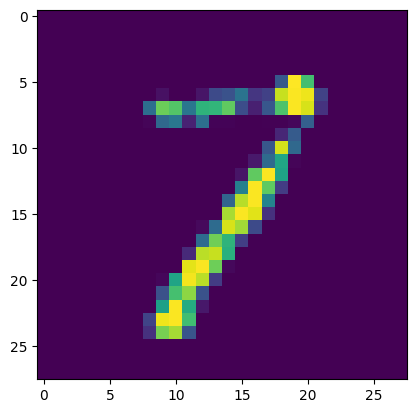


Label: [0] | Predicted: 7



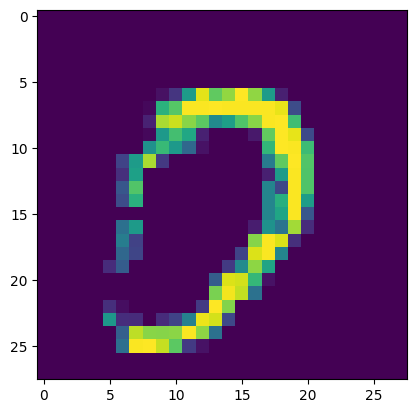


Label: [9] | Predicted: 5



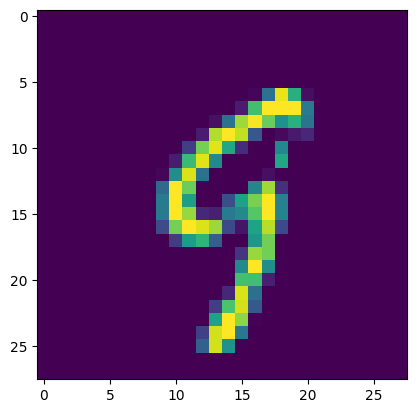


Label: [8] | Predicted: 1



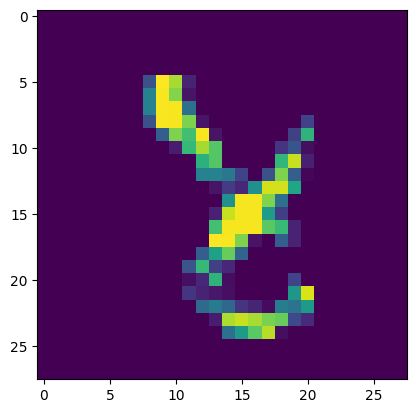


Label: [9] | Predicted: 5



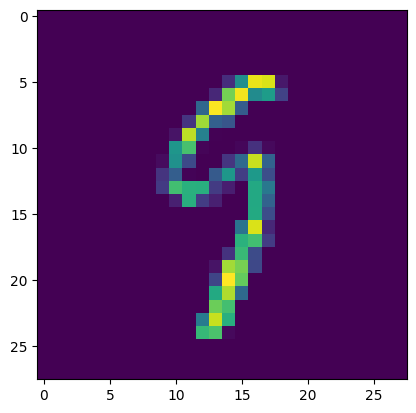


Label: [8] | Predicted: 5



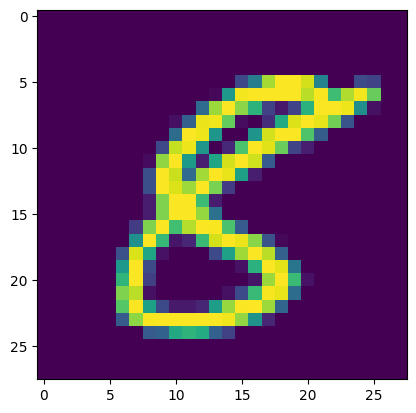


Label: [0] | Predicted: 8



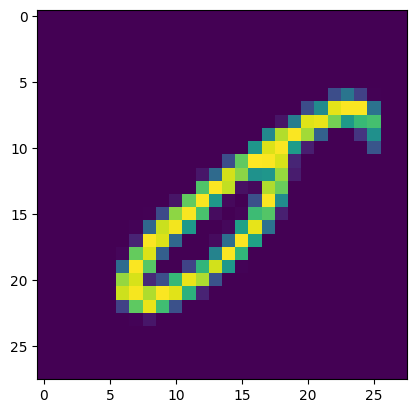


Label: [5] | Predicted: 3



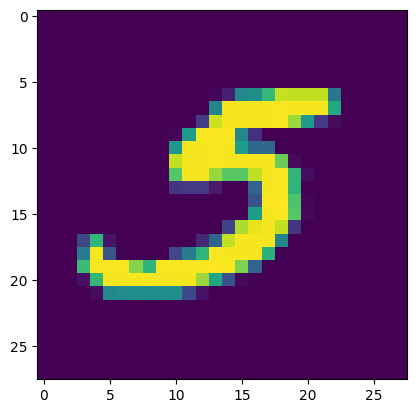


Label: [8] | Predicted: 3



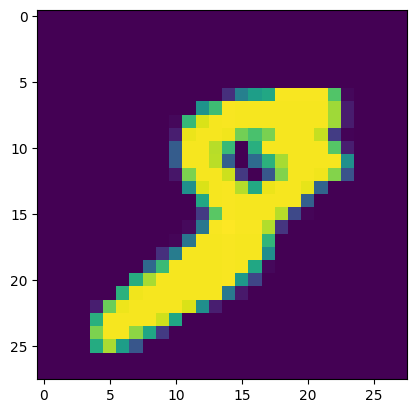


Label: [1] | Predicted: 6



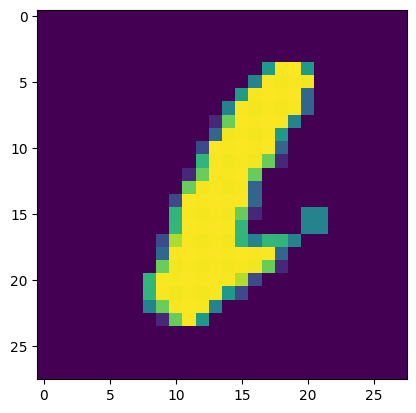


Label: [6] | Predicted: 4



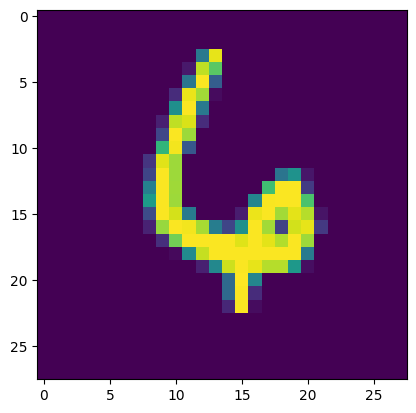


Label: [6] | Predicted: 4



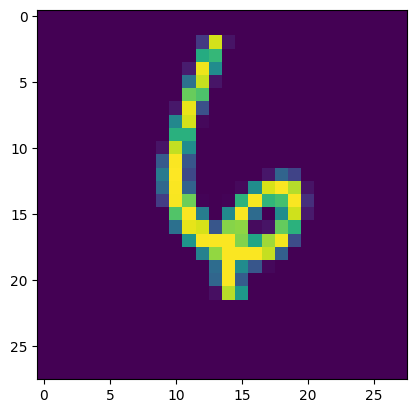


Label: [0] | Predicted: 5



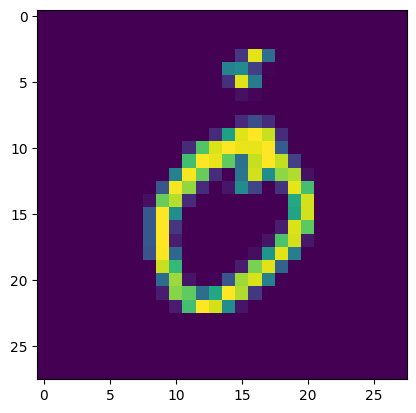


Label: [3] | Predicted: 2



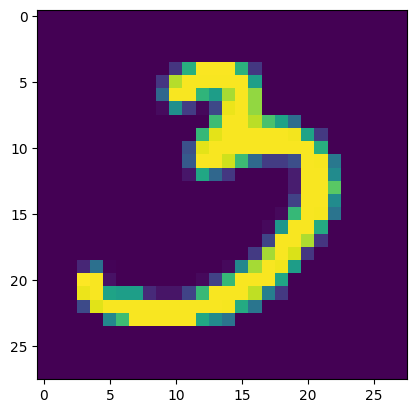


Label: [7] | Predicted: 3



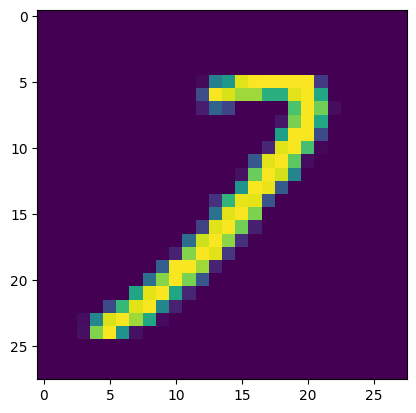


Label: [4] | Predicted: 8



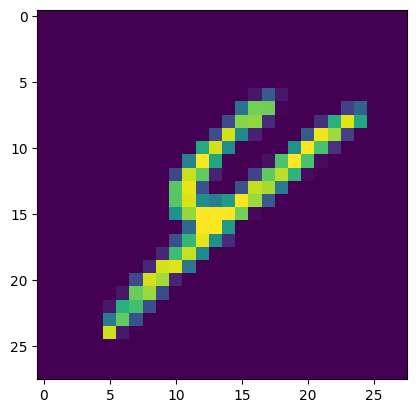


Label: [5] | Predicted: 6



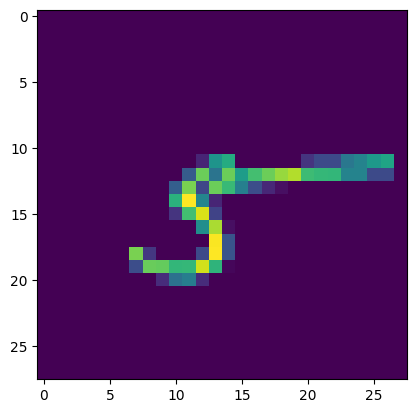


Label: [9] | Predicted: 5



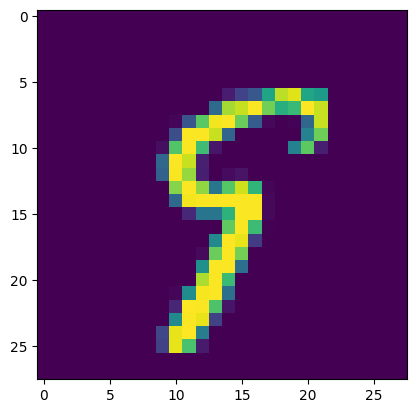


Label: [5] | Predicted: 3



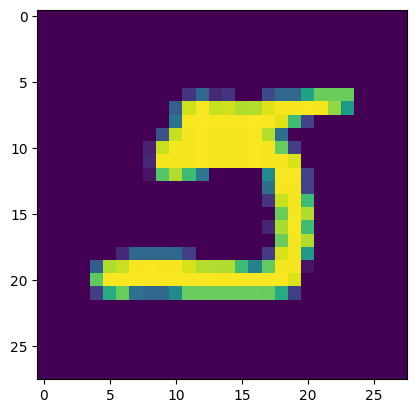


Label: [1] | Predicted: 8



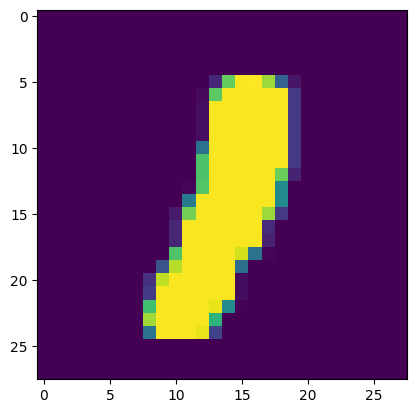


Label: [1] | Predicted: 8



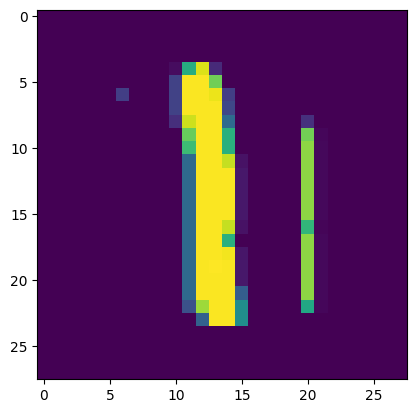


Label: [2] | Predicted: 8



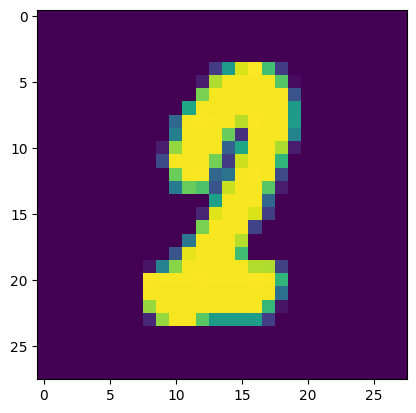


Label: [8] | Predicted: 5



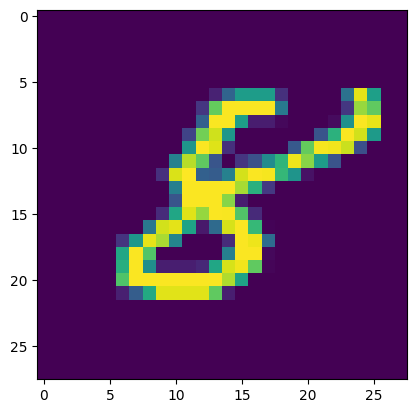


Label: [3] | Predicted: 9



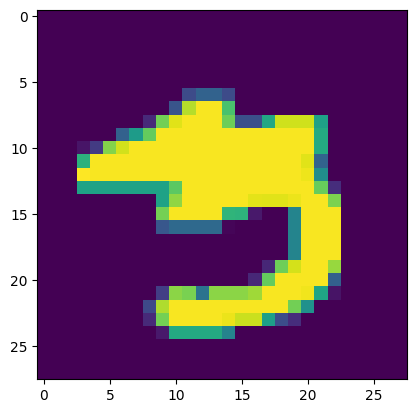


Label: [4] | Predicted: 9



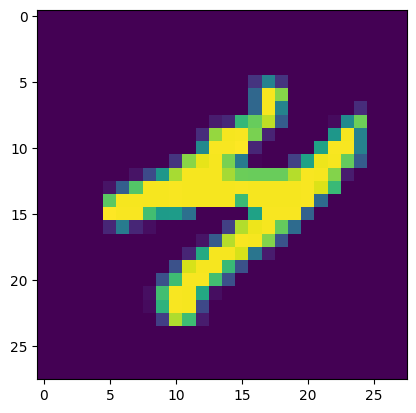


Label: [3] | Predicted: 9



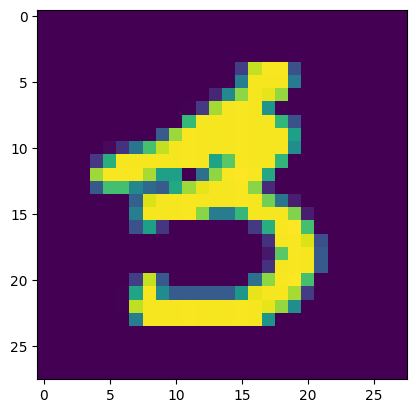


Label: [3] | Predicted: 5



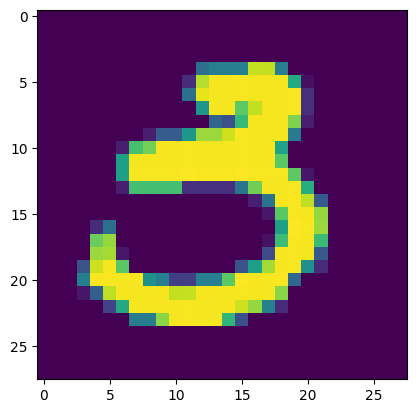


Label: [8] | Predicted: 5



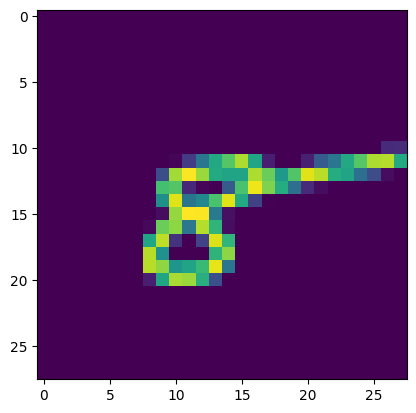


Label: [8] | Predicted: 0



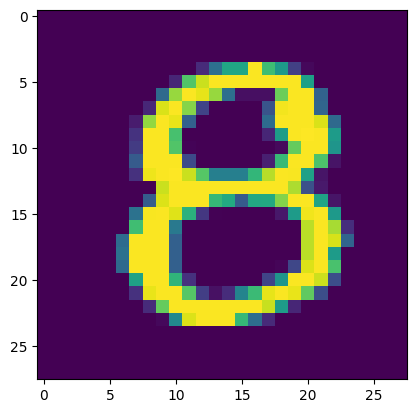


Label: [5] | Predicted: 3



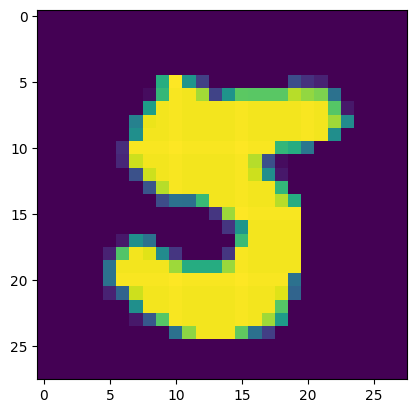


Label: [8] | Predicted: 6



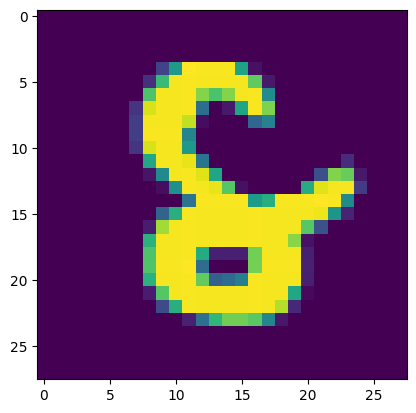


Label: [7] | Predicted: 2



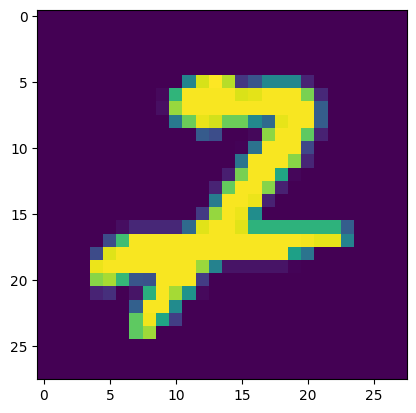


Label: [7] | Predicted: 2



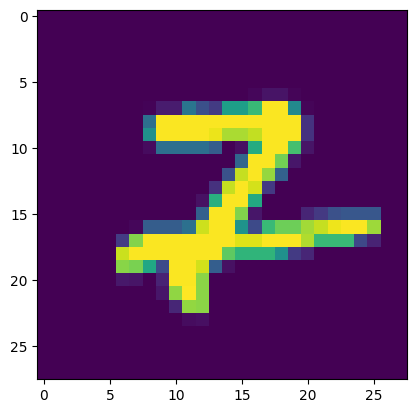


Label: [7] | Predicted: 2



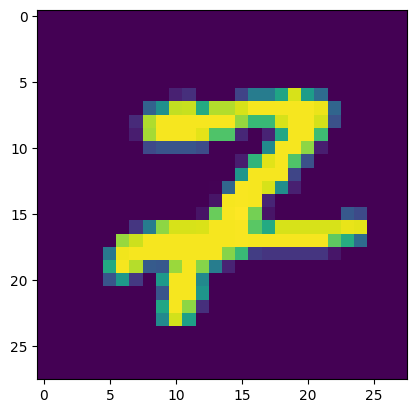


Label: [7] | Predicted: 2



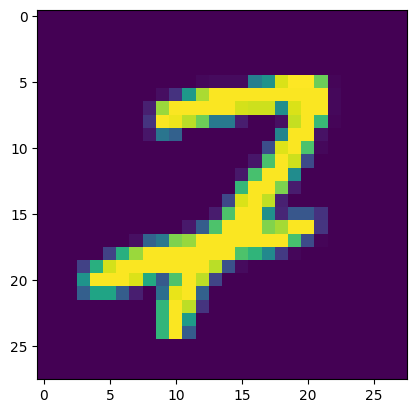


Label: [8] | Predicted: 5



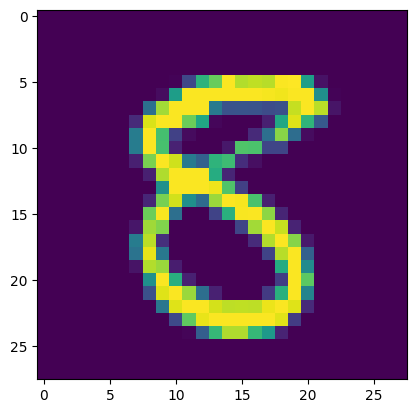


Label: [5] | Predicted: 3



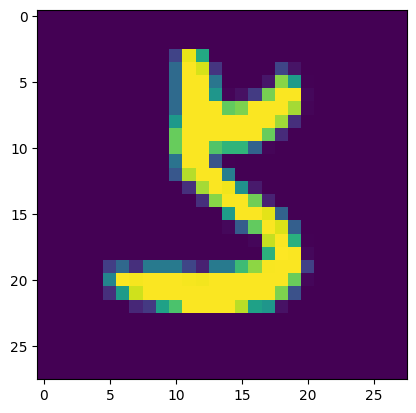


Label: [5] | Predicted: 3



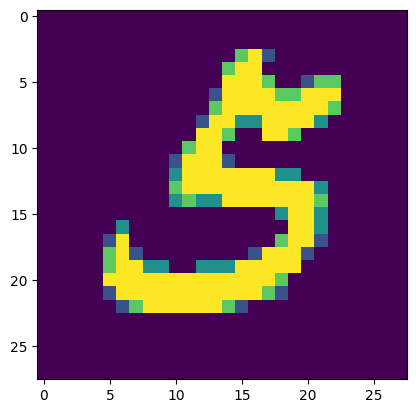


Label: [5] | Predicted: 3



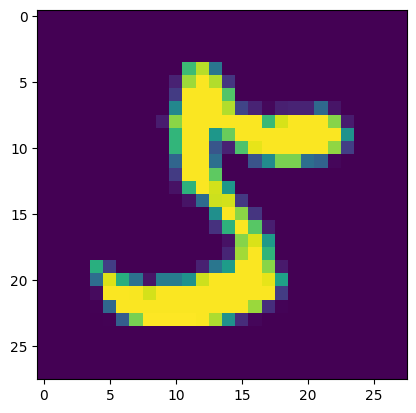


Label: [9] | Predicted: 4



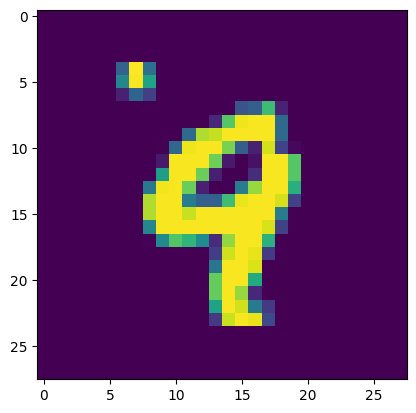


Label: [0] | Predicted: 1



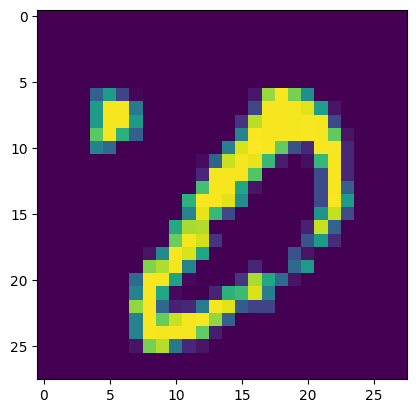


Label: [3] | Predicted: 2



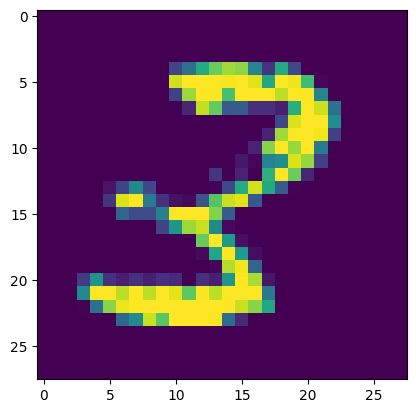


Label: [2] | Predicted: 7



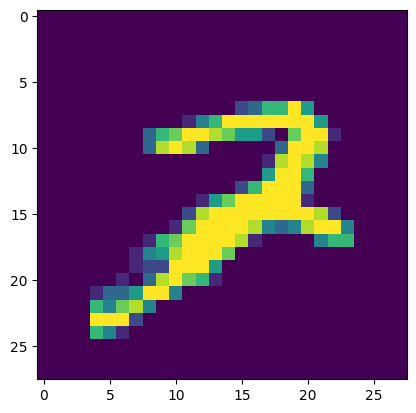


Label: [6] | Predicted: 3



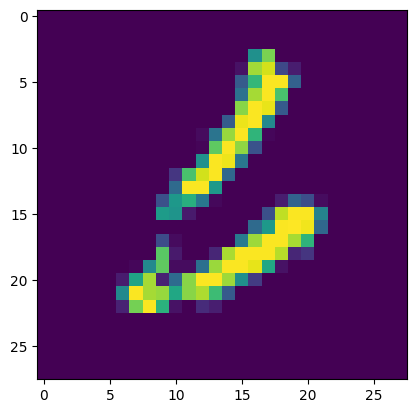


Label: [9] | Predicted: 7



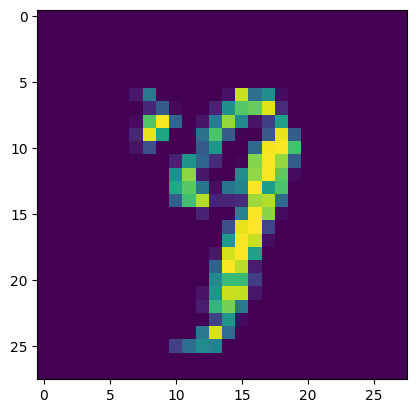


Label: [5] | Predicted: 6



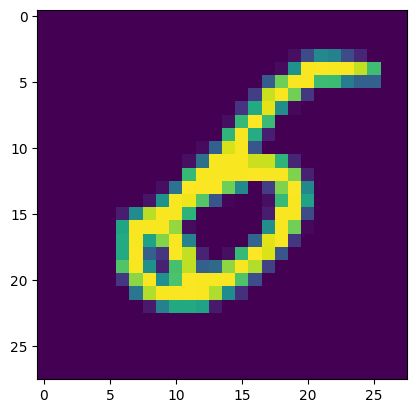


Label: [4] | Predicted: 7



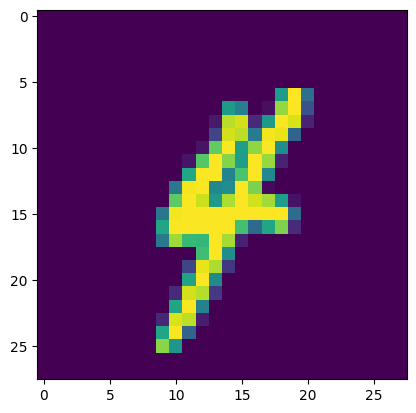


Label: [4] | Predicted: 0



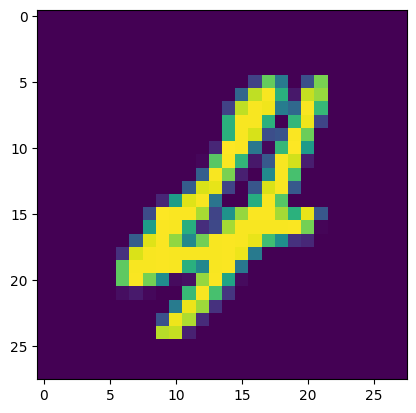


Label: [8] | Predicted: 5



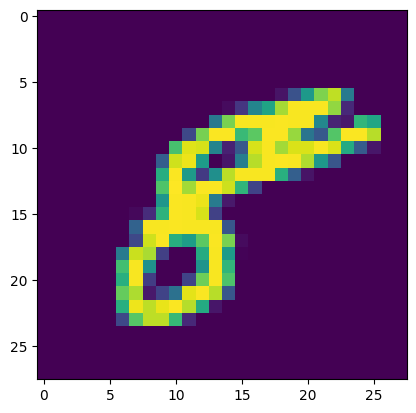


Label: [2] | Predicted: 0



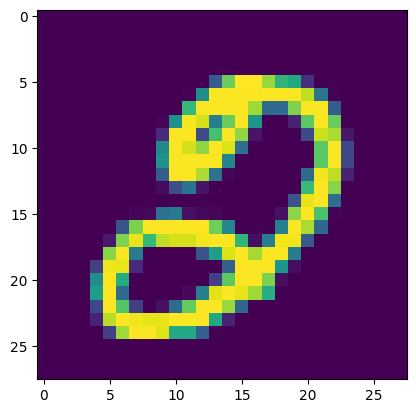


Label: [5] | Predicted: 0



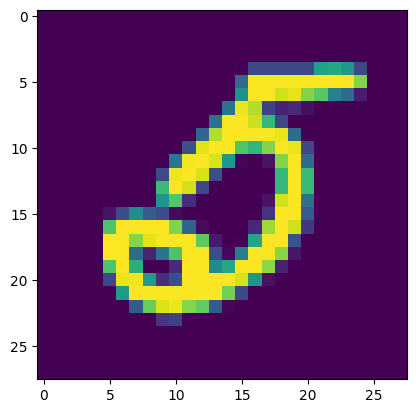


Label: [5] | Predicted: 0



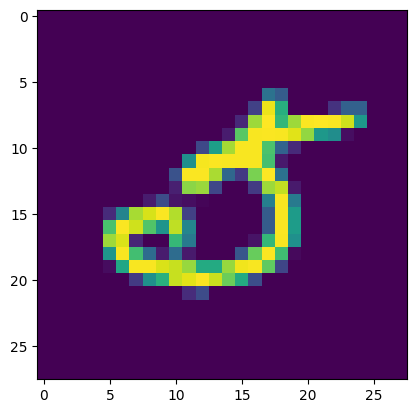


Label: [2] | Predicted: 0



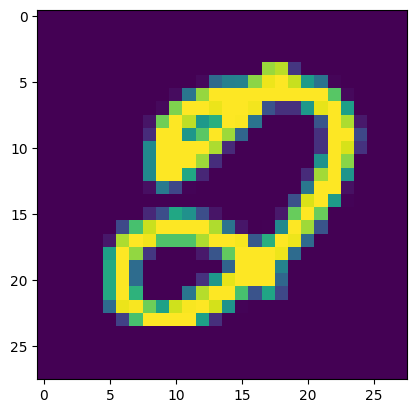


Label: [4] | Predicted: 7



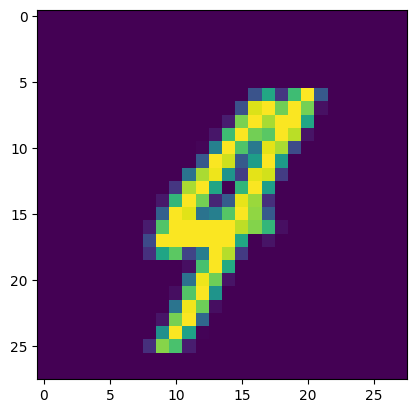


Label: [2] | Predicted: 3



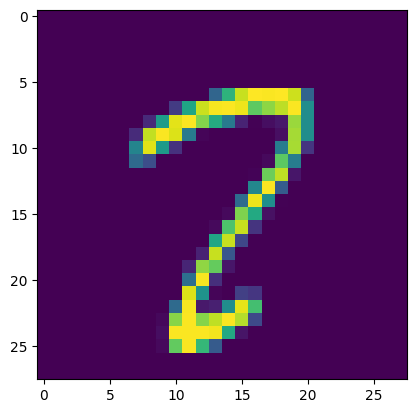


Label: [6] | Predicted: 8



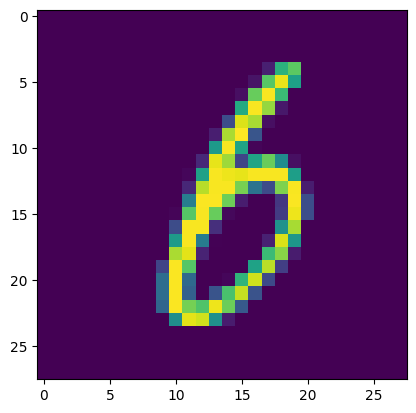


Label: [8] | Predicted: 9



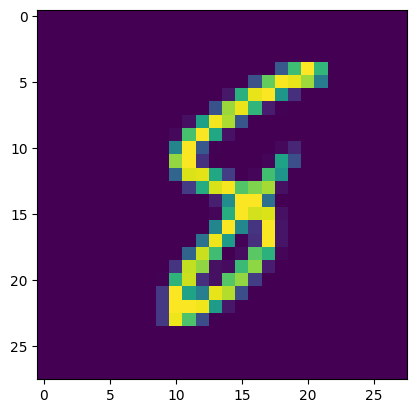


Label: [2] | Predicted: 0



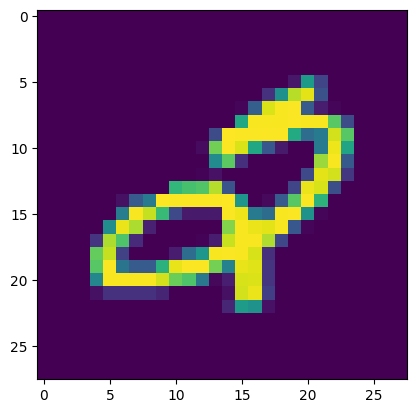


Label: [3] | Predicted: 8



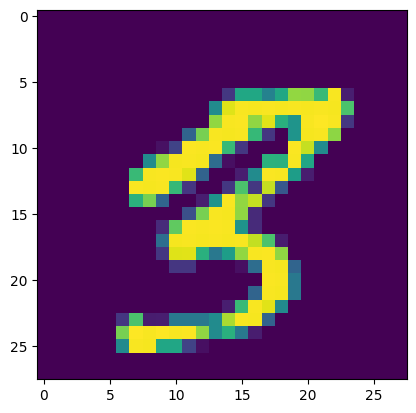


Label: [5] | Predicted: 6



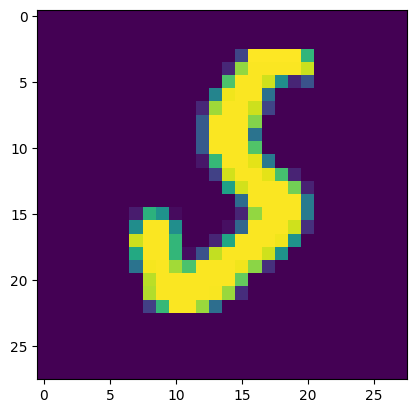

(array([    5,    17,    86,    91,   212,   239,   318,   320,   322,
          329,   340,   368,   371,   391,   414,   417,   426,   429,
          446,   467,   514,   522,   560,   564,   572,   574,   698,
          714,   747,   753,   802,   819,   821,   841,   881,   916,
          947,   994,  1180,  1230,  1248,  1274,  1280,  1300,  1394,
         1544,  1600,  1614,  1698,  1740,  1764,  1794,  1886,  1944,
         1986,  2022,  2048,  2086,  2129,  2138,  2140,  2144,  2163,
         2168,  2210,  2236,  2241,  2246,  2280,  2294,  2324,  2394,
         2661,  2674,  2697,  2729,  2771,  2800,  2851,  2854,  2869,
         2879,  2899,  2914,  2932,  2953,  2968,  2975,  2981,  3017,
         3019,  3036,  3063,  3156,  3184,  3216,  3312,  3470,  3476,
         3507,  3547,  3570,  3638,  3641,  3680,  3784,  3806,  3844,
         3852,  3873,  3906,  3910,  3976,  3999,  4011,  4024,  4028,
         4036,  4074,  4097,  4178,  4191,  4194,  4195,  4264,  4296,
      

In [750]:
show_incorrect(X_test, y_test, NN)